# FX Option-Surface Regression Diagnostics

This notebook studies whether 1M FX option-surface signals help explain next-month FX carry returns. It is a regression and diagnostic notebook only. It does not construct, optimize, or backtest any trading strategy.

The redesign treats ATM volatility, depreciation skew, and butterfly as three equal option-surface signals throughout the analysis. The primary model is M5, the joint carry-conditioner model.

In [1]:
from pathlib import Path
import json
import math
import shutil
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
    PLOTTING_AVAILABLE = True
except Exception as exc:
    PLOTTING_AVAILABLE = False
    plt = None
    mcolors = None
    LinearSegmentedColormap = None
    TwoSlopeNorm = None
    warnings.warn(f"Plotting libraries unavailable: {repr(exc)}")

try:
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except Exception as exc:
    sm = None
    STATSMODELS_AVAILABLE = False
    warnings.warn(f"statsmodels unavailable; regression sections will be skipped where needed: {repr(exc)}")

try:
    from scipy import stats as scipy_stats
    SCIPY_AVAILABLE = True
except Exception:
    scipy_stats = None
    SCIPY_AVAILABLE = False

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)

NOTEBOOK_PATH = Path("theo/06_options_filter_regression(9).ipynb")
SOURCE_NOTEBOOK_USED = "theo/06_options_filter_regression(7).ipynb"
BACKUP_NOTEBOOK_PATH = Path("theo/06_options_filter_regression.pre_redesign_backup.ipynb")
PRIMARY_EXCLUDED_CURRENCIES = {"CNH"}
MONTHS_PER_YEAR = 12
MIN_Z_N_ALL = 5
MIN_Z_N_CLASS = 3
MIN_CELL_OBS = 15
MIN_CELL_MONTHS = 8
EXPANDING_MIN_MONTHS = 60
CARRY_CONSTRUCTION = "log_normalized_spot_over_normalized_1m_forward"
WILD_CLUSTER_BOOTSTRAP_STATUS = "wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed"

successful_sections = []
skipped_sections = []
figure_paths = []
figure_audit_rows = []
heatmap_validation_rows = []
correlation_validation_rows = []
zscore_diagnostics_rows = []
validation_messages = []
inference_diagnostic_rows = []
ci_consistency_rows = []
wild_cluster_bootstrap_rows = []
result_integrity = {}


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "data").exists() and (candidate / "theo" / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/ and theo/data/processed/.")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "theo" / "data" / "processed"
FIG_DIR = PROCESSED_DIR / "option_filter_regression_figures_v9"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
if FIG_DIR.exists():
    shutil.rmtree(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

INPUTS = {
    "g10_carry": PROCESSED_DIR / "g10_1m_carry_panel.parquet",
    "em_carry": PROCESSED_DIR / "em_1m_carry_panel.parquet",
    "full_panel_source": PROCESSED_DIR / "fx_option_signal_panel.parquet",
    "overwritten_primary_legacy_panel": PROCESSED_DIR / "option_filter_regression_panel.parquet",
    "g10_options_raw": RAW_DIR / "g10_fx_options_long.parquet",
    "em_options_raw": RAW_DIR / "em_fx_options_long.parquet",
}

OUTPUTS = {
    "primary_panel": PROCESSED_DIR / "option_filter_regression_panel_primary_v9.parquet",
    "full_panel_snapshot": PROCESSED_DIR / "option_filter_regression_panel_full_v9.parquet",
    "carry_reconstruction_audit": PROCESSED_DIR / "option_filter_carry_reconstruction_audit_v9.parquet",
    "inference_diagnostics": PROCESSED_DIR / "option_filter_inference_diagnostics_v9.parquet",
    "coverage": PROCESSED_DIR / "option_filter_regression_coverage_v9.parquet",
    "descriptive": PROCESSED_DIR / "option_filter_regression_descriptive_v9.parquet",
    "correlations": PROCESSED_DIR / "option_filter_correlation_matrices_v9.parquet",
    "conditional_cells": PROCESSED_DIR / "option_filter_conditional_return_cells_v9.parquet",
    "regression": PROCESSED_DIR / "option_filter_regression_results_v9.parquet",
    "fixed_effects": PROCESSED_DIR / "option_filter_fixed_effect_results_v9.parquet",
    "heterogeneity": PROCESSED_DIR / "option_filter_heterogeneity_results_v9.parquet",
    "marginal": PROCESSED_DIR / "option_filter_marginal_effects_v9.parquet",
    "risk_outcomes": PROCESSED_DIR / "option_filter_risk_outcome_results_v9.parquet",
    "spec_bridge": PROCESSED_DIR / "option_filter_specification_bridge_v9.parquet",
    "robustness": PROCESSED_DIR / "option_filter_robustness_results_v9.parquet",
    "oos": PROCESSED_DIR / "option_filter_oos_predictions_v9.parquet",
    "integrity_audit": PROCESSED_DIR / "option_filter_integrity_audit_v9.json",
    "summary": PROCESSED_DIR / "option_filter_regression_summary_v9.json",
}
assert INPUTS["full_panel_source"].resolve() not in {path.resolve() for path in OUTPUTS.values()}
for _name, _input_path in INPUTS.items():
    if _input_path.resolve() in {path.resolve() for path in OUTPUTS.values()}:
        raise AssertionError(f"Input path collides with an output path: {_name} -> {_input_path}")

if PLOTTING_AVAILABLE:
    RETURN_CMAP = LinearSegmentedColormap.from_list(
        "red_white_green",
        ["#b2182b", "#ffffff", "#1a9850"],
        N=256,
    )
    COUNT_CMAP = "Greys"
else:
    RETURN_CMAP = None
    COUNT_CMAP = None

ECONOMIC_LABELS = {
    "carry_signal_1m": "1M carry signal, log(S/F)",
    "spot_return_1m": "1M spot return, log(S_next/S)",
    "realized_return_1m": "1M realized return, log(S_next/F)",
    "atm_vol_1m": "1M ATM implied volatility (%)",
    "depreciation_skew_25d_1m": "1M 25D depreciation skew, foreign put IV minus foreign call IV",
    "bf25_1m": "1M 25D butterfly / smile curvature",
    "return_bps": "Next-month realized return (bps)",
    "abs_realized_return_1m": "Absolute next-month realized return",
    "squared_realized_return_1m": "Squared next-month realized return",
    "negative_return_probability": "Indicator for negative next-month return",
    "severe_loss_full_sample": "Indicator for severe lower-tail loss using one full-sample threshold",
    "severe_loss_within_asset_class": "Indicator for severe lower-tail loss using asset-class thresholds",
}

SIGNAL_COLUMNS = ["carry_signal_1m", "atm_vol_1m", "depreciation_skew_25d_1m", "bf25_1m"]
OPTION_SIGNAL_COLUMNS = ["atm_vol_1m", "depreciation_skew_25d_1m", "bf25_1m"]
Y_COL = "realized_return_1m"

MODEL_SHORT = {"carry": "C", "atm_vol": "V", "depreciation_skew": "D", "bf25": "B"}
TERM_DISPLAY = {
    "const": "Intercept",
    "carry": "Carry signal (C)",
    "atm_vol": "ATM volatility (V)",
    "depreciation_skew": "Depreciation skew (D)",
    "bf25": "Butterfly (B)",
    "carry_x_atm_vol": "Carry x ATM volatility (C x V)",
    "carry_x_depreciation_skew": "Carry x depreciation skew (C x D)",
    "carry_x_bf25": "Carry x butterfly (C x B)",
    "atm_vol_x_depreciation_skew": "ATM volatility x depreciation skew (V x D)",
    "atm_vol_x_bf25": "ATM volatility x butterfly (V x B)",
    "depreciation_skew_x_bf25": "Depreciation skew x butterfly (D x B)",
    "carry_x_atm_vol_x_depreciation_skew": "Carry x ATM volatility x depreciation skew (C x V x D)",
}


def note_skip(section, reason, **extra):
    row = {"section": section, "reason": str(reason)}
    row.update(extra)
    skipped_sections.append(row)
    print(f"Skipped {section}: {reason}")


def display_df(df, fmt=None, max_rows=80):
    if df is None or len(df) == 0:
        display(pd.DataFrame())
        return
    out = df.head(max_rows)
    if fmt:
        display(out.style.format(fmt, na_rep="—"))
    else:
        display(out)


def finalize_axis(ax, title, xlabel, ylabel, sample_definition=None, units=None, note=None, zero_axis="y"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel if units is None else f"{ylabel}\nUnits: {units}")
    if zero_axis == "y":
        ax.axhline(0, color="#333333", lw=0.8, alpha=0.7)
    elif zero_axis == "x":
        ax.axvline(0, color="#333333", lw=0.8, alpha=0.7)
    ax.grid(alpha=0.25)
    notes = []
    if sample_definition:
        notes.append(f"Sample: {sample_definition}")
    if note:
        notes.append(note)
    if notes:
        ax.text(0.0, -0.24, " | ".join(notes), transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#444444")
    return ax


def audit_figure(fig, name):
    rows = []
    for i, ax in enumerate(fig.axes):
        label = str(ax.get_label())
        is_colorbar = label.startswith("<colorbar") or ("heatmap" in name and i >= 1 and len(fig.axes) > 1 and not ax.get_title())
        rows.append({
            "figure": name,
            "axis_index": i,
            "title_present": bool(str(ax.get_title()).strip()) or is_colorbar,
            "xlabel_present": bool(str(ax.get_xlabel()).strip()) or is_colorbar,
            "ylabel_present": bool(str(ax.get_ylabel()).strip()) or is_colorbar,
            "documented_exception": "colorbar axis" if is_colorbar else "",
        })
    figure_audit_rows.extend(rows)
    return rows


def savefig(fig, name):
    path = FIG_DIR / name
    audit_figure(fig, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    figure_paths.append(path)
    return path


def significance_stars(p):
    if pd.isna(p) or not np.isfinite(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def expected_significance_stars(p):
    if pd.isna(p) or not np.isfinite(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def format_p_value(p):
    if pd.isna(p) or not np.isfinite(p):
        return "—"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def format_significance(s):
    return "" if pd.isna(s) else str(s)


def format_two_way_status(status):
    if pd.isna(status) or not str(status).strip():
        return ""
    status = str(status)
    if status == "available":
        return "available"
    return "Unavailable: " + status


def add_inference_star_columns(df):
    if df is None or len(df) == 0:
        return df
    out = df.copy()
    if "stars" in out.columns:
        out = out.drop(columns=["stars"])
    p_star_pairs = {
        "iid_p": "iid_stars",
        "hc3_p": "hc3_stars",
        "month_cluster_p": "month_cluster_stars",
        "currency_cluster_p": "currency_cluster_stars",
        "two_way_cluster_p": "two_way_cluster_stars",
        "bridge_p": "bridge_stars",
        "iid_p_value": "iid_stars",
        "clustered_p_value": "clustered_stars",
    }
    for p_col, star_col in p_star_pairs.items():
        if p_col in out.columns:
            out[star_col] = out[p_col].apply(significance_stars)
    if "two_way_cluster_status" in out.columns and "two_way_cluster_stars" in out.columns:
        unavailable = ~out["two_way_cluster_status"].eq("available")
        out.loc[unavailable, "two_way_cluster_stars"] = ""
    if "clustered_status" in out.columns and "clustered_stars" in out.columns:
        unavailable = ~out["clustered_status"].eq("available")
        out.loc[unavailable, "clustered_stars"] = ""
    return out


SIGNIFICANCE_LEGEND = (
    "Significance notation:\n"
    "*** p < 0.01, ** p < 0.05, * p < 0.10.\n\n"
    "IID and two-way clustered significance indicators refer to different "
    "covariance assumptions and are reported separately."
)


def display_significance_legend():
    display(Markdown(SIGNIFICANCE_LEGEND))


def inference_text(row):
    coef = row.get("coefficient", np.nan)
    sign = "positive" if coef > 0 else "negative"
    iid_p = row.get("iid_p", np.nan)
    iid_stars = significance_stars(iid_p)
    tw_p = row.get("two_way_cluster_p", np.nan)
    tw_stars = significance_stars(tw_p)
    tw_status = row.get("two_way_cluster_status", "")
    iid_piece = f"IID p={format_p_value(iid_p)} ({iid_stars if iid_stars else 'no stars'})"
    if np.isfinite(tw_p):
        tw_piece = f"two-way p={format_p_value(tw_p)} ({tw_stars if tw_stars else 'no stars'})"
        if bool(iid_stars) != bool(tw_stars):
            caveat = " Evidence is sensitive to dependence adjustment."
        else:
            caveat = ""
    else:
        tw_piece = f"two-way clustered inference unavailable ({tw_status})"
        caveat = " IID significance should therefore be treated only as a benchmark." if iid_stars else ""
    return f"{sign} coefficient ({coef:+.5f}); {iid_piece}; {tw_piece}.{caveat}"


def display_regression_table(df, fmt=None, max_rows=80):
    if df is None or len(df) == 0:
        display(pd.DataFrame())
        return
    out = df.copy()
    if "two_way_cluster_status" in out.columns:
        out["two_way_cluster_status"] = out["two_way_cluster_status"].apply(format_two_way_status)
    rename = {
        "sample": "Sample",
        "variable_label": "Variable",
        "coefficient": "Coefficient",
        "iid_p": "IID p",
        "iid_stars": "IID sig.",
        "hc3_p": "HC3 p",
        "hc3_stars": "HC3 sig.",
        "month_cluster_p": "Month-cluster p",
        "month_cluster_stars": "Month-cluster sig.",
        "currency_cluster_p": "Currency-cluster p",
        "currency_cluster_stars": "Currency-cluster sig.",
        "two_way_cluster_se": "Two-way SE",
        "two_way_cluster_t": "Two-way t",
        "two_way_cluster_p": "Two-way p",
        "two_way_cluster_stars": "Two-way sig.",
        "two_way_cluster_status": "Two-way status",
        "two_way_ci_low": "Two-way CI low",
        "two_way_ci_high": "Two-way CI high",
        "observations": "Observations",
        "currencies": "Currencies",
        "months": "Months",
        "adj_r_squared": "Adjusted R²",
    }
    out = out.rename(columns={k:v for k,v in rename.items() if k in out.columns})
    fmt_use = fmt or {}
    fmt_named = {}
    for k, v in fmt_use.items():
        fmt_named[rename.get(k, k)] = v
    for p_col in [c for c in out.columns if c.endswith(" p") or c in {"IID p", "HC3 p", "Two-way p", "Month-cluster p", "Currency-cluster p"}]:
        fmt_named[p_col] = format_p_value
    display_df(out, fmt_named, max_rows=max_rows)


def finite_or_nan(x):
    try:
        x = float(x)
        return x if np.isfinite(x) else np.nan
    except Exception:
        return np.nan


def indicator_preserve_missing(values: pd.Series, condition) -> pd.Series:
    result = pd.Series(np.nan, index=values.index, dtype=float)
    valid = values.notna()
    result.loc[valid] = condition(values.loc[valid]).astype(float)
    return result


def cluster_warning(n_currency_clusters):
    if n_currency_clusters < 15:
        return "strong warning: fewer than 15 currency clusters; cluster-robust asymptotics are likely unreliable"
    if n_currency_clusters < 30:
        return "warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable"
    return ""


def validate_covariance_result(result, names):
    try:
        cov = np.asarray(result.cov_params(), dtype=float)
        diag = np.diag(cov) if cov.ndim == 2 and cov.shape[0] == cov.shape[1] else np.array([np.nan])
        if cov.ndim != 2 or cov.shape[0] != cov.shape[1]:
            return False, "invalid covariance shape"
        if not np.all(np.isfinite(cov)) or not np.all(np.isfinite(diag)):
            return False, "invalid covariance diagonal"
        if not np.all(diag >= -1e-14):
            return False, "invalid covariance diagonal"
        bse = np.asarray(result.bse, dtype=float)
        if len(bse) != len(names) or not np.all(np.isfinite(bse)):
            return False, "non-finite standard error"
        return True, "available"
    except Exception as exc:
        return False, f"model fitting failed: {repr(exc)}"


def result_ci(result, names, name, valid=True):
    if not valid:
        return np.nan, np.nan, "unavailable", np.nan, np.nan
    idx = names.index(name)
    df_inf = finite_or_nan(getattr(result, "df_resid_inference", getattr(result, "df_resid", np.nan)))
    try:
        ci = np.asarray(result.conf_int(alpha=0.05), dtype=float)
        low, high = ci[idx, 0], ci[idx, 1]
        if np.isfinite(low) and np.isfinite(high):
            return float(low), float(high), "robust_result.conf_int", df_inf, np.nan
    except Exception:
        pass
    se = finite_or_nan(np.asarray(result.bse)[idx])
    if not np.isfinite(se):
        return np.nan, np.nan, "unavailable", df_inf, np.nan
    if SCIPY_AVAILABLE and np.isfinite(df_inf) and df_inf > 0:
        crit = float(scipy_stats.t.ppf(0.975, df=df_inf))
        method = "finite-sample t confidence interval"
    else:
        crit = 1.959963984540054
        method = "normal-approximation confidence interval"
    coef = finite_or_nan(np.asarray(result.params)[idx])
    return coef - crit * se, coef + crit * se, method, df_inf, crit


def safe_zscore(s, min_n):
    s = pd.to_numeric(s, errors="coerce")
    n = int(s.notna().sum())
    if n < min_n:
        return pd.Series(np.nan, index=s.index), {"n": n, "reason": "below minimum group size"}
    std = s.std(ddof=1)
    if not np.isfinite(std) or std <= 0:
        return pd.Series(np.nan, index=s.index), {"n": n, "reason": "zero or unavailable standard deviation"}
    return (s - s.mean()) / std, {"n": n, "reason": "ok"}


def safe_mad_zscore(s, min_n):
    s = pd.to_numeric(s, errors="coerce")
    n = int(s.notna().sum())
    if n < min_n:
        return pd.Series(np.nan, index=s.index), {"n": n, "reason": "below minimum group size"}
    med = s.median()
    mad = (s - med).abs().median()
    denom = 1.4826 * mad
    if not np.isfinite(denom) or denom <= 0:
        return pd.Series(np.nan, index=s.index), {"n": n, "reason": "zero or unavailable MAD"}
    return (s - med) / denom, {"n": n, "reason": "ok"}


def safe_rank(s, min_n):
    s = pd.to_numeric(s, errors="coerce")
    n = int(s.notna().sum())
    if n < min_n:
        return pd.Series(np.nan, index=s.index)
    return s.rank(method="average", pct=True) - 0.5


def safe_quintile(s, min_n):
    s = pd.to_numeric(s, errors="coerce")
    if int(s.notna().sum()) < min_n or s.nunique(dropna=True) < 5:
        return pd.Series(np.nan, index=s.index)
    try:
        return pd.qcut(s.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(float)
    except Exception:
        return pd.Series(np.nan, index=s.index)


def symmetric_limit(values, fallback=0.001):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return fallback
    lim = float(np.nanmax(np.abs(vals)))
    return max(lim, fallback)


def get_sample(df, sample):
    if sample == "All":
        return df.copy()
    return df[df["asset_class"].eq(sample)].copy()

print(f"Project root: {ROOT}")
print(f"Source notebook used: {SOURCE_NOTEBOOK_USED}")
print(f"Backup notebook: {BACKUP_NOTEBOOK_PATH}")
print(f"Figure directory: {FIG_DIR.relative_to(ROOT)}")

Project root: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo
Source notebook used: theo/06_options_filter_regression(7).ipynb
Backup notebook: theo/06_options_filter_regression.pre_redesign_backup.ipynb
Figure directory: theo/data/processed/option_filter_regression_figures_v9


## Variable Definitions and Economic Conventions

All economic returns are measured from the perspective of the foreign currency. Spot and forward rates are expressed as USD per unit of foreign currency after direction normalization.

### Carry signal

Canonical column:

```python
carry_signal_1m
```

$$
carry\_signal_{i,t}^{1M}
=
\log\left(\frac{S_{i,t}}{F_{i,t}^{1M}}\right).
$$

This is known at time $t$ and is used as a predictor or ranking signal. It is not a realized return.

### Spot return

Canonical column:

```python
spot_return_1m
```

$$
spot\_return_{i,t+1}^{1M}
=
\log\left(\frac{S_{i,t+1}}{S_{i,t}}\right).
$$

A positive value means the foreign currency appreciated against USD.

### Realized return

Canonical column:

```python
realized_return_1m
```

$$
realized\_return_{i,t+1}^{1M}
=
\log\left(\frac{S_{i,t+1}}{F_{i,t}^{1M}}\right).
$$

The notebook enforces the identity:

$$
\boxed{
realized\_return_{1m}
=
carry\_signal_{1m}
+
spot\_return_{1m}
}.
$$

This is the dependent variable in the regression notebook.

### Portfolio realized return terminology

Reserved canonical name:

```python
portfolio_realized_return_1m
```

$$
portfolio\_realized\_return_{t+1}^{1M}
=
\sum_i w_{i,t}\,realized\_return_{i,t+1}^{1M}.
$$

This notebook does not construct or backtest this portfolio. The term is defined only for consistency with later notebooks.

### Option-surface signals

The three option-surface signals are treated symmetrically:

```python
atm_vol_1m
depreciation_skew_25d_1m
bf25_1m
```

Depreciation skew is defined as:

$$
DepreciationSkew_{25D,1M}
=
IV(\text{foreign-currency put})
-
IV(\text{foreign-currency call}).
$$

A positive value means foreign-currency depreciation protection is relatively more expensive. A negative value means foreign-currency appreciation protection is relatively more expensive. A zero value means the two 25D wings have the same implied volatility.

Depreciation skew measures the relative option-implied pricing of foreign-currency depreciation protection. It can reflect risk-neutral tail pricing, risk premia, hedging demand, and option-market supply and demand.

In [2]:

print("Loading carry panels and recovered full option-signal source...")
missing = [name for name, path in INPUTS.items() if name in {"g10_carry", "em_carry", "full_panel_source"} and not path.exists()]
if missing:
    raise FileNotFoundError(f"Required input files are missing: {missing}")

g10_carry = pd.read_parquet(INPUTS["g10_carry"]).copy()
em_carry = pd.read_parquet(INPUTS["em_carry"]).copy()
option_source = pd.read_parquet(INPUTS["full_panel_source"]).copy()

# Narrow compatibility boundary for legacy column names from previous notebooks.
LEGACY_COMPATIBILITY_ALLOWLIST = {
    "dependent_return": "realized_1m_forward_excess_return",
    "legacy_skew_25d": "bad_skew25_1m",
    "legacy_skew_10d": "bad_skew10_1m",
}

def canonicalize_carry_panel(df, asset_class):
    out = df.copy()
    out["month_end"] = pd.to_datetime(out["month_end"]).dt.to_period("M").dt.to_timestamp("M")
    out["currency"] = out["currency"].astype(str)
    out["asset_class"] = asset_class
    out["source_carry_signal_1m"] = out["carry_signal_1m"] if "carry_signal_1m" in out.columns else np.nan
    if LEGACY_COMPATIBILITY_ALLOWLIST["dependent_return"] in out.columns:
        out["legacy_realized_return_1m"] = out[LEGACY_COMPATIBILITY_ALLOWLIST["dependent_return"]]
    elif "realized_return_1m" in out.columns:
        out["legacy_realized_return_1m"] = out["realized_return_1m"]
    else:
        out["legacy_realized_return_1m"] = np.nan

    for col in ["spot_usd_per_ccy", "forward_1m_usd_per_ccy", "next_month_spot_usd_per_ccy"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    valid_carry = out["spot_usd_per_ccy"].notna() & out["forward_1m_usd_per_ccy"].notna() & (out["spot_usd_per_ccy"] > 0) & (out["forward_1m_usd_per_ccy"] > 0)
    valid_realized = valid_carry & out["next_month_spot_usd_per_ccy"].notna() & (out["next_month_spot_usd_per_ccy"] > 0)

    out["carry_signal_1m"] = np.nan
    out.loc[valid_carry, "carry_signal_1m"] = np.log(out.loc[valid_carry, "spot_usd_per_ccy"] / out.loc[valid_carry, "forward_1m_usd_per_ccy"])
    out["spot_return_1m"] = np.nan
    out.loc[valid_realized, "spot_return_1m"] = np.log(out.loc[valid_realized, "next_month_spot_usd_per_ccy"] / out.loc[valid_realized, "spot_usd_per_ccy"])
    out["realized_return_1m"] = np.nan
    out.loc[valid_realized, "realized_return_1m"] = np.log(out.loc[valid_realized, "next_month_spot_usd_per_ccy"] / out.loc[valid_realized, "forward_1m_usd_per_ccy"])
    out["legacy_realized_return_difference"] = out["legacy_realized_return_1m"] - out["realized_return_1m"]
    out["carry_source_minus_recomputed"] = out["source_carry_signal_1m"] - out["carry_signal_1m"]
    out["valid_carry_prices"] = valid_carry
    out["valid_realized_prices"] = valid_realized

    np.testing.assert_allclose(
        out.loc[valid_carry, "carry_signal_1m"],
        np.log(out.loc[valid_carry, "spot_usd_per_ccy"] / out.loc[valid_carry, "forward_1m_usd_per_ccy"]),
        rtol=1e-10, atol=1e-12,
    )
    np.testing.assert_allclose(
        out.loc[valid_realized, "realized_return_1m"],
        np.log(out.loc[valid_realized, "next_month_spot_usd_per_ccy"] / out.loc[valid_realized, "forward_1m_usd_per_ccy"]),
        rtol=1e-10, atol=1e-12,
    )
    np.testing.assert_allclose(
        out.loc[valid_realized, "realized_return_1m"],
        out.loc[valid_realized, "carry_signal_1m"] + out.loc[valid_realized, "spot_return_1m"],
        rtol=1e-10, atol=1e-12,
    )

    keep = [
        "month_end", "currency", "asset_class", "spot_usd_per_ccy", "forward_1m_usd_per_ccy",
        "next_month_spot_usd_per_ccy", "source_carry_signal_1m", "carry_signal_1m", "spot_return_1m",
        "realized_return_1m", "legacy_realized_return_1m", "legacy_realized_return_difference",
        "carry_source_minus_recomputed", "valid_carry_prices", "valid_realized_prices",
    ]
    return out[keep]

carry_returns = pd.concat([
    canonicalize_carry_panel(g10_carry, "G10"),
    canonicalize_carry_panel(em_carry, "EM"),
], ignore_index=True).sort_values(["month_end", "asset_class", "currency"], kind="mergesort")

option_source["month_end"] = pd.to_datetime(option_source["month_end"]).dt.to_period("M").dt.to_timestamp("M")
option_source["currency"] = option_source["currency"].astype(str)
option_source["asset_class"] = option_source["asset_class"].astype(str)

required_option_cols = ["month_end", "currency", "asset_class", "option_pair", "atm_vol_1m", "rr25_raw_1m", "bf25_1m", "rr10_raw_1m", "bf10_1m", "foreign_is_base", "option_data_quality_flag"]
missing_cols = [c for c in required_option_cols if c not in option_source.columns]
if missing_cols:
    raise KeyError(f"Full option source missing required columns: {missing_cols}")

option_core = option_source[required_option_cols].copy()
option_core["foreign_is_base"] = option_core["foreign_is_base"].astype(bool)
option_core["raw_rr_convention"] = "IV(base-currency call) - IV(base-currency put)"
option_core["depreciation_skew_formula"] = np.where(option_core["foreign_is_base"], "-rr25_raw_1m", "+rr25_raw_1m")
option_core["depreciation_skew_25d_1m"] = np.where(option_core["foreign_is_base"], -option_core["rr25_raw_1m"], option_core["rr25_raw_1m"])
option_core["depreciation_skew_10d_1m"] = np.where(option_core["foreign_is_base"], -option_core["rr10_raw_1m"], option_core["rr10_raw_1m"])
option_core["rr25_foreign_1m"] = -option_core["depreciation_skew_25d_1m"]
option_core["rr10_foreign_1m"] = -option_core["depreciation_skew_10d_1m"]

test_cases = pd.DataFrame([
    {"currency": "EUR", "option_pair": "EURUSD", "foreign_is_base": True, "rr25_raw_1m": -1.0, "expected_depreciation_skew": +1.0},
    {"currency": "JPY", "option_pair": "USDJPY", "foreign_is_base": False, "rr25_raw_1m": -1.2, "expected_depreciation_skew": -1.2},
    {"currency": "MXN", "option_pair": "USDMXN", "foreign_is_base": False, "rr25_raw_1m": +2.0, "expected_depreciation_skew": +2.0},
])
test_cases["computed_depreciation_skew"] = np.where(test_cases["foreign_is_base"], -test_cases["rr25_raw_1m"], test_cases["rr25_raw_1m"])
np.testing.assert_allclose(test_cases["computed_depreciation_skew"], test_cases["expected_depreciation_skew"])

direction_audit = (
    option_core.groupby(["asset_class", "currency", "option_pair", "foreign_is_base", "raw_rr_convention", "depreciation_skew_formula"], dropna=False)
    .agg(mean_raw_rr=("rr25_raw_1m", "mean"), mean_depreciation_skew=("depreciation_skew_25d_1m", "mean"), observations=("rr25_raw_1m", "count"))
    .reset_index()
    .sort_values(["asset_class", "currency"], kind="mergesort")
)

full_panel = carry_returns.merge(option_core, on=["month_end", "currency", "asset_class"], how="inner", validate="one_to_one")
full_panel = full_panel.sort_values(["month_end", "asset_class", "currency"], kind="mergesort").reset_index(drop=True)
if full_panel.duplicated(["month_end", "currency"]).any():
    duplicates = full_panel[full_panel.duplicated(["month_end", "currency"], keep=False)]
    raise ValueError(f"Duplicate month_end x currency rows detected: {duplicates[['month_end','currency']].head().to_dict('records')}")

valid_carry = full_panel["valid_carry_prices"]
valid_realized = full_panel["valid_realized_prices"]
np.testing.assert_allclose(full_panel.loc[valid_carry, "carry_signal_1m"], np.log(full_panel.loc[valid_carry, "spot_usd_per_ccy"] / full_panel.loc[valid_carry, "forward_1m_usd_per_ccy"]), rtol=1e-10, atol=1e-12)
np.testing.assert_allclose(full_panel.loc[valid_realized, "realized_return_1m"], np.log(full_panel.loc[valid_realized, "next_month_spot_usd_per_ccy"] / full_panel.loc[valid_realized, "forward_1m_usd_per_ccy"]), rtol=1e-10, atol=1e-12)
np.testing.assert_allclose(full_panel.loc[valid_realized, "realized_return_1m"], full_panel.loc[valid_realized, "carry_signal_1m"] + full_panel.loc[valid_realized, "spot_return_1m"], rtol=1e-10, atol=1e-12)

full_panel["return_bps"] = full_panel["realized_return_1m"] * 10000
full_panel["future_loss"] = indicator_preserve_missing(full_panel["realized_return_1m"], lambda x: x < 0)
full_panel["negative_return_probability"] = full_panel["future_loss"]
full_panel["abs_realized_return_1m"] = full_panel["realized_return_1m"].abs()
full_panel["squared_realized_return_1m"] = full_panel["realized_return_1m"] ** 2

carry_reconstruction_audit = (
    full_panel.assign(abs_diff=lambda x: x["carry_source_minus_recomputed"].abs())
    .groupby(["asset_class", "currency"], dropna=False)
    .agg(
        observations=("carry_source_minus_recomputed", "count"),
        mean_difference=("carry_source_minus_recomputed", "mean"),
        mean_absolute_difference=("abs_diff", "mean"),
        median_absolute_difference=("abs_diff", "median"),
        maximum_absolute_difference=("abs_diff", "max"),
        rows_diff_gt_1bp=("abs_diff", lambda s: int((s > 0.0001).sum())),
        rows_diff_gt_5bp=("abs_diff", lambda s: int((s > 0.0005).sum())),
    )
    .reset_index()
    .sort_values(["asset_class", "currency"], kind="mergesort")
)
carry_reconstruction_asset_audit = (
    full_panel.assign(abs_diff=lambda x: x["carry_source_minus_recomputed"].abs())
    .groupby(["asset_class"], dropna=False)
    .agg(
        observations=("carry_source_minus_recomputed", "count"),
        mean_difference=("carry_source_minus_recomputed", "mean"),
        mean_absolute_difference=("abs_diff", "mean"),
        median_absolute_difference=("abs_diff", "median"),
        maximum_absolute_difference=("abs_diff", "max"),
        rows_diff_gt_1bp=("abs_diff", lambda s: int((s > 0.0001).sum())),
        rows_diff_gt_5bp=("abs_diff", lambda s: int((s > 0.0005).sum())),
    )
    .reset_index()
)
price_integrity_audit = {
    "valid_carry_price_observations": int(valid_carry.sum()),
    "valid_realized_price_observations": int(valid_realized.sum()),
    "carry_identity_max_error": float((full_panel.loc[valid_carry, "carry_signal_1m"] - np.log(full_panel.loc[valid_carry, "spot_usd_per_ccy"] / full_panel.loc[valid_carry, "forward_1m_usd_per_ccy"])).abs().max()),
    "realized_return_identity_max_error": float((full_panel.loc[valid_realized, "realized_return_1m"] - (full_panel.loc[valid_realized, "carry_signal_1m"] + full_panel.loc[valid_realized, "spot_return_1m"])).abs().max()),
    "assertion_failures": 0,
    "carry_construction": CARRY_CONSTRUCTION,
}

if "CNH" not in set(full_panel["currency"]):
    note_skip("full-universe robustness", f"Recovered full source {INPUTS['full_panel_source']} does not contain CNH after merging with carry returns")
    genuine_full_universe_available = False
else:
    genuine_full_universe_available = True

primary_panel = full_panel[~full_panel["currency"].isin(PRIMARY_EXCLUDED_CURRENCIES)].copy()
primary_panel = primary_panel.sort_values(["month_end", "asset_class", "currency"], kind="mergesort").reset_index(drop=True)
assert "CNH" not in set(primary_panel["currency"])
if genuine_full_universe_available:
    assert "CNH" in set(full_panel["currency"])
    assert full_panel["currency"].nunique() > primary_panel["currency"].nunique()
    assert len(full_panel) > len(primary_panel)
if primary_panel.duplicated(["month_end", "currency"]).any():
    raise ValueError("Duplicate primary-panel month_end x currency rows detected.")

legacy_return_alignment_audit = (
    full_panel.assign(abs_legacy_difference=lambda x: x["legacy_realized_return_difference"].abs())
    .groupby("asset_class", as_index=False)
    .agg(
        observations=("legacy_realized_return_difference", "count"),
        max_abs_legacy_difference=("abs_legacy_difference", "max"),
        mean_abs_legacy_difference=("abs_legacy_difference", "mean"),
        rows_above_one_bp=("abs_legacy_difference", lambda s: int((s > 0.0001).sum())),
    )
)

universe_audit = pd.DataFrame([{
    "full_panel_source": str(INPUTS["full_panel_source"].relative_to(ROOT)),
    "full_observations": len(full_panel),
    "primary_observations": len(primary_panel),
    "full_currencies": full_panel["currency"].nunique(),
    "primary_currencies": primary_panel["currency"].nunique(),
    "cnh_in_full_panel": "CNH" in set(full_panel["currency"]),
    "cnh_absent_from_primary_panel": "CNH" not in set(primary_panel["currency"]),
    "input_output_paths_differ": INPUTS["full_panel_source"].resolve() not in {path.resolve() for path in OUTPUTS.values()},
}])

source_discrepancy_note = "The source carry column is retained only for audit. Differences are measured against log(normalized spot / normalized 1M forward). The notebook cannot fully identify the historical source formula from saved files alone; large differences are consistent with stale legacy calculations, alternative forward treatment, or convention/date-alignment differences and are not silently corrected in the source field."

successful_sections.append("price-based carry/return reconstruction, source-carry audit, direction tests, and return-identity validation")
print(f"Full panel: {full_panel.shape[0]:,} observations, {full_panel['currency'].nunique()} currencies, {full_panel['month_end'].nunique()} months")
print(f"Primary panel: {primary_panel.shape[0]:,} observations, {primary_panel['currency'].nunique()} currencies, {primary_panel['month_end'].nunique()} months")
display(Markdown("### Source Carry Discrepancy Note")); display(Markdown(source_discrepancy_note))
display(Markdown("### Data universe audit")); display(universe_audit)
display(Markdown("### Price construction audit")); display(pd.DataFrame([price_integrity_audit]))
display(Markdown("### Carry reconstruction audit by asset class")); display_df(carry_reconstruction_asset_audit, {"mean_difference":"{:+.6f}", "mean_absolute_difference":"{:.6f}", "median_absolute_difference":"{:.6f}", "maximum_absolute_difference":"{:.6f}"})
display(Markdown("### Carry reconstruction audit by currency")); display_df(carry_reconstruction_audit, {"mean_difference":"{:+.6f}", "mean_absolute_difference":"{:.6f}", "median_absolute_difference":"{:.6f}", "maximum_absolute_difference":"{:.6f}"})
display(Markdown("### Risk-reversal direction semantic tests")); display(test_cases)
display(Markdown("### Risk-reversal direction audit")); display_df(direction_audit, {"mean_raw_rr":"{:+.3f}", "mean_depreciation_skew":"{:+.3f}"})
display(Markdown("### Legacy realized-return alignment audit")); display_df(legacy_return_alignment_audit, {"max_abs_legacy_difference":"{:.6f}", "mean_abs_legacy_difference":"{:.6f}"})


Loading carry panels and recovered full option-signal source...
Full panel: 4,865 observations, 21 currencies, 234 months
Primary panel: 4,680 observations, 20 currencies, 234 months


### Source Carry Discrepancy Note

The source carry column is retained only for audit. Differences are measured against log(normalized spot / normalized 1M forward). The notebook cannot fully identify the historical source formula from saved files alone; large differences are consistent with stale legacy calculations, alternative forward treatment, or convention/date-alignment differences and are not silently corrected in the source field.

### Data universe audit

,full_panel_source,full_observations,primary_observations,full_currencies,primary_currencies,cnh_in_full_panel,cnh_absent_from_primary_panel,input_output_paths_differ
0,theo/data/processed/fx_option_signal_panel.par...,4865,4680,21,20,True,True,True


...

,currency,option_pair,foreign_is_base,rr25_raw_1m,expected_depreciation_skew,computed_depreciation_skew
0,EUR,EURUSD,True,-1.0,1.0,1.0
1,JPY,USDJPY,False,-1.2,-1.2,-1.2
2,MXN,USDMXN,False,2.0,2.0,2.0


### Risk-reversal direction audit

,asset_class,currency,option_pair,foreign_is_base,raw_rr_convention,depreciation_skew_formula,mean_raw_rr,mean_depreciation_skew,observations
0,EM,BRL,USDBRL,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+2.742,+2.742,234
1,EM,CNH,USDCNH,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+0.537,+0.537,185
2,EM,HUF,USDHUF,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+2.074,+2.074,234
3,EM,ILS,USDILS,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+0.898,+0.898,234
4,EM,INR,USDINR,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+1.069,+1.069,234
5,EM,KRW,USDKRW,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+1.573,+1.573,234
6,EM,MXN,USDMXN,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+2.397,+2.397,234
7,EM,PLN,USDPLN,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+1.722,+1.722,234
8,EM,SGD,USDSGD,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+0.471,+0.471,234
9,EM,THB,USDTHB,False,IV(base-currency call) - IV(base-currency put),+rr25_raw_1m,+0.629,+0.629,234


### Legacy realized-return alignment audit

,asset_class,observations,max_abs_legacy_difference,mean_abs_legacy_difference,rows_above_one_bp
0,EM,2745,0.000000,0.000000,0
1,G10,2097,0.013696,0.000474,1272


## Primary Universe and Cross-Sectional Transformations

The clean full panel is constructed first. The primary panel is then formed by applying the predeclared currency exclusion before any cross-sectional z-scores, ranks, quintiles, or heatmap cells are computed. This avoids calculating EM cross-sectional transforms on a broader universe and then removing a currency afterward.

The primary standardized specification uses monthly within-asset-class z-scores:

$$
z_{i,t}(X)
=
\frac{X_{i,t}-\bar X_{t,\mathrm{class}}}{s_{t,\mathrm{class}}(X)}.
$$

Uninformative groups are left missing rather than filled with zero.

In [3]:
def add_cross_sectional_transforms(df, panel_label):
    out = df.copy().sort_values(["month_end", "asset_class", "currency"], kind="mergesort")
    transform_specs = [
        ("all", ["month_end"], MIN_Z_N_ALL),
        ("class", ["month_end", "asset_class"], MIN_Z_N_CLASS),
    ]
    for suffix, group_cols, min_n in transform_specs:
        for base_col, short in [
            ("carry_signal_1m", "carry"),
            ("atm_vol_1m", "atm_vol"),
            ("depreciation_skew_25d_1m", "depreciation_skew"),
            ("bf25_1m", "bf25"),
        ]:
            z_col = f"z_{short}_{suffix}"
            rank_col = f"rank_{short}_{suffix}"
            q_col = f"q_{short}_{suffix}"
            mad_col = f"mad_z_{short}_{suffix}"
            out[z_col] = np.nan
            out[rank_col] = np.nan
            out[q_col] = np.nan
            out[mad_col] = np.nan
            for keys, sub in out.groupby(group_cols, sort=False, dropna=False):
                z, diag = safe_zscore(sub[base_col], min_n)
                rz, rdiag = safe_mad_zscore(sub[base_col], min_n)
                out.loc[sub.index, z_col] = z
                out.loc[sub.index, rank_col] = safe_rank(sub[base_col], min_n)
                out.loc[sub.index, q_col] = safe_quintile(sub[base_col], min_n)
                out.loc[sub.index, mad_col] = rz
                if diag["reason"] != "ok" or rdiag["reason"] != "ok":
                    zscore_diagnostics_rows.append({
                        "panel": panel_label, "method": "standard_and_mad", "suffix": suffix,
                        "group": str(keys), "column": base_col, "n": diag.get("n"),
                        "standard_reason": diag.get("reason"), "mad_reason": rdiag.get("reason"),
                    })

    # Predeclared winsorized within-class z-scores.
    for lo, hi, tag in [(0.01, 0.99, "w01_99"), (0.05, 0.95, "w05_95")]:
        for base_col, short in [
            ("carry_signal_1m", "carry"),
            ("atm_vol_1m", "atm_vol"),
            ("depreciation_skew_25d_1m", "depreciation_skew"),
            ("bf25_1m", "bf25"),
        ]:
            col = f"z_{short}_{tag}_class"
            out[col] = np.nan
            for keys, sub in out.groupby(["month_end", "asset_class"], sort=False, dropna=False):
                x = pd.to_numeric(sub[base_col], errors="coerce")
                if x.notna().sum() < MIN_Z_N_CLASS:
                    zscore_diagnostics_rows.append({"panel": panel_label, "method": tag, "suffix": "class", "group": str(keys), "column": base_col, "n": int(x.notna().sum()), "standard_reason": "below minimum group size"})
                    continue
                clipped = x.clip(x.quantile(lo), x.quantile(hi))
                z, diag = safe_zscore(clipped, MIN_Z_N_CLASS)
                out.loc[sub.index, col] = z
                if diag["reason"] != "ok":
                    zscore_diagnostics_rows.append({"panel": panel_label, "method": tag, "suffix": "class", "group": str(keys), "column": base_col, "n": diag.get("n"), "standard_reason": diag.get("reason")})

    # Ex-ante market-state ATM-vol variable: expanding z-score using only prior months.
    market_rows = []
    for asset_class, sub in out.groupby("asset_class", sort=True):
        monthly = sub.groupby("month_end", as_index=False)["atm_vol_1m"].median().sort_values("month_end")
        monthly["market_atm_vol_median_class"] = monthly["atm_vol_1m"]
        prior_mean = monthly["market_atm_vol_median_class"].expanding(min_periods=12).mean().shift(1)
        prior_std = monthly["market_atm_vol_median_class"].expanding(min_periods=12).std(ddof=1).shift(1)
        monthly["tsz_atm_vol_market_class"] = (monthly["market_atm_vol_median_class"] - prior_mean) / prior_std
        monthly["asset_class"] = asset_class
        market_rows.append(monthly[["month_end", "asset_class", "market_atm_vol_median_class", "tsz_atm_vol_market_class"]])
    market_state = pd.concat(market_rows, ignore_index=True) if market_rows else pd.DataFrame()
    out = out.merge(market_state, on=["month_end", "asset_class"], how="left", validate="many_to_one")
    return out

def prepare_analysis_panel(panel, *, label):
    transformed = add_cross_sectional_transforms(panel, label)
    transformed.attrs["transform_source_label"] = label
    transformed.attrs["source_observations"] = len(panel)
    transformed.attrs["source_currencies"] = panel["currency"].nunique()
    return transformed

primary_panel = prepare_analysis_panel(primary_panel, label="primary")
full_panel_transformed = prepare_analysis_panel(full_panel, label="full_universe")
primary_transformed = primary_panel
full_transformed = full_panel_transformed

for interaction_suffix in ["class", "all"]:
    for frame in [primary_panel, full_panel_transformed]:
        frame[f"z_carry_x_atm_vol_{interaction_suffix}"] = frame[f"z_carry_{interaction_suffix}"] * frame[f"z_atm_vol_{interaction_suffix}"]
        frame[f"z_carry_x_depreciation_skew_{interaction_suffix}"] = frame[f"z_carry_{interaction_suffix}"] * frame[f"z_depreciation_skew_{interaction_suffix}"]
        frame[f"z_carry_x_bf25_{interaction_suffix}"] = frame[f"z_carry_{interaction_suffix}"] * frame[f"z_bf25_{interaction_suffix}"]
        frame[f"z_atm_vol_x_depreciation_skew_{interaction_suffix}"] = frame[f"z_atm_vol_{interaction_suffix}"] * frame[f"z_depreciation_skew_{interaction_suffix}"]
        frame[f"z_atm_vol_x_bf25_{interaction_suffix}"] = frame[f"z_atm_vol_{interaction_suffix}"] * frame[f"z_bf25_{interaction_suffix}"]
        frame[f"z_depreciation_skew_x_bf25_{interaction_suffix}"] = frame[f"z_depreciation_skew_{interaction_suffix}"] * frame[f"z_bf25_{interaction_suffix}"]
        frame[f"z_carry_x_atm_vol_x_depreciation_skew_{interaction_suffix}"] = frame[f"z_carry_{interaction_suffix}"] * frame[f"z_atm_vol_{interaction_suffix}"] * frame[f"z_depreciation_skew_{interaction_suffix}"]

zscore_diagnostics = pd.DataFrame(zscore_diagnostics_rows)
if zscore_diagnostics.empty:
    zscore_summary = pd.DataFrame([{"status": "all cross-sectional transforms informative under minimum group-size rules"}])
else:
    zscore_summary = zscore_diagnostics.groupby(["panel", "suffix", "column", "standard_reason"], dropna=False).size().reset_index(name="group_count")

lost_transform_summary = []
for col in ["z_carry_class", "z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class", "rank_carry_class", "mad_z_carry_class"]:
    lost_transform_summary.append({"column": col, "missing_observations": int(primary_panel[col].isna().sum()), "available_observations": int(primary_panel[col].notna().sum())})
lost_transform_summary = pd.DataFrame(lost_transform_summary)

transform_independence_checks = {
    "primary_transform_source_label": primary_panel.attrs.get("transform_source_label"),
    "full_transform_source_label": full_panel_transformed.attrs.get("transform_source_label"),
    "primary_transforms_computed_from_primary_panel": primary_panel.attrs.get("source_observations") == len(primary_panel),
    "full_transforms_computed_from_full_panel": full_panel_transformed.attrs.get("source_observations") == len(full_panel),
}
if genuine_full_universe_available:
    merged_transform_check = primary_panel[primary_panel["asset_class"].eq("EM")][["month_end", "currency", "z_carry_class", "z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class"]].merge(
        full_panel_transformed[full_panel_transformed["asset_class"].eq("EM")][["month_end", "currency", "z_carry_class", "z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class"]],
        on=["month_end", "currency"], how="inner", suffixes=("_primary", "_full")
    )
    diff_cols = []
    for col in ["z_carry_class", "z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class"]:
        diff = (merged_transform_check[f"{col}_primary"] - merged_transform_check[f"{col}_full"]).abs()
        diff_cols.append(int((diff > 1e-12).sum()))
    transform_independence_checks["em_transform_differences_when_cnh_available"] = int(sum(diff_cols))
    assert transform_independence_checks["em_transform_differences_when_cnh_available"] > 0
else:
    transform_independence_checks["em_transform_differences_when_cnh_available"] = np.nan

transform_independence_table = pd.DataFrame([transform_independence_checks])

successful_sections.append("primary and full transforms independently recalculated with z-score/rank/MAD/winsorized diagnostics")
display(Markdown("### Cross-sectional transform diagnostics")); display_df(zscore_summary)
display(Markdown("### Missing transformed observations in the primary panel")); display_df(lost_transform_summary)
display(Markdown("### Independent transform checks")); display(transform_independence_table)

### Cross-sectional transform diagnostics

,status
0,all cross-sectional transforms informative und...


### Missing transformed observations in the primary panel

,column,missing_observations,available_observations
0,z_carry_class,1,4679
1,z_atm_vol_class,0,4680
2,z_depreciation_skew_class,0,4680
3,z_bf25_class,0,4680
4,rank_carry_class,1,4679
5,mad_z_carry_class,1,4679


### Independent transform checks

,primary_transform_source_label,full_transform_source_label,primary_transforms_computed_from_primary_panel,full_transforms_computed_from_full_panel,em_transform_differences_when_cnh_available
0,primary,full_universe,True,True,8118


## Coverage, Descriptive Statistics, and Direction Diagnostics

Coverage and descriptive summaries include carry, realized returns, ATM volatility, depreciation skew, and butterfly from the start. The observation unit is one currency-month.

In [4]:
def coverage_by_sample(df):
    rows=[]
    for sample in ["All", "G10", "EM"]:
        sub = get_sample(df, sample)
        for var in SIGNAL_COLUMNS + ["spot_return_1m", "realized_return_1m"]:
            rows.append({
                "sample": sample,
                "variable": var,
                "label": ECONOMIC_LABELS.get(var, var),
                "first_month": sub.loc[sub[var].notna(), "month_end"].min(),
                "last_month": sub.loc[sub[var].notna(), "month_end"].max(),
                "observations": int(sub[var].notna().sum()),
                "missing_observations": int(sub[var].isna().sum()),
                "currencies": int(sub.loc[sub[var].notna(), "currency"].nunique()),
                "months": int(sub.loc[sub[var].notna(), "month_end"].nunique()),
            })
    return pd.DataFrame(rows)

coverage_table = coverage_by_sample(primary_panel)

currency_coverage = []
for currency, sub in primary_panel.groupby("currency", sort=True):
    row = {"currency": currency, "asset_class": sub["asset_class"].iloc[0], "first_month": sub["month_end"].min(), "last_month": sub["month_end"].max(), "observations": len(sub)}
    for var in SIGNAL_COLUMNS + ["realized_return_1m"]:
        row[f"missing_{var}"] = int(sub[var].isna().sum())
    currency_coverage.append(row)
currency_coverage = pd.DataFrame(currency_coverage).sort_values(["asset_class", "currency"])

stats_cols = SIGNAL_COLUMNS + ["spot_return_1m", "realized_return_1m"]
desc_rows=[]
for sample in ["All", "G10", "EM"]:
    sub = get_sample(primary_panel, sample)
    for var in stats_cols:
        x = pd.to_numeric(sub[var], errors="coerce").dropna()
        desc_rows.append({
            "sample": sample,
            "variable": var,
            "label": ECONOMIC_LABELS.get(var, var),
            "observations": len(x),
            "mean": x.mean(),
            "median": x.median(),
            "std": x.std(ddof=1),
            "p05": x.quantile(0.05),
            "p95": x.quantile(0.95),
            "min": x.min(),
            "max": x.max(),
        })
descriptive_table = pd.DataFrame(desc_rows)

successful_sections.append("coverage, missingness, descriptive statistics, and direction audit tables")
display(Markdown("### Coverage by sample and variable")); display_df(coverage_table, {"observations":"{:,}", "missing_observations":"{:,}"})
display(Markdown("### Currency coverage")); display_df(currency_coverage)
display(Markdown("### Descriptive statistics")); display_df(descriptive_table, {"mean":"{:+.5f}", "median":"{:+.5f}", "std":"{:.5f}", "p05":"{:+.5f}", "p95":"{:+.5f}", "min":"{:+.5f}", "max":"{:+.5f}"})

### Coverage by sample and variable

,sample,variable,label,first_month,last_month,observations,missing_observations,currencies,months
0,All,carry_signal_1m,"1M carry signal, log(S/F)",2007-01-31 00:00:00,2026-06-30 00:00:00,"4,679",1,20,234
1,All,atm_vol_1m,1M ATM implied volatility (%),2007-01-31 00:00:00,2026-06-30 00:00:00,"4,680",0,20,234
2,All,depreciation_skew_25d_1m,"1M 25D depreciation skew, foreign put IV minus foreign call IV",2007-01-31 00:00:00,2026-06-30 00:00:00,"4,680",0,20,234
3,All,bf25_1m,1M 25D butterfly / smile curvature,2007-01-31 00:00:00,2026-06-30 00:00:00,"4,680",0,20,234
4,All,spot_return_1m,"1M spot return, log(S_next/S)",2007-01-31 00:00:00,2026-05-31 00:00:00,"4,658",22,20,233
5,All,realized_return_1m,"1M realized return, log(S_next/F)",2007-01-31 00:00:00,2026-05-31 00:00:00,"4,658",22,20,233
6,G10,carry_signal_1m,"1M carry signal, log(S/F)",2007-01-31 00:00:00,2026-06-30 00:00:00,"2,106",0,9,234
7,G10,atm_vol_1m,1M ATM implied volatility (%),2007-01-31 00:00:00,2026-06-30 00:00:00,"2,106",0,9,234
8,G10,depreciation_skew_25d_1m,"1M 25D depreciation skew, foreign put IV minus foreign call IV",2007-01-31 00:00:00,2026-06-30 00:00:00,"2,106",0,9,234
9,G10,bf25_1m,1M 25D butterfly / smile curvature,2007-01-31 00:00:00,2026-06-30 00:00:00,"2,106",0,9,234


### Currency coverage

,currency,asset_class,first_month,last_month,observations,missing_carry_signal_1m,missing_atm_vol_1m,missing_depreciation_skew_25d_1m,missing_bf25_1m,missing_realized_return_1m
1,BRL,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
6,HUF,EM,2007-01-31,2026-06-30,234,1,0,0,0,3
7,ILS,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
8,INR,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
10,KRW,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
11,MXN,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
14,PLN,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
16,SGD,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
17,THB,EM,2007-01-31,2026-06-30,234,0,0,0,0,1
18,TRY,EM,2007-01-31,2026-06-30,234,0,0,0,0,1


### Descriptive statistics

,sample,variable,label,observations,mean,median,std,p05,p95,min,max
0,All,carry_signal_1m,"1M carry signal, log(S/F)",4679,+0.00168,+0.00034,0.00479,-0.00228,+0.00813,-0.01061,+0.10623
1,All,atm_vol_1m,1M ATM implied volatility (%),4680,+10.52680,+9.56625,5.15340,+4.76225,+19.26288,+1.68500,+78.31750
2,All,depreciation_skew_25d_1m,"1M 25D depreciation skew, foreign put IV minus foreign call IV",4680,+1.28260,+0.94000,1.75163,-0.57512,+4.01763,-9.26500,+20.18500
3,All,bf25_1m,1M 25D butterfly / smile curvature,4680,+0.34209,+0.27000,0.27563,+0.12250,+0.78250,-0.01000,+3.27500
4,All,spot_return_1m,"1M spot return, log(S_next/S)",4658,-0.00188,-0.00031,0.03305,-0.05324,+0.04854,-0.33855,+0.15366
5,All,realized_return_1m,"1M realized return, log(S_next/F)",4658,-0.00020,+0.00104,0.03284,-0.05153,+0.05043,-0.32419,+0.14305
6,G10,carry_signal_1m,"1M carry signal, log(S/F)",2106,-0.00028,-0.00024,0.00157,-0.00294,+0.00235,-0.00543,+0.00550
7,G10,atm_vol_1m,1M ATM implied volatility (%),2106,+9.95325,+9.21250,3.76817,+5.55687,+16.47375,+3.78000,+40.95250
8,G10,depreciation_skew_25d_1m,"1M 25D depreciation skew, foreign put IV minus foreign call IV",2106,+0.55457,+0.56500,1.10988,-1.14000,+2.09813,-9.26500,+6.94500
9,G10,bf25_1m,1M 25D butterfly / smile curvature,2106,+0.23965,+0.21500,0.11926,+0.11250,+0.44938,+0.05250,+1.45000


## Correlation Heatmaps

The underlying Pearson and Spearman correlation matrices are saved as data tables. The notebook presentation uses heatmaps with a fixed $[-1,1]$ scale, white midpoint at zero, red negative correlations, and green positive correlations.

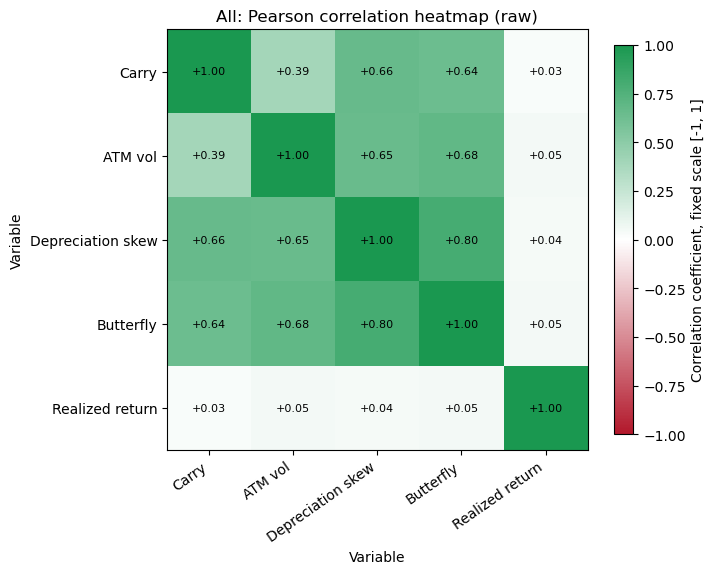

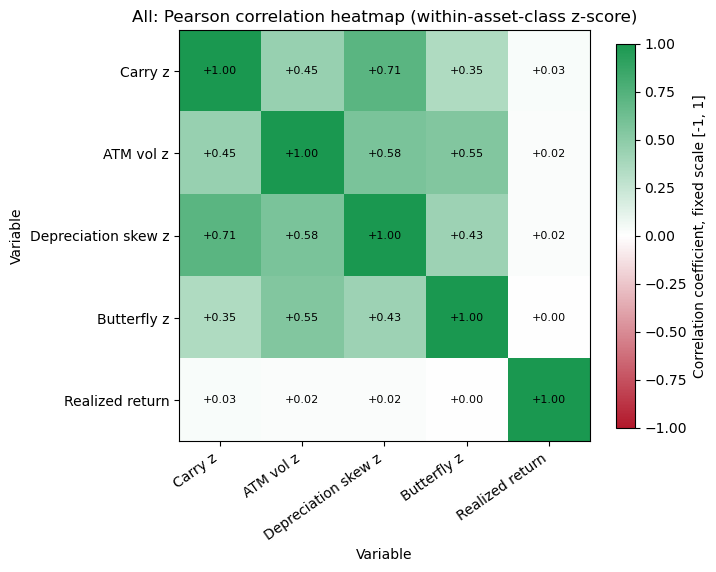

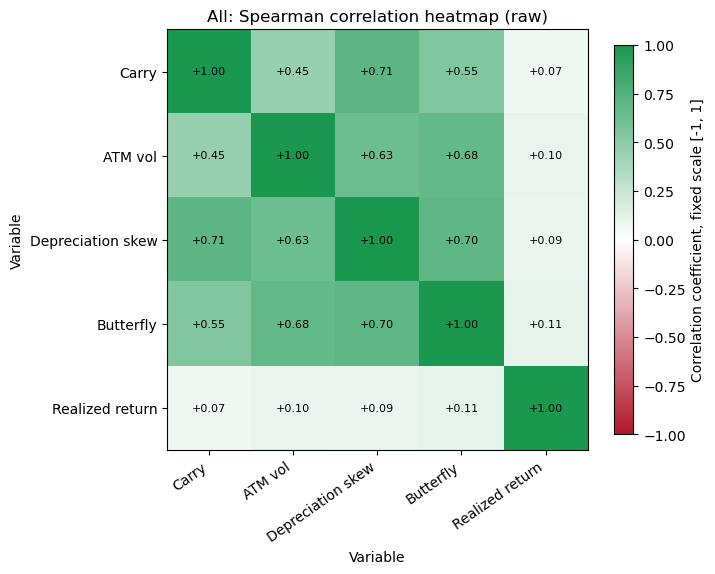

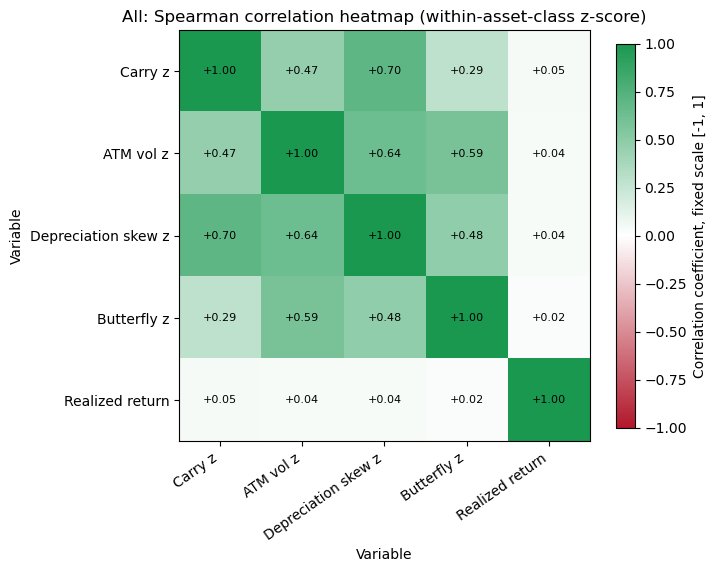

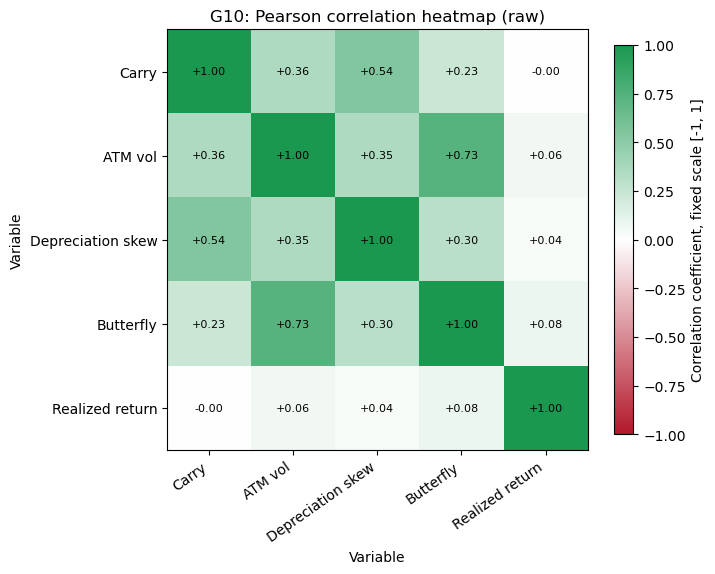

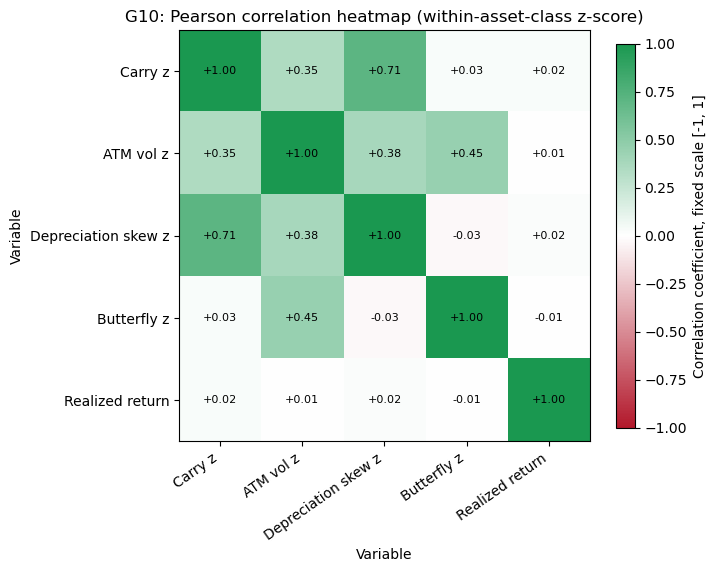

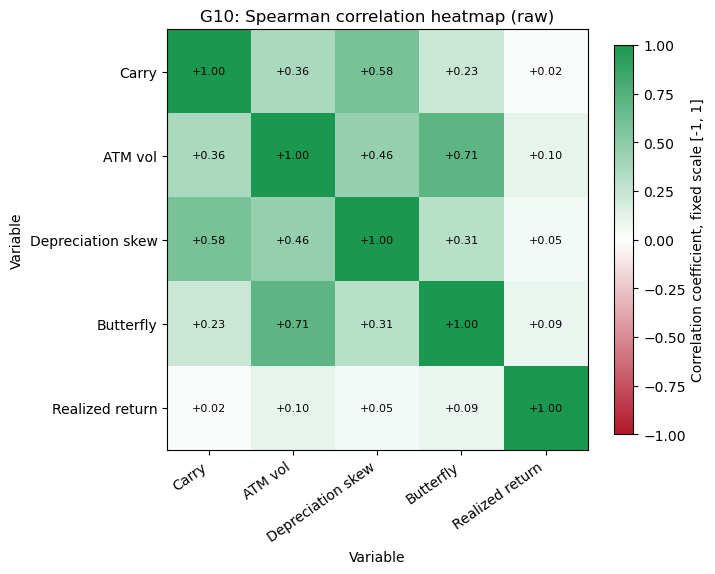

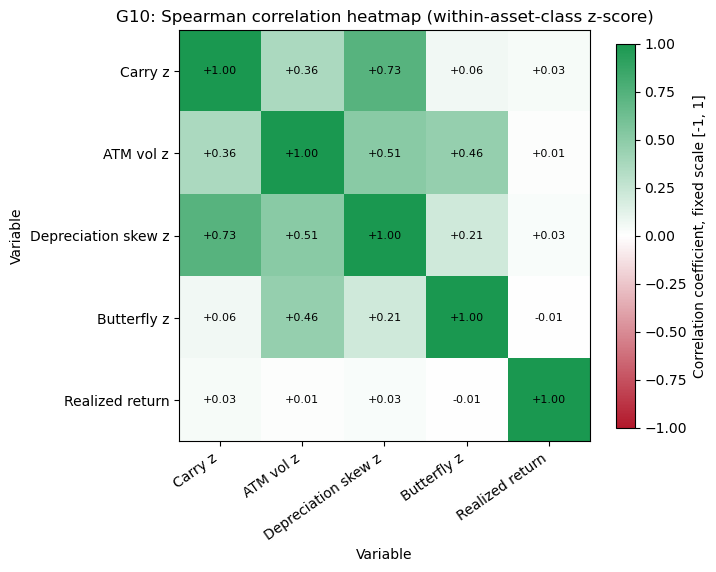

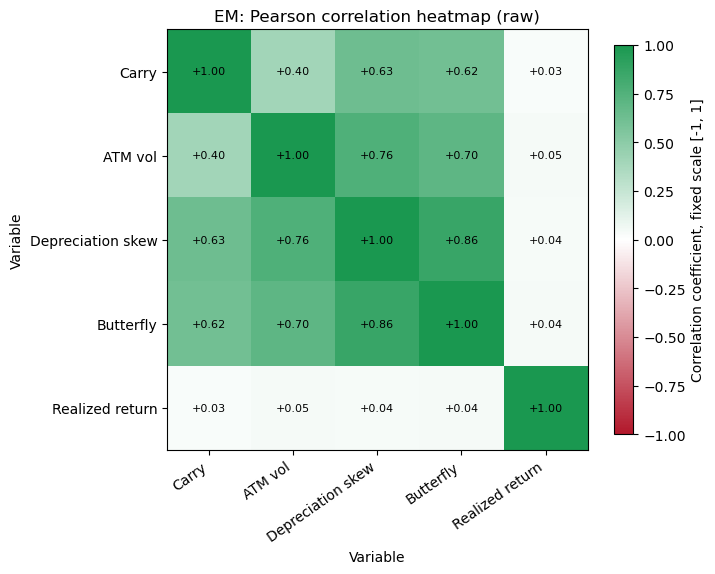

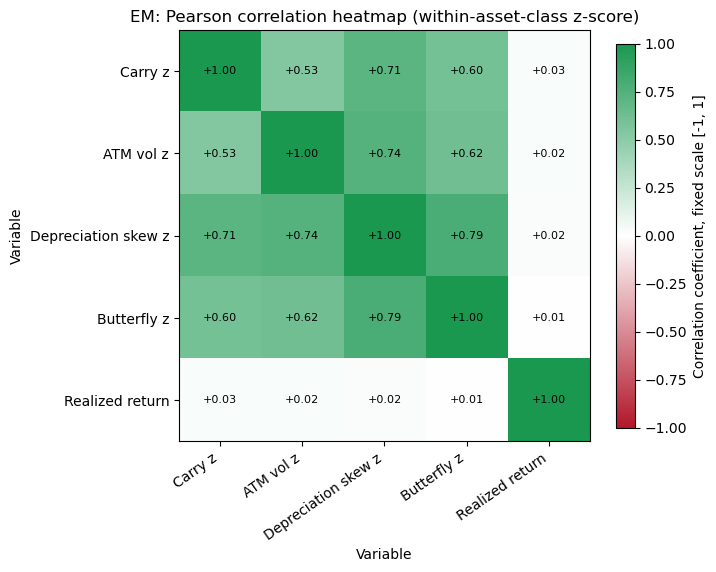

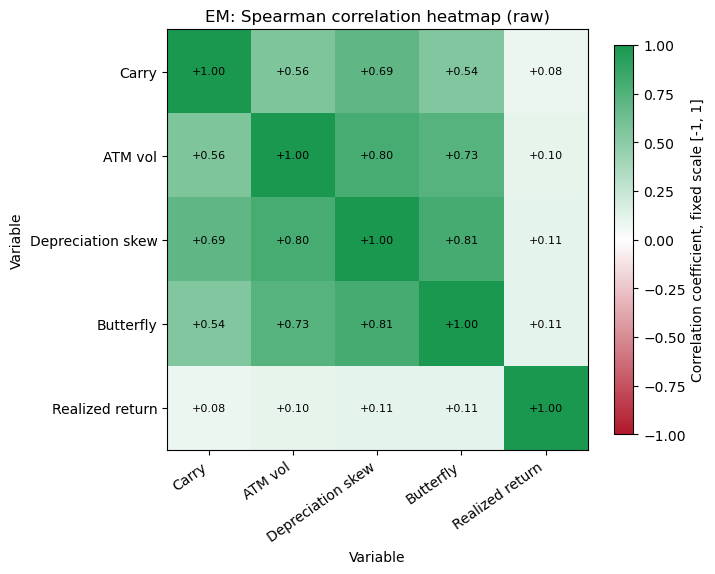

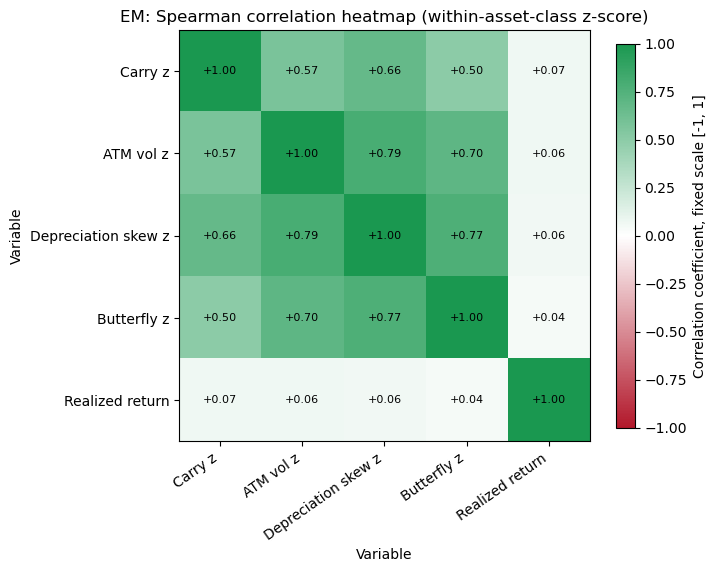

### Correlation table preview

,sample,transform,method,variable_x,variable_y,correlation
0,All,raw,pearson,carry_signal_1m,carry_signal_1m,+1.000
1,All,raw,pearson,carry_signal_1m,atm_vol_1m,+0.391
2,All,raw,pearson,carry_signal_1m,depreciation_skew_25d_1m,+0.658
3,All,raw,pearson,carry_signal_1m,bf25_1m,+0.638
4,All,raw,pearson,carry_signal_1m,realized_return_1m,+0.028
5,All,raw,pearson,atm_vol_1m,carry_signal_1m,+0.391
6,All,raw,pearson,atm_vol_1m,atm_vol_1m,+1.000
7,All,raw,pearson,atm_vol_1m,depreciation_skew_25d_1m,+0.652
8,All,raw,pearson,atm_vol_1m,bf25_1m,+0.681
9,All,raw,pearson,atm_vol_1m,realized_return_1m,+0.052


In [5]:
def correlation_records(df, sample, variable_set, method, transform_label):
    sub = get_sample(df, sample)
    corr = sub[variable_set].corr(method=method, min_periods=20)
    rows=[]
    for a in corr.index:
        for b in corr.columns:
            rows.append({"sample": sample, "transform": transform_label, "method": method, "variable_x": a, "variable_y": b, "correlation": corr.loc[a,b]})
    return pd.DataFrame(rows), corr

raw_corr_vars = ["carry_signal_1m", "atm_vol_1m", "depreciation_skew_25d_1m", "bf25_1m", "realized_return_1m"]
std_corr_vars = ["z_carry_class", "z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class", "realized_return_1m"]
CORR_LABELS = {
    "carry_signal_1m": "Carry",
    "atm_vol_1m": "ATM vol",
    "depreciation_skew_25d_1m": "Depreciation skew",
    "bf25_1m": "Butterfly",
    "realized_return_1m": "Realized return",
    "z_carry_class": "Carry z",
    "z_atm_vol_class": "ATM vol z",
    "z_depreciation_skew_class": "Depreciation skew z",
    "z_bf25_class": "Butterfly z",
}

correlation_tables=[]
correlation_matrices={}
for sample in ["All", "G10", "EM"]:
    for method in ["pearson", "spearman"]:
        for transform_label, vars_ in [("raw", raw_corr_vars), ("within-asset-class z-score", std_corr_vars)]:
            rec, corr = correlation_records(primary_panel, sample, vars_, method, transform_label)
            correlation_tables.append(rec)
            correlation_matrices[(sample, method, transform_label)] = corr
correlation_table = pd.concat(correlation_tables, ignore_index=True)

if PLOTTING_AVAILABLE:
    corr_cmap = RETURN_CMAP
    for (sample, method, transform_label), corr in correlation_matrices.items():
        fig, ax = plt.subplots(figsize=(7.2, 6.2))
        data = corr.to_numpy(dtype=float)
        im = ax.imshow(data, cmap=corr_cmap, vmin=-1, vmax=1)
        labels = [CORR_LABELS.get(v, v) for v in corr.columns]
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                val = data[r,c]
                if np.isfinite(val):
                    ax.text(c, r, f"{val:+.2f}", ha="center", va="center", fontsize=8)
        ax.set_title(f"{sample}: {method.title()} correlation heatmap ({transform_label})")
        ax.set_xlabel("Variable")
        ax.set_ylabel("Variable")
        cb = fig.colorbar(im, ax=ax, shrink=0.8)
        cb.set_label("Correlation coefficient, fixed scale [-1, 1]")
        plt.tight_layout(); savefig(fig, f"correlation_heatmap_{sample}_{method}_{transform_label.replace(' ', '_').replace('-', '_')}.png"); plt.show()
        correlation_validation_rows.append({"sample": sample, "method": method, "transform": transform_label, "vmin": -1, "vmax": 1, "center": 0, "valid_fixed_scale": True})

successful_sections.append("Pearson and Spearman correlation heatmaps with fixed red-white-green scale")
display(Markdown("### Correlation table preview")); display_df(correlation_table.head(30), {"correlation":"{:+.3f}"})

## Option-Signal Time Series, Cross-Sectional Standard Deviations, and Scatterplots

The charts in this section summarize the three option-surface signals equally. Cross-sectional variation is reported explicitly as standard deviation.

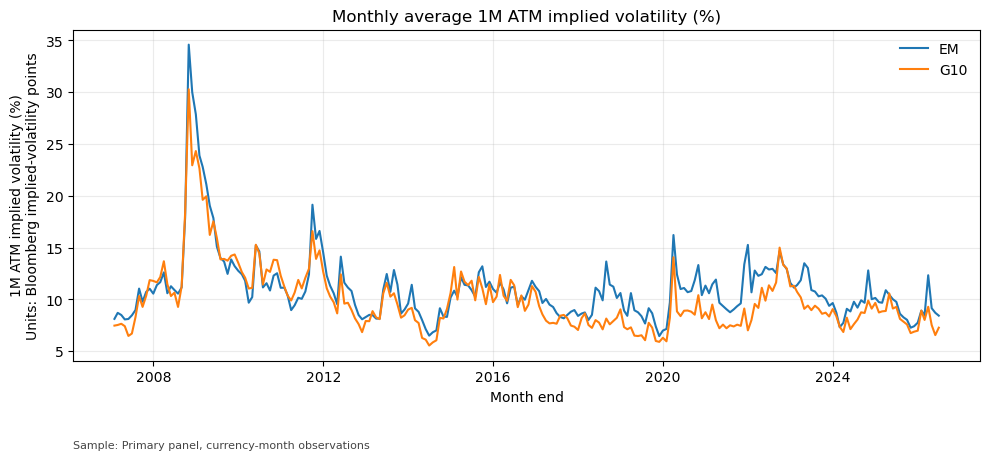

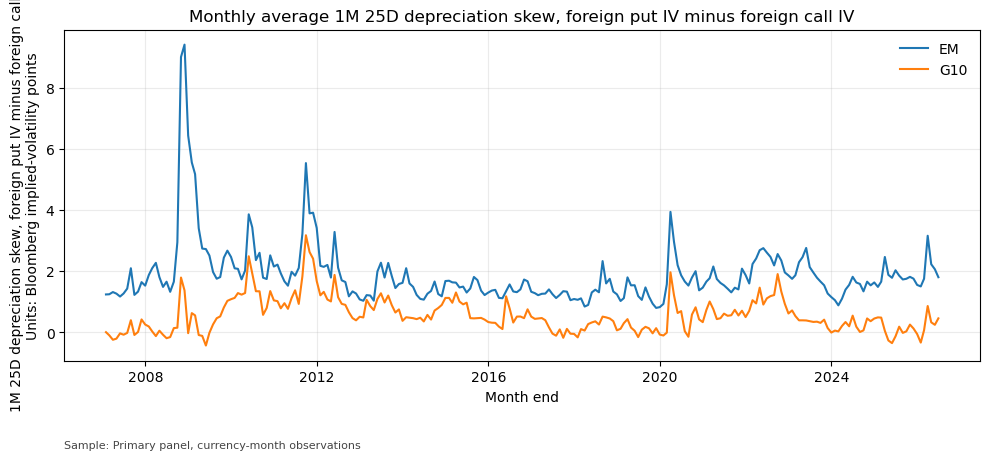

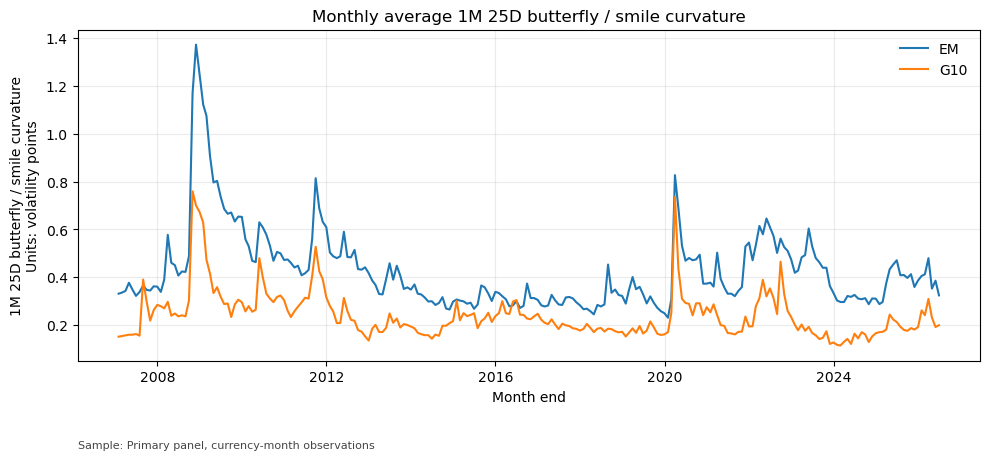

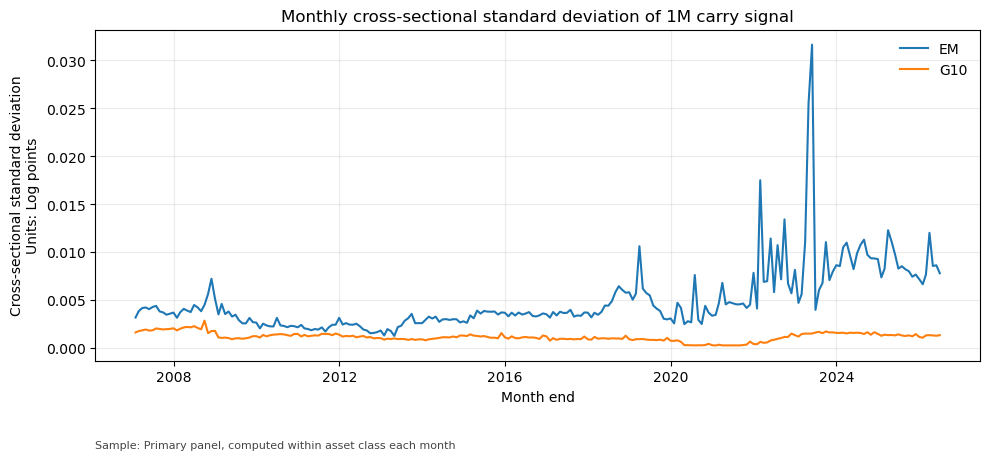

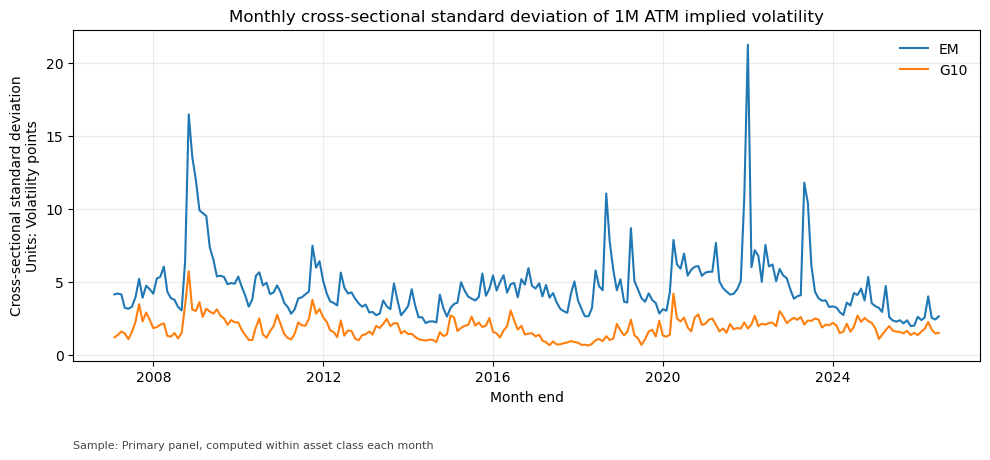

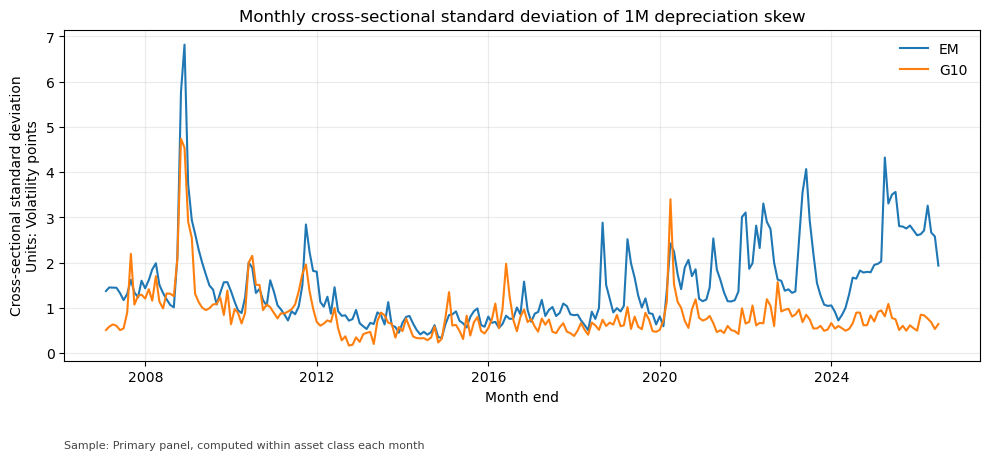

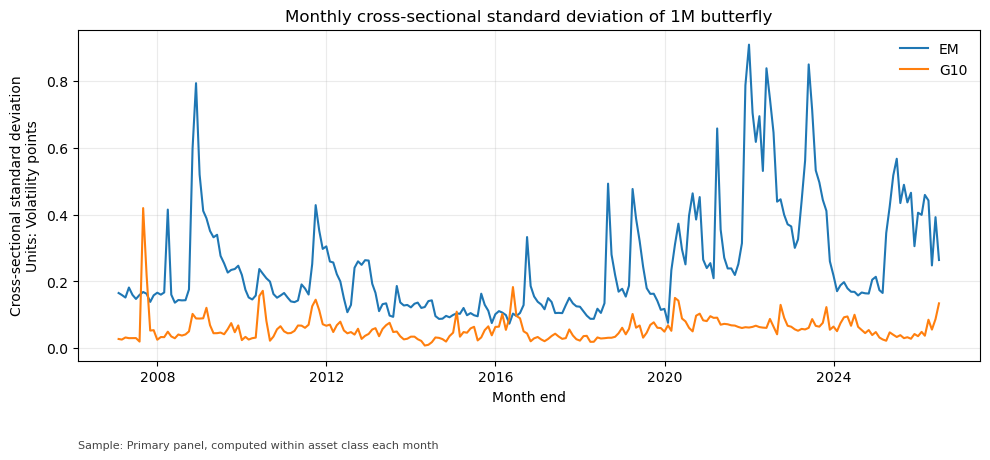

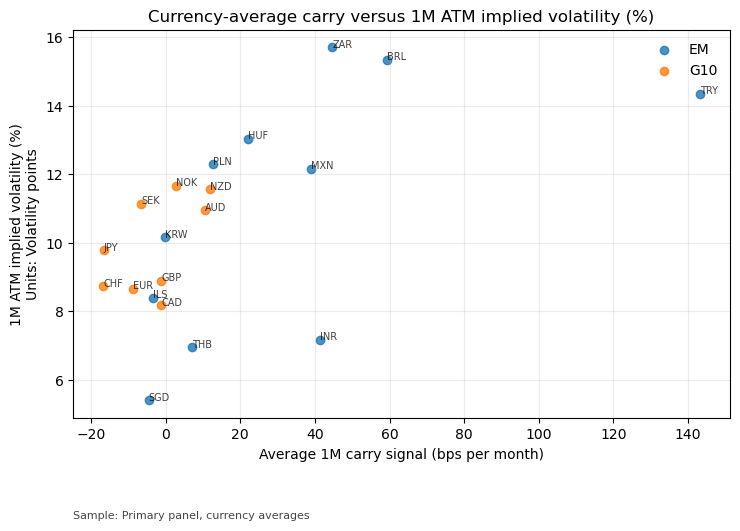

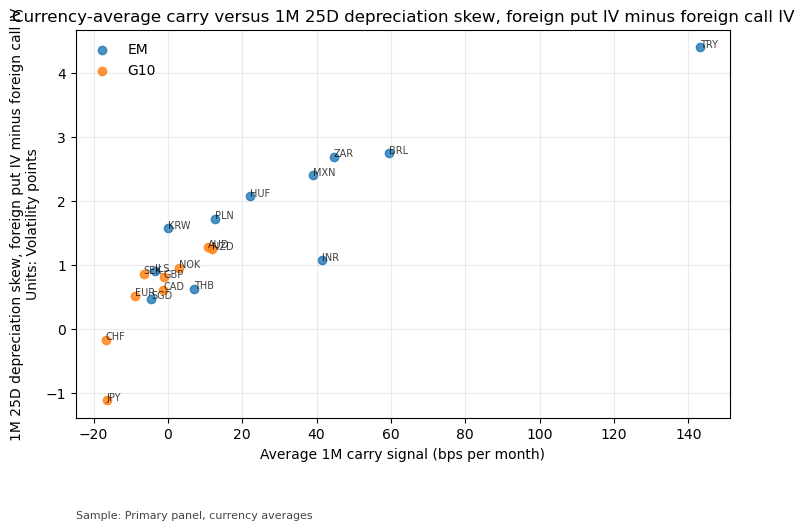

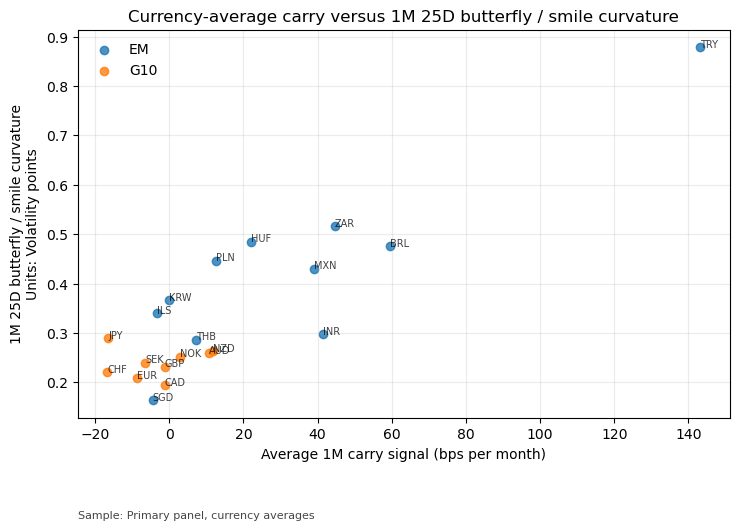

In [6]:
if PLOTTING_AVAILABLE:
    monthly_avg = primary_panel.groupby(["month_end", "asset_class"], as_index=False)[OPTION_SIGNAL_COLUMNS + ["carry_signal_1m"]].mean()
    for var in OPTION_SIGNAL_COLUMNS:
        fig, ax = plt.subplots(figsize=(10, 4.8))
        for sample, sub in monthly_avg.groupby("asset_class"):
            ax.plot(sub["month_end"], sub[var], label=sample)
        finalize_axis(ax, f"Monthly average {ECONOMIC_LABELS[var]}", "Month end", ECONOMIC_LABELS[var], sample_definition="Primary panel, currency-month observations", units="Bloomberg implied-volatility points" if var != "bf25_1m" else "volatility points", zero_axis=None)
        ax.legend(frameon=False)
        plt.tight_layout(); savefig(fig, f"timeseries_average_{var}.png"); plt.show()

    cs_std = primary_panel.groupby(["month_end", "asset_class"], as_index=False).agg(
        cs_std_carry=("carry_signal_1m", "std"),
        cs_std_atm_vol=("atm_vol_1m", "std"),
        cs_std_depreciation_skew=("depreciation_skew_25d_1m", "std"),
        cs_std_butterfly=("bf25_1m", "std"),
    )
    cs_std_specs = [
        ("cs_std_carry", "Monthly cross-sectional standard deviation of 1M carry signal", "Log points"),
        ("cs_std_atm_vol", "Monthly cross-sectional standard deviation of 1M ATM implied volatility", "Volatility points"),
        ("cs_std_depreciation_skew", "Monthly cross-sectional standard deviation of 1M depreciation skew", "Volatility points"),
        ("cs_std_butterfly", "Monthly cross-sectional standard deviation of 1M butterfly", "Volatility points"),
    ]
    for col, title, units in cs_std_specs:
        fig, ax = plt.subplots(figsize=(10, 4.8))
        for sample, sub in cs_std.groupby("asset_class"):
            ax.plot(sub["month_end"], sub[col], label=sample)
        finalize_axis(ax, title, "Month end", "Cross-sectional standard deviation", sample_definition="Primary panel, computed within asset class each month", units=units, zero_axis=None)
        ax.legend(frameon=False)
        plt.tight_layout(); savefig(fig, f"{col}.png"); plt.show()

    currency_avg = primary_panel.groupby(["currency", "asset_class"], as_index=False)[SIGNAL_COLUMNS + ["realized_return_1m"]].mean()
    for var in OPTION_SIGNAL_COLUMNS:
        fig, ax = plt.subplots(figsize=(7.5, 5.5))
        for sample, sub in currency_avg.groupby("asset_class"):
            ax.scatter(sub["carry_signal_1m"] * 10000, sub[var], label=sample, alpha=0.8)
            for _, row in sub.iterrows():
                ax.text(row["carry_signal_1m"] * 10000, row[var], row["currency"], fontsize=7, alpha=0.75)
        finalize_axis(ax, f"Currency-average carry versus {ECONOMIC_LABELS[var]}", "Average 1M carry signal (bps per month)", ECONOMIC_LABELS[var], sample_definition="Primary panel, currency averages", units="Volatility points" if var != "bf25_1m" else "Volatility points", zero_axis=None)
        ax.legend(frameon=False)
        plt.tight_layout(); savefig(fig, f"scatter_average_carry_vs_{var}.png"); plt.show()
else:
    note_skip("signal plots", "plotting unavailable")

successful_sections.append("time-series, cross-sectional standard-deviation, and currency-average signal plots")

## Conditional-Sort Heatmaps

Conditional-sort cells use month-$t$ signals and month-$t+1$ realized returns. The realized-return heatmaps use a custom red-white-green colormap with a pure white midpoint and symmetric limits around zero. Directly comparable All/G10/EM figures within each signal-pair family share one symmetric scale.

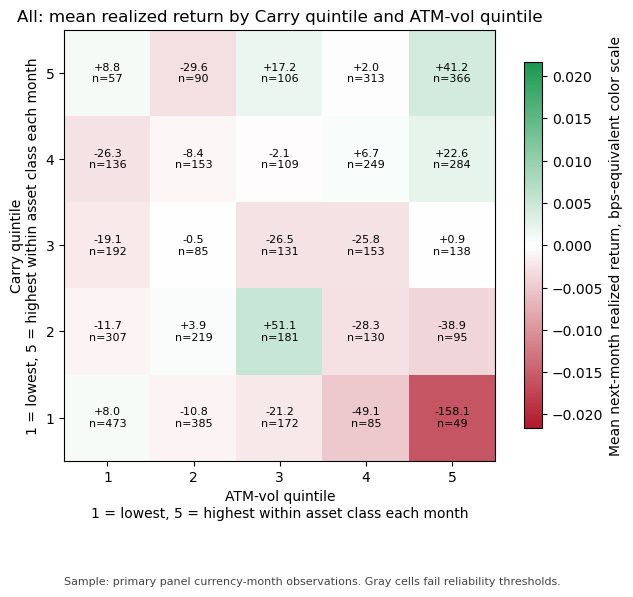

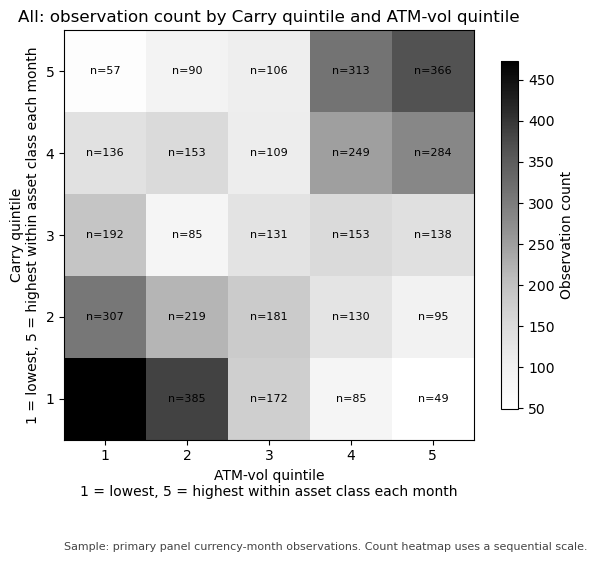

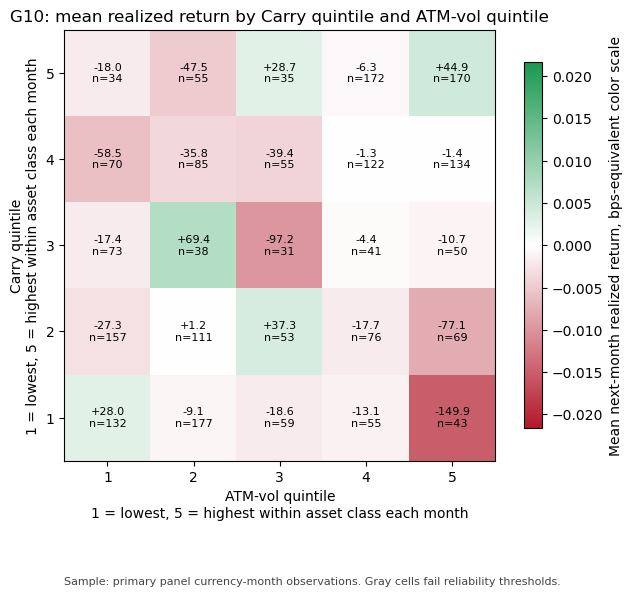

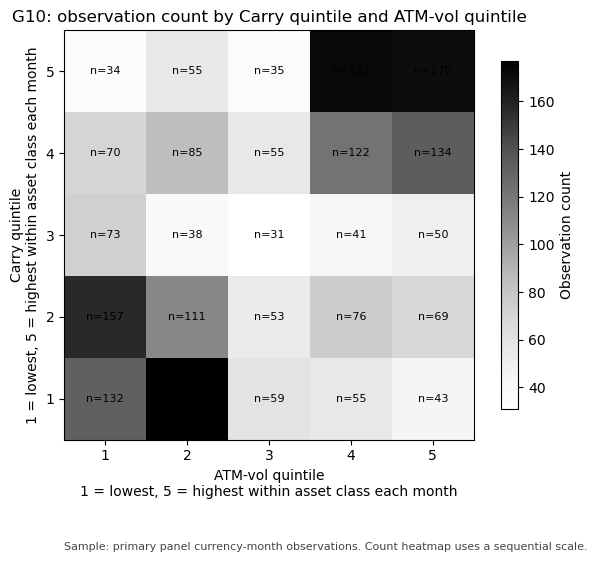

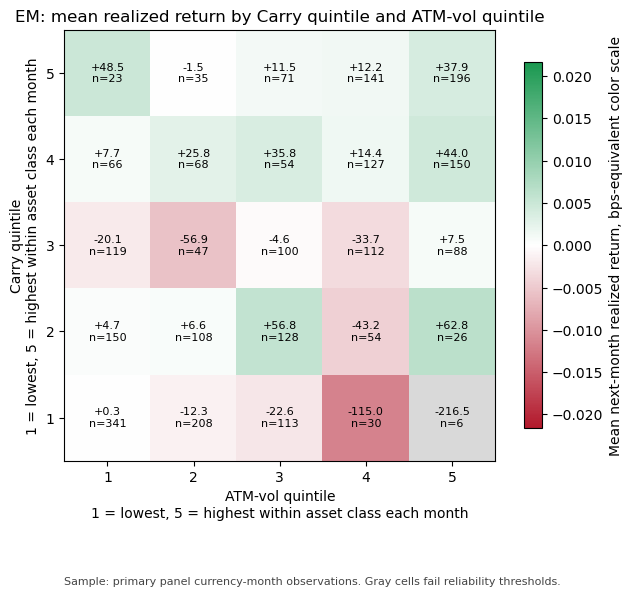

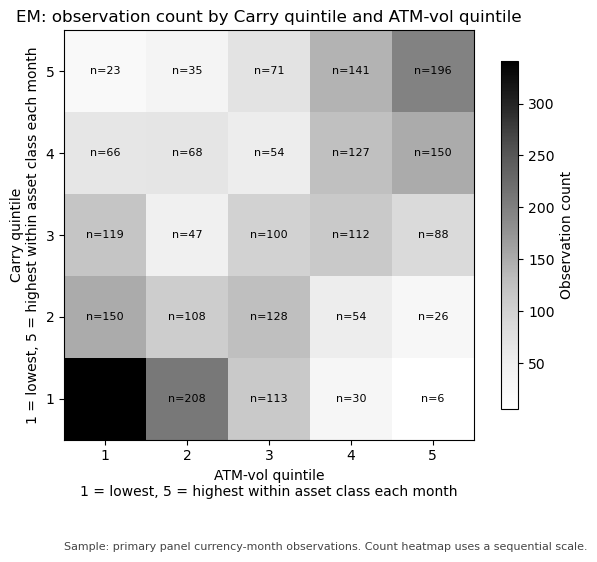

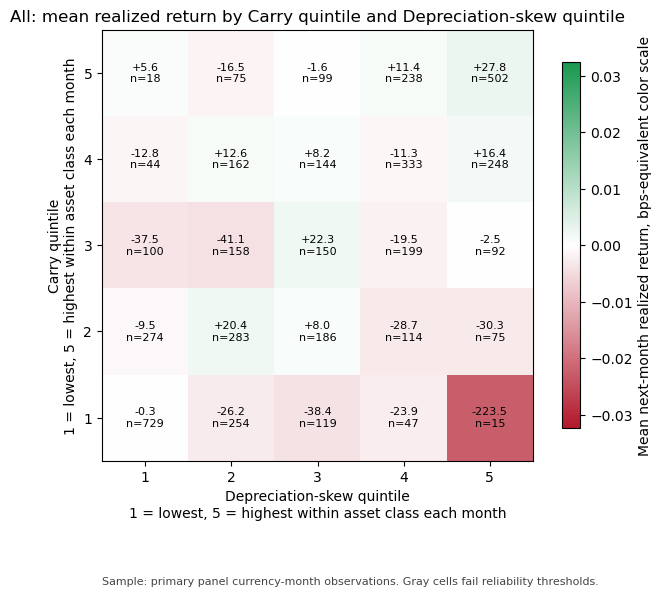

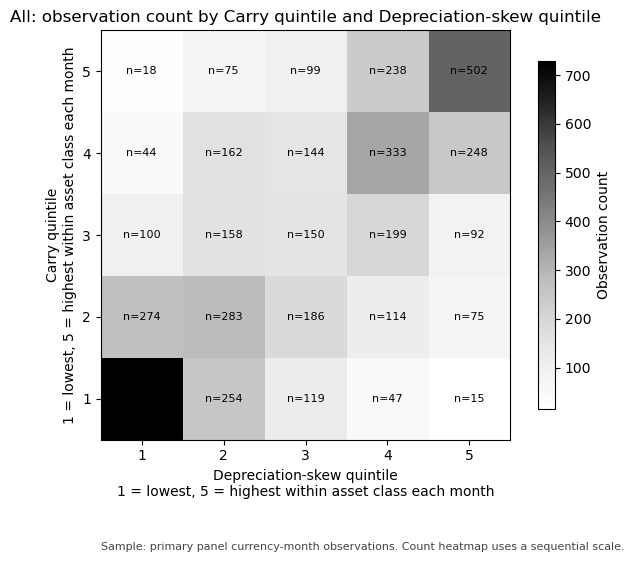

/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_4823/2856119386.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  suff = sub.pivot(index="row_quantile", columns="column_quantile", values="sufficient_cell").sort_index(ascending=False).reindex_like(piv).fillna(False)


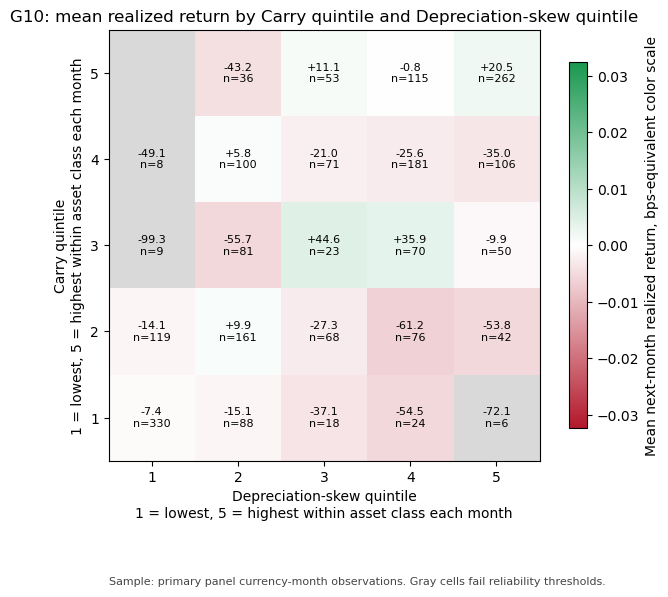

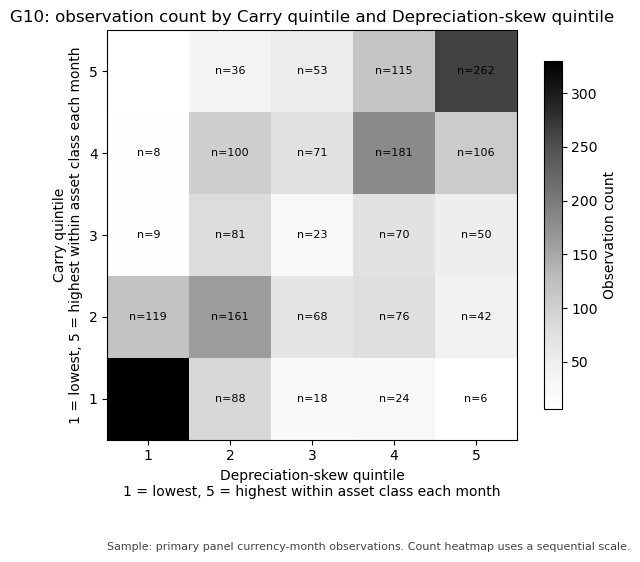

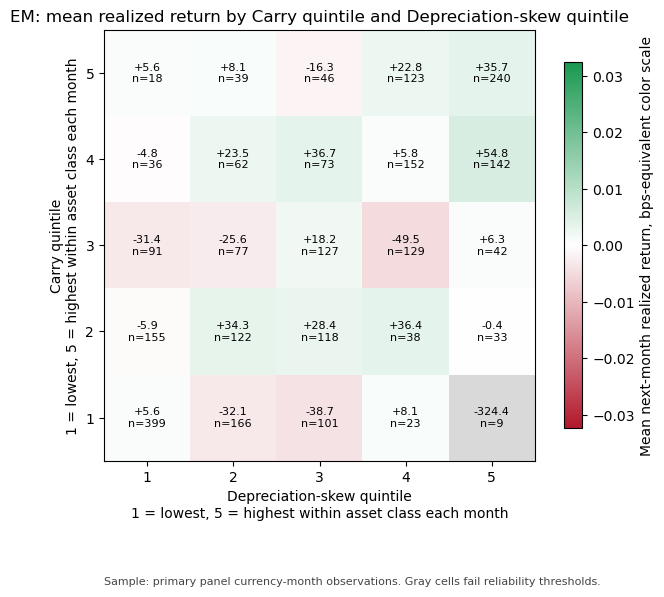

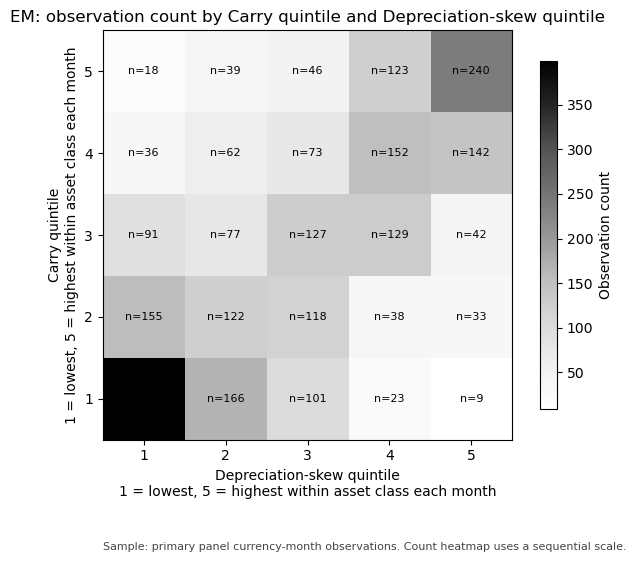

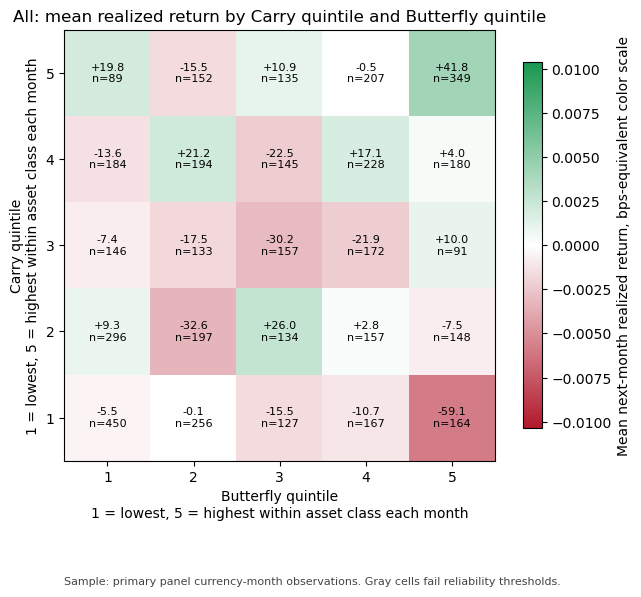

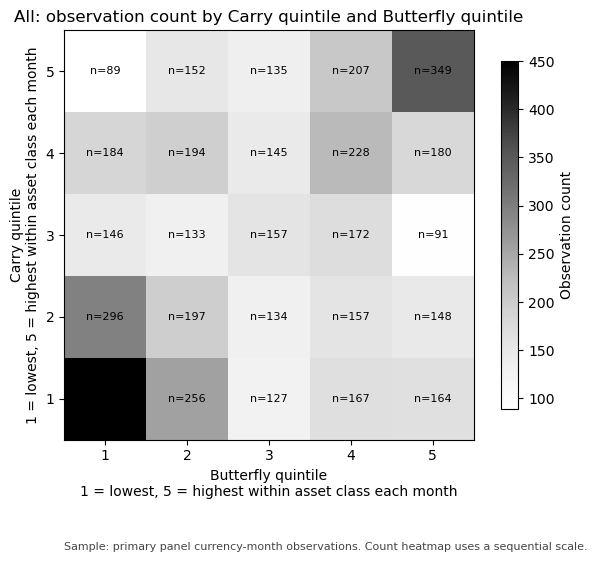

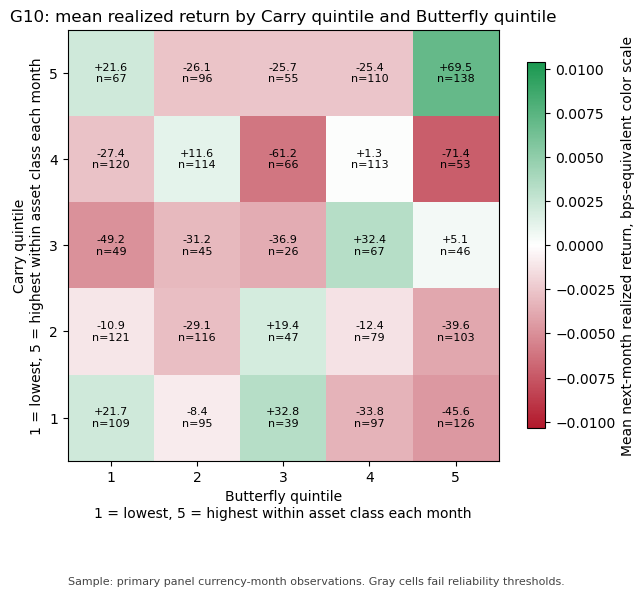

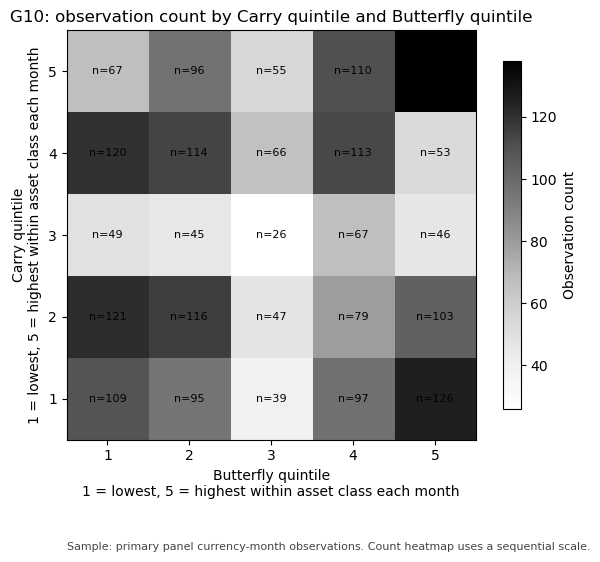

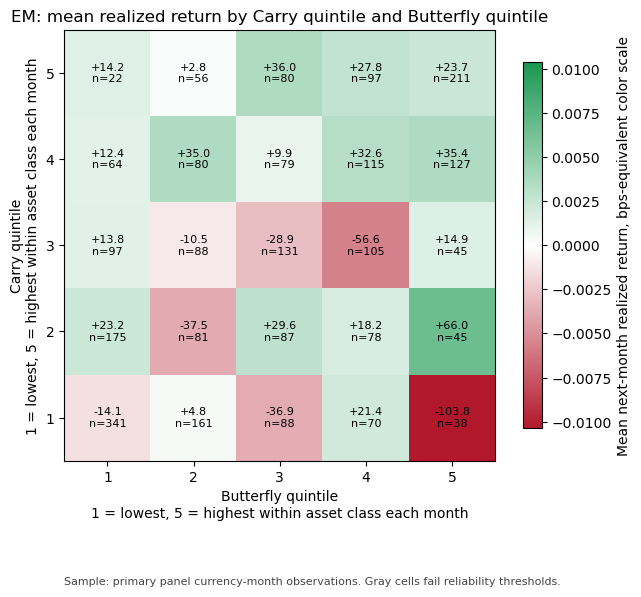

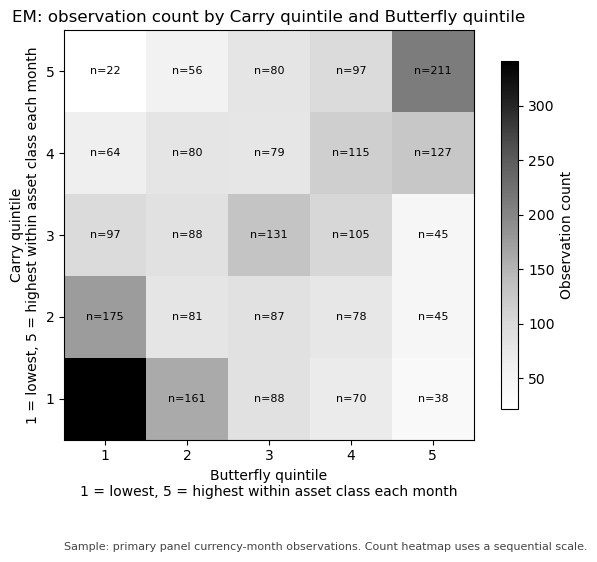

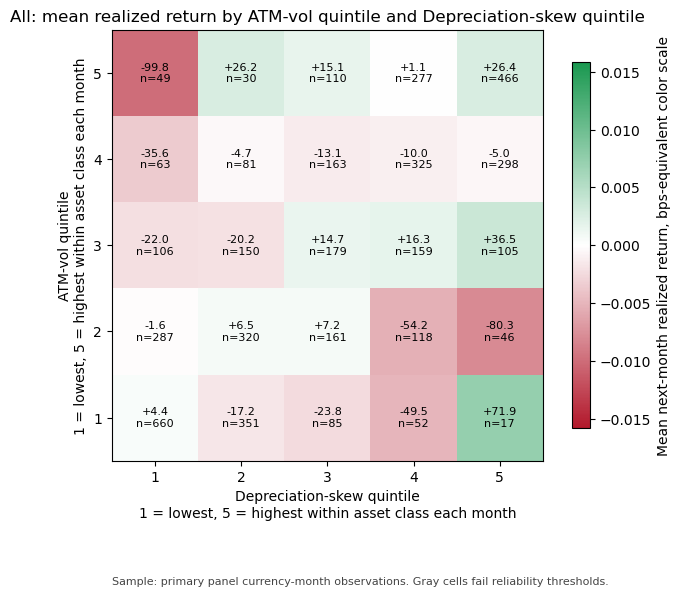

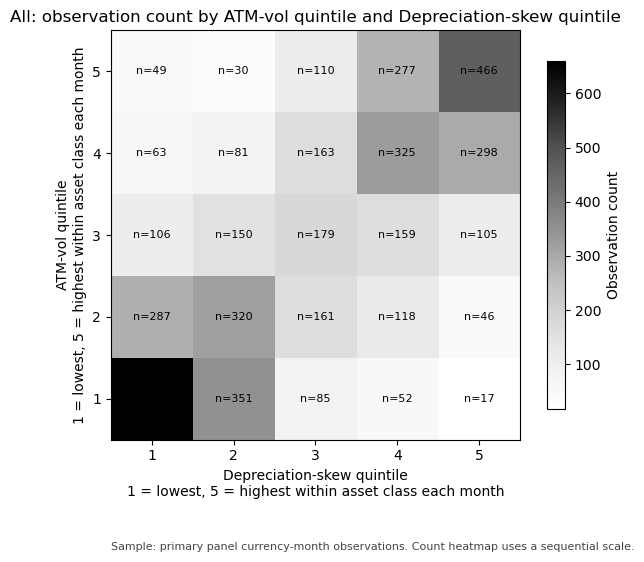

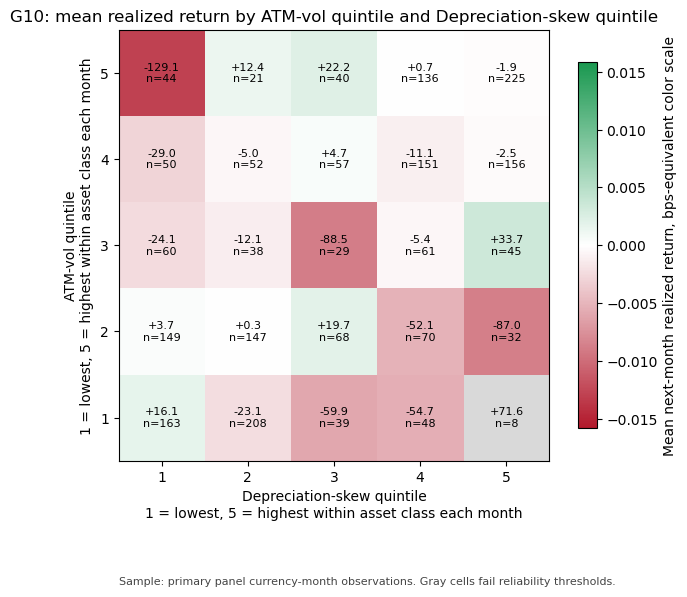

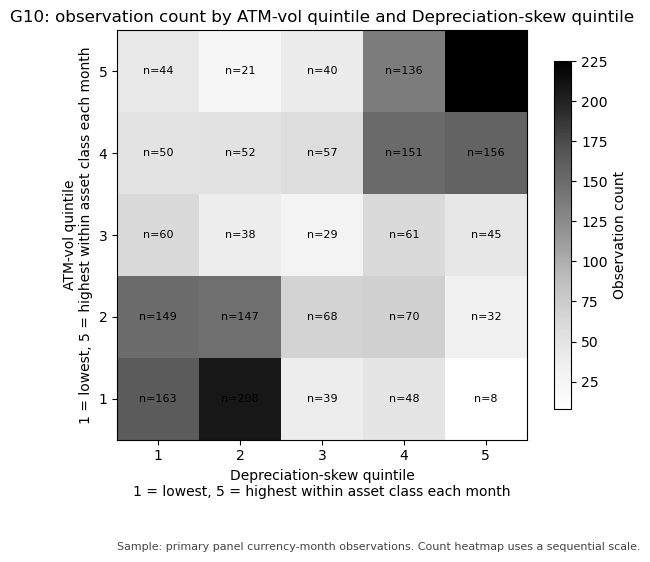

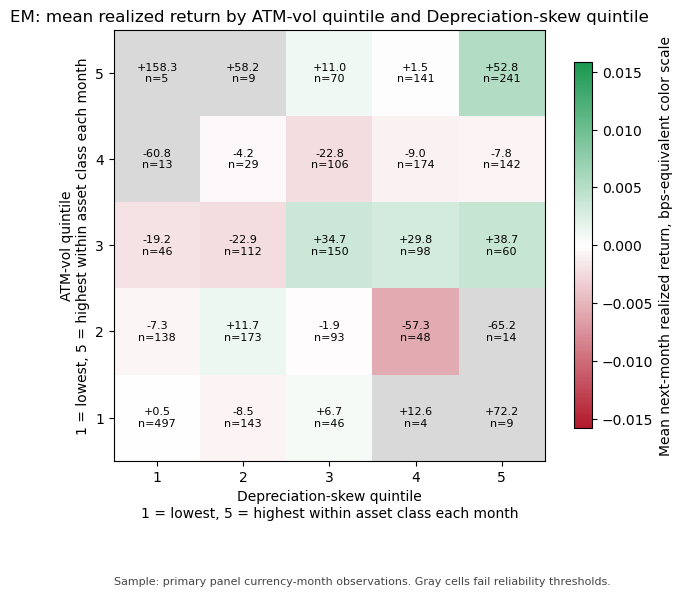

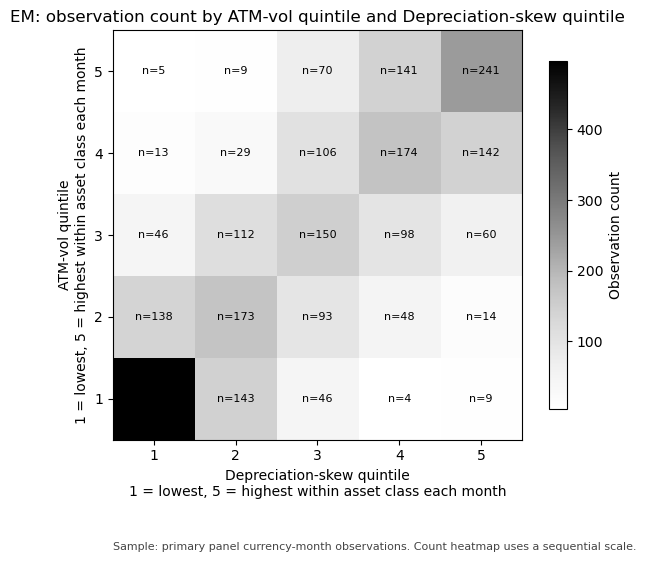

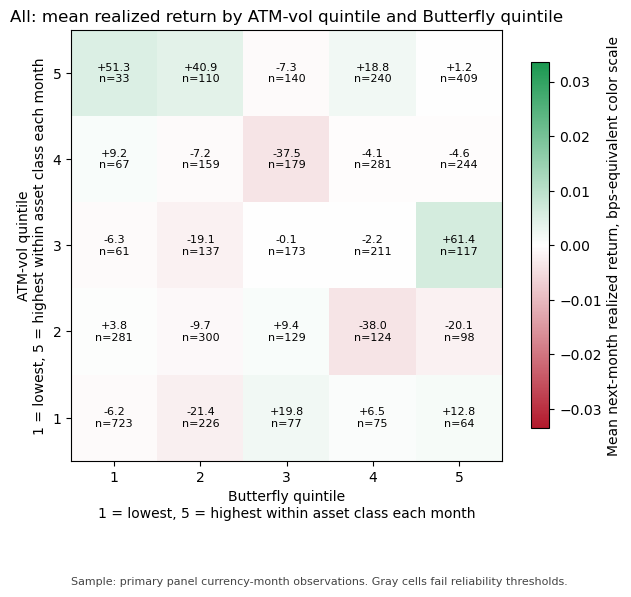

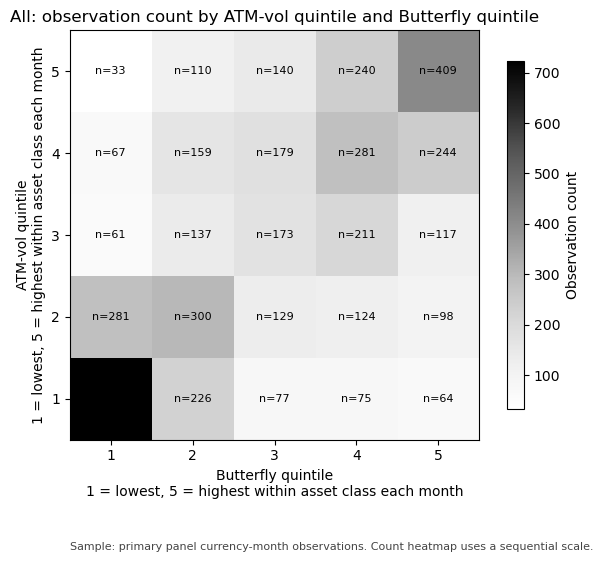

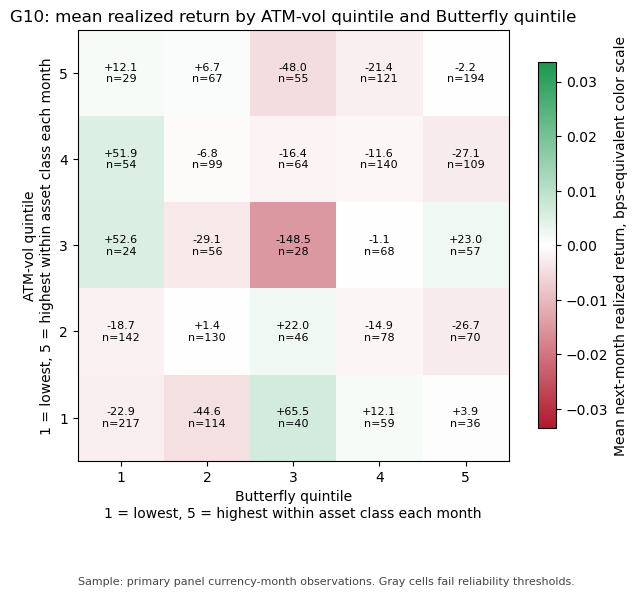

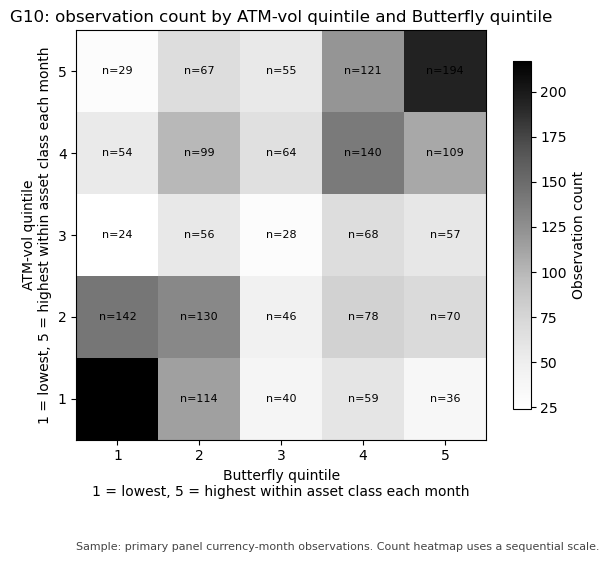

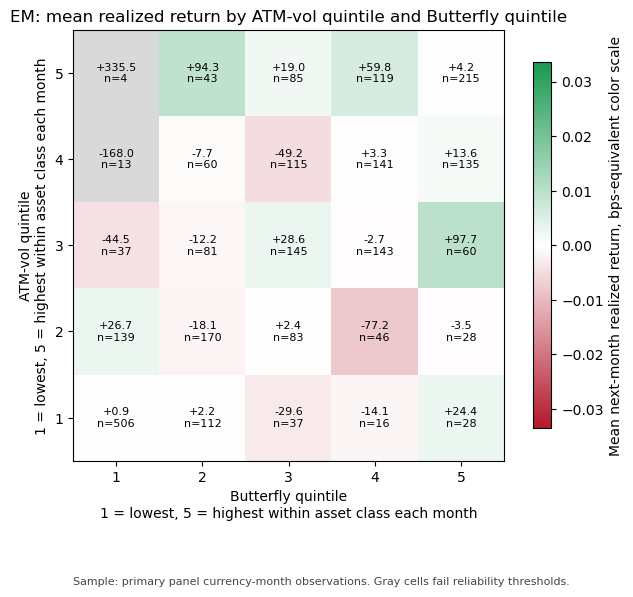

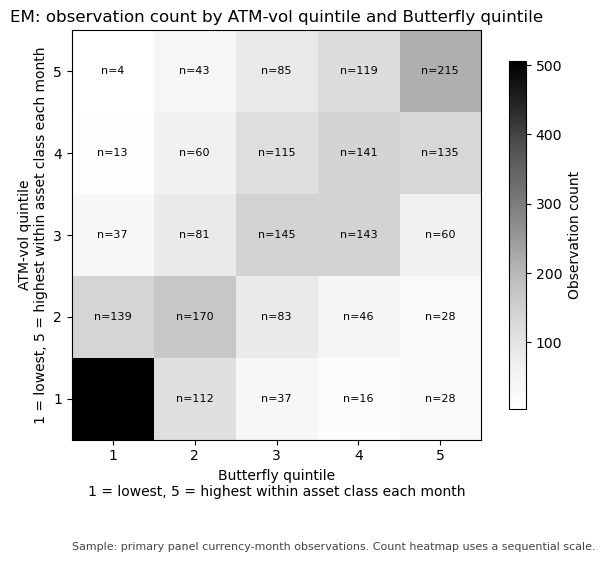

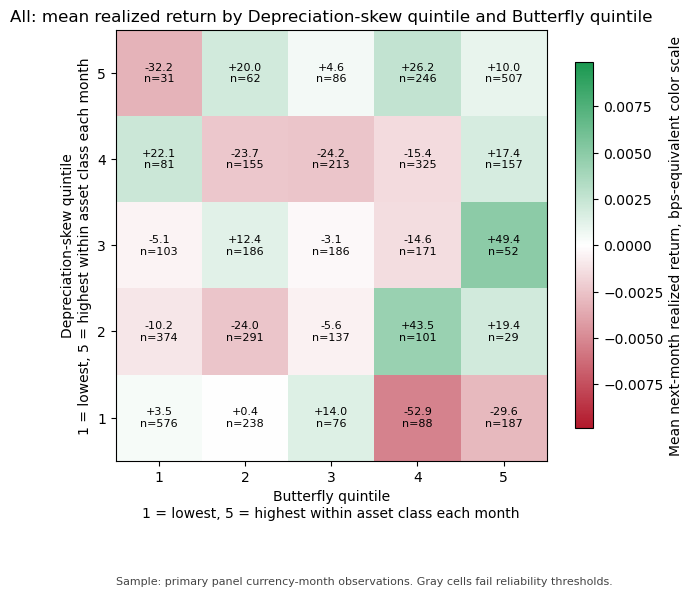

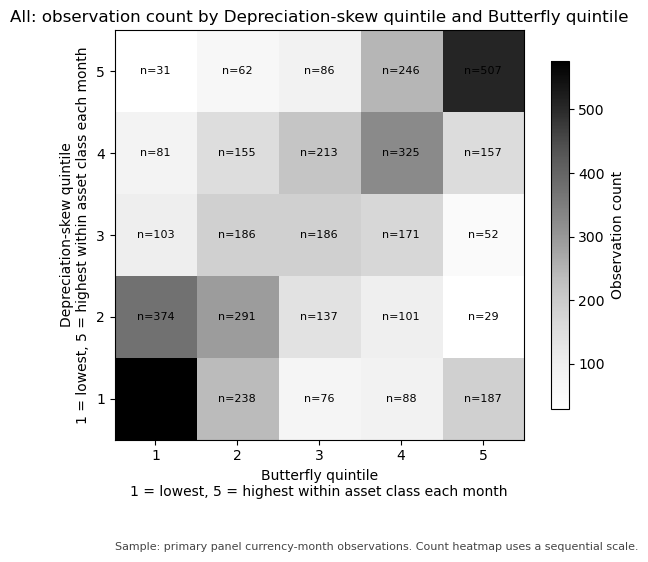

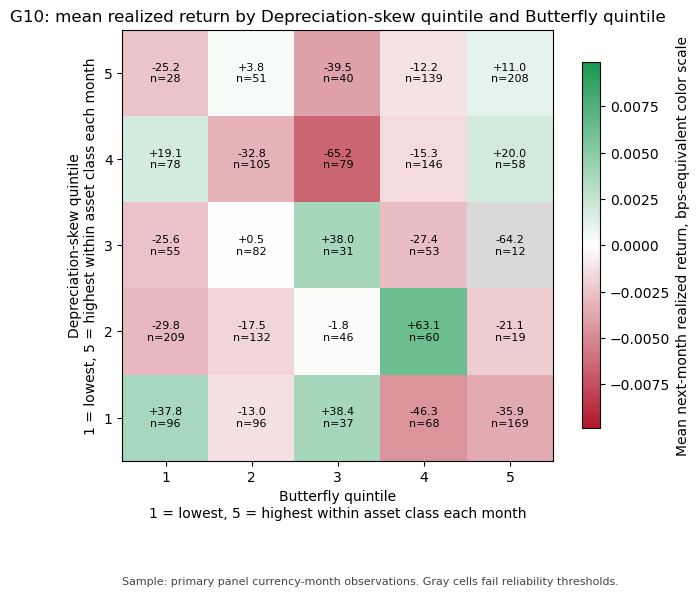

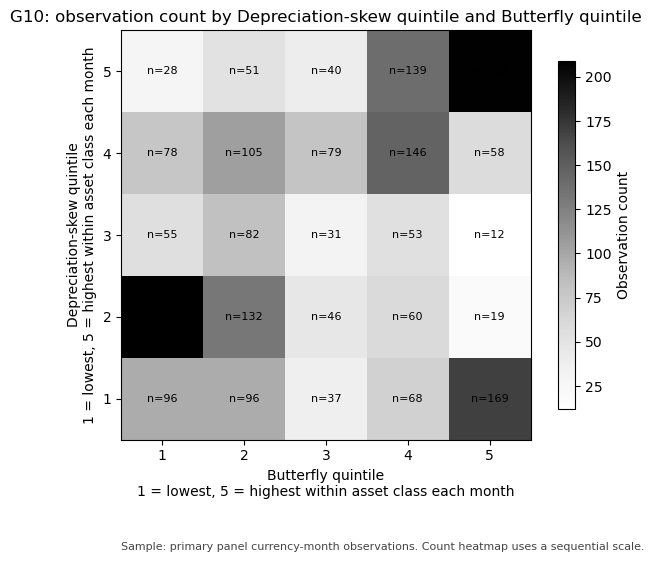

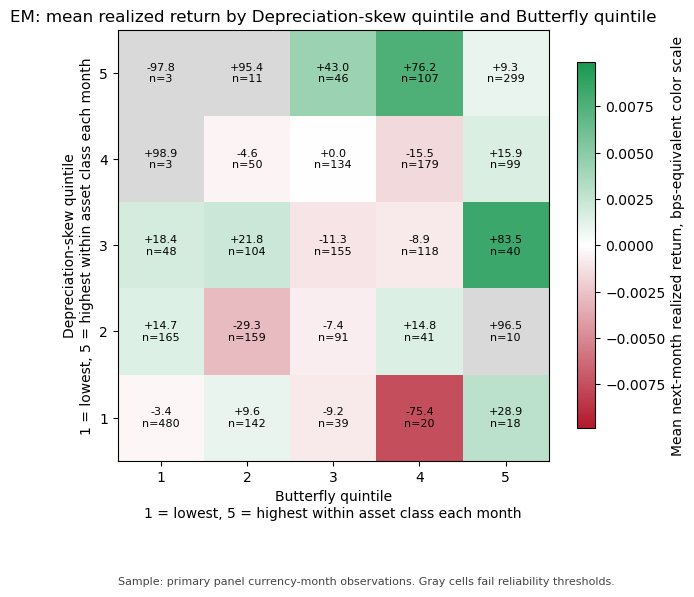

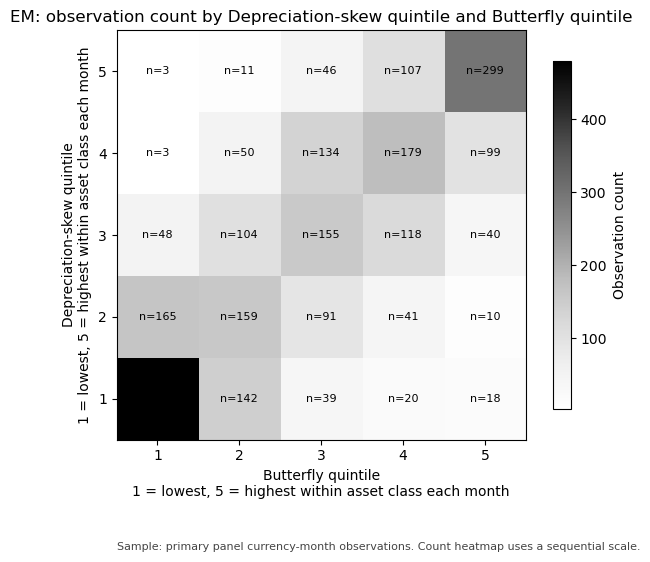

### Conditional-sort cell statistics

,sample,family,row_quantile,column_quantile,mean_realized_return,median_realized_return,std_realized_return,hit_rate,skewness,worst_observation,observations,unique_months,unique_currencies,sufficient_cell
0,All,carry_x_atm_vol,1,1,+0.00080,+0.00060,0.02226,51.4%,+0.18,-0.08211,473,225,7,True
1,All,carry_x_atm_vol,1,2,-0.00108,+0.00050,0.02615,51.2%,-0.19,-0.09711,385,210,11,True
2,All,carry_x_atm_vol,1,3,-0.00212,-0.00072,0.02860,48.8%,-0.16,-0.07240,172,142,9,True
3,All,carry_x_atm_vol,1,4,-0.00491,-0.00171,0.03891,47.1%,-0.44,-0.14236,85,72,8,True
4,All,carry_x_atm_vol,1,5,-0.01581,-0.00965,0.04369,36.7%,+0.24,-0.13482,49,49,5,True
5,All,carry_x_atm_vol,2,1,-0.00117,-0.00089,0.02026,48.2%,-0.98,-0.13220,307,195,11,True
6,All,carry_x_atm_vol,2,2,+0.00039,+0.00217,0.02601,53.4%,-0.42,-0.10513,219,167,13,True
7,All,carry_x_atm_vol,2,3,+0.00511,+0.00296,0.03165,56.4%,-0.12,-0.09653,181,146,11,True
8,All,carry_x_atm_vol,2,4,-0.00283,-0.00097,0.03146,50.0%,-0.38,-0.11689,130,110,12,True
9,All,carry_x_atm_vol,2,5,-0.00389,-0.00195,0.04141,46.3%,-0.27,-0.15563,95,86,6,True


In [7]:
HEATMAP_FAMILIES = [
    ("carry_x_atm_vol", "q_carry_class", "q_atm_vol_class", "Carry quintile", "ATM-vol quintile"),
    ("carry_x_depreciation_skew", "q_carry_class", "q_depreciation_skew_class", "Carry quintile", "Depreciation-skew quintile"),
    ("carry_x_butterfly", "q_carry_class", "q_bf25_class", "Carry quintile", "Butterfly quintile"),
    ("atm_vol_x_depreciation_skew", "q_atm_vol_class", "q_depreciation_skew_class", "ATM-vol quintile", "Depreciation-skew quintile"),
    ("atm_vol_x_butterfly", "q_atm_vol_class", "q_bf25_class", "ATM-vol quintile", "Butterfly quintile"),
    ("depreciation_skew_x_butterfly", "q_depreciation_skew_class", "q_bf25_class", "Depreciation-skew quintile", "Butterfly quintile"),
]

def make_heatmap_cells(df, sample, family, row_q, col_q):
    sub = get_sample(df, sample).dropna(subset=[row_q, col_q, Y_COL]).copy()
    rows=[]
    for (rq, cq), g in sub.groupby([row_q, col_q], sort=True):
        x = g[Y_COL].dropna()
        rows.append({
            "sample": sample,
            "family": family,
            "row_quantile": int(rq),
            "column_quantile": int(cq),
            "mean_realized_return": x.mean(),
            "median_realized_return": x.median(),
            "std_realized_return": x.std(ddof=1),
            "hit_rate": (x > 0).mean(),
            "skewness": x.skew(),
            "worst_observation": x.min(),
            "observations": int(len(x)),
            "unique_months": int(g["month_end"].nunique()),
            "unique_currencies": int(g["currency"].nunique()),
            "sufficient_cell": bool(len(x) >= MIN_CELL_OBS and g["month_end"].nunique() >= MIN_CELL_MONTHS),
        })
    return pd.DataFrame(rows)

heatmap_cells = pd.concat([
    make_heatmap_cells(primary_panel, sample, family, row_q, col_q)
    for family, row_q, col_q, _, _ in HEATMAP_FAMILIES
    for sample in ["All", "G10", "EM"]
], ignore_index=True)

family_limits = heatmap_cells.groupby("family")["mean_realized_return"].apply(symmetric_limit).to_dict()

if PLOTTING_AVAILABLE:
    midpoint = RETURN_CMAP(0.5)[:3]
    midpoint_is_white = all(abs(v - 1.0) < 0.02 for v in midpoint)
    for family, row_q, col_q, row_label, col_label in HEATMAP_FAMILIES:
        limit = family_limits.get(family, 0.001)
        for sample in ["All", "G10", "EM"]:
            sub = heatmap_cells[(heatmap_cells["family"].eq(family)) & (heatmap_cells["sample"].eq(sample))]
            if sub.empty:
                continue
            piv = sub.pivot(index="row_quantile", columns="column_quantile", values="mean_realized_return").sort_index(ascending=False)
            cnt = sub.pivot(index="row_quantile", columns="column_quantile", values="observations").sort_index(ascending=False)
            suff = sub.pivot(index="row_quantile", columns="column_quantile", values="sufficient_cell").sort_index(ascending=False).reindex_like(piv).fillna(False)
            masked = np.ma.masked_where(~suff.to_numpy(dtype=bool), piv.to_numpy(dtype=float))
            cmap = RETURN_CMAP.copy(); cmap.set_bad(color="#D9D9D9")
            norm = TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)
            fig, ax = plt.subplots(figsize=(6.8, 5.8))
            im = ax.imshow(masked, cmap=cmap, norm=norm)
            ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([int(x) for x in piv.columns])
            ax.set_yticks(range(len(piv.index))); ax.set_yticklabels([int(x) for x in piv.index])
            ax.set_title(f"{sample}: mean realized return by {row_label} and {col_label}")
            ax.set_xlabel(f"{col_label}\n1 = lowest, 5 = highest within asset class each month")
            ax.set_ylabel(f"{row_label}\n1 = lowest, 5 = highest within asset class each month")
            for i, rq in enumerate(piv.index):
                for j, cq in enumerate(piv.columns):
                    val = piv.loc[rq, cq]
                    n = cnt.loc[rq, cq] if rq in cnt.index and cq in cnt.columns else np.nan
                    if np.isfinite(val):
                        ax.text(j, i, f"{val*10000:+.1f}\nn={int(n) if np.isfinite(n) else 0}", ha="center", va="center", fontsize=8)
            cb = fig.colorbar(im, ax=ax, shrink=0.85)
            cb.set_label("Mean next-month realized return, bps-equivalent color scale")
            ax.text(0.0, -0.27, "Sample: primary panel currency-month observations. Gray cells fail reliability thresholds.", transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#444444")
            plt.tight_layout(); savefig(fig, f"heatmap_return_{family}_{sample}.png"); plt.show()
            heatmap_validation_rows.append({
                "figure": f"heatmap_return_{family}_{sample}.png", "family": family, "sample": sample,
                "return_colormap_midpoint_white": midpoint_is_white, "centered_at_zero": True,
                "symmetric_limits": bool(np.isclose(limit, abs(-limit))), "family_limit": float(limit),
                "count_uses_return_cmap": False,
            })

            fig, ax = plt.subplots(figsize=(6.5, 5.5))
            im = ax.imshow(cnt.to_numpy(dtype=float), cmap=COUNT_CMAP)
            ax.set_xticks(range(len(cnt.columns))); ax.set_xticklabels([int(x) for x in cnt.columns])
            ax.set_yticks(range(len(cnt.index))); ax.set_yticklabels([int(x) for x in cnt.index])
            ax.set_title(f"{sample}: observation count by {row_label} and {col_label}")
            ax.set_xlabel(f"{col_label}\n1 = lowest, 5 = highest within asset class each month")
            ax.set_ylabel(f"{row_label}\n1 = lowest, 5 = highest within asset class each month")
            for i, rq in enumerate(cnt.index):
                for j, cq in enumerate(cnt.columns):
                    n = cnt.loc[rq, cq]
                    if np.isfinite(n):
                        ax.text(j, i, f"n={int(n)}", ha="center", va="center", fontsize=8)
            cb = fig.colorbar(im, ax=ax, shrink=0.85)
            cb.set_label("Observation count")
            ax.text(0.0, -0.25, "Sample: primary panel currency-month observations. Count heatmap uses a sequential scale.", transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#444444")
            plt.tight_layout(); savefig(fig, f"heatmap_count_{family}_{sample}.png"); plt.show()
            heatmap_validation_rows.append({"figure": f"heatmap_count_{family}_{sample}.png", "family": family, "sample": sample, "count_uses_return_cmap": False})
else:
    note_skip("conditional heatmap plotting", "plotting unavailable")

successful_sections.append("conditional-sort return and count heatmaps for all option-surface signal pairs")
display(Markdown("### Conditional-sort cell statistics")); display_df(heatmap_cells, {"mean_realized_return":"{:+.5f}", "median_realized_return":"{:+.5f}", "std_realized_return":"{:.5f}", "hit_rate":"{:.1%}", "skewness":"{:+.2f}", "worst_observation":"{:+.5f}"})

## Regression Infrastructure

The dependent variable is `realized_return_1m`. Classical IID, HC3, month-clustered, currency-clustered, and two-way-clustered inference are retained in the saved diagnostic tables. Compact notebook tables emphasize the preferred two-way-clustered inference.

In [8]:
MODEL_TERMS = {
    "M0 carry only": ["carry"],
    "M1 all main effects": ["carry", "atm_vol", "depreciation_skew", "bf25"],
    "M2 carry x ATM vol": ["carry", "atm_vol", "depreciation_skew", "bf25", "carry_x_atm_vol"],
    "M3 carry x depreciation skew": ["carry", "atm_vol", "depreciation_skew", "bf25", "carry_x_depreciation_skew"],
    "M4 carry x butterfly": ["carry", "atm_vol", "depreciation_skew", "bf25", "carry_x_bf25"],
    "M5 joint carry-conditioner": ["carry", "atm_vol", "depreciation_skew", "bf25", "carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"],
}
PRIMARY_MODEL = "M5 joint carry-conditioner"

MODEL_FORMULAS = {
    "M0 carry only": r"""
$$
r_{i,t+1}=\alpha+\beta_C C_{i,t}+\varepsilon_{i,t+1}.
$$
""",
    "M1 all main effects": r"""
$$
r_{i,t+1}=\alpha+\beta_C C_{i,t}+\beta_V V_{i,t}+\beta_D D_{i,t}+\beta_B B_{i,t}+\varepsilon_{i,t+1}.
$$
""",
    "M2 carry x ATM vol": r"""
$$
r_{i,t+1}=\alpha+\beta_C C+\beta_V V+\beta_D D+\beta_B B+\beta_{CV}CV+\varepsilon.
$$
""",
    "M3 carry x depreciation skew": r"""
$$
r_{i,t+1}=\alpha+\beta_C C+\beta_V V+\beta_D D+\beta_B B+\beta_{CD}CD+\varepsilon.
$$
""",
    "M4 carry x butterfly": r"""
$$
r_{i,t+1}=\alpha+\beta_C C+\beta_V V+\beta_D D+\beta_B B+\beta_{CB}CB+\varepsilon.
$$
""",
    "M5 joint carry-conditioner": r"""
$$
\boxed{
\begin{aligned}
r_{i,t+1}
=&\ \alpha
+\beta_C C_{i,t}
+\beta_V V_{i,t}
+\beta_D D_{i,t}
+\beta_B B_{i,t}\\
&+\beta_{CV}C_{i,t}V_{i,t}
+\beta_{CD}C_{i,t}D_{i,t}
+\beta_{CB}C_{i,t}B_{i,t}
+\varepsilon_{i,t+1}.
\end{aligned}
}
$$

$$
\frac{\partial E[r_{i,t+1}]}{\partial C_{i,t}}
=
\beta_C+\beta_{CV}V_{i,t}+\beta_{CD}D_{i,t}+\beta_{CB}B_{i,t}.
$$
""",
}

MODEL_QUESTIONS = {
    "M0 carry only": "Does carry alone forecast next-month realized FX returns?",
    "M1 all main effects": "Do ATM volatility, depreciation skew, and butterfly add unconditional information alongside carry?",
    "M2 carry x ATM vol": "Does the carry premium vary with option-implied volatility?",
    "M3 carry x depreciation skew": "Does the carry premium vary with the price of foreign-currency depreciation protection?",
    "M4 carry x butterfly": "Does the carry premium vary with smile curvature?",
    "M5 joint carry-conditioner": "When all three option-surface conditioning channels enter together, which carry interactions remain economically meaningful?",
}


def add_design_columns(df, suffix="class", raw=False, rank=False, mad=False, winsor_tag=None, include_10d=False, include_state=False):
    d = df.copy()
    if raw:
        d["carry"] = d["carry_signal_1m"]
        d["atm_vol"] = d["atm_vol_1m"]
        d["depreciation_skew"] = d["depreciation_skew_25d_1m"]
        d["bf25"] = d["bf25_1m"]
    elif rank:
        d["carry"] = d[f"rank_carry_{suffix}"]
        d["atm_vol"] = d[f"rank_atm_vol_{suffix}"]
        d["depreciation_skew"] = d[f"rank_depreciation_skew_{suffix}"]
        d["bf25"] = d[f"rank_bf25_{suffix}"]
    elif mad:
        d["carry"] = d[f"mad_z_carry_{suffix}"]
        d["atm_vol"] = d[f"mad_z_atm_vol_{suffix}"]
        d["depreciation_skew"] = d[f"mad_z_depreciation_skew_{suffix}"]
        d["bf25"] = d[f"mad_z_bf25_{suffix}"]
    elif winsor_tag:
        d["carry"] = d[f"z_carry_{winsor_tag}_class"]
        d["atm_vol"] = d[f"z_atm_vol_{winsor_tag}_class"]
        d["depreciation_skew"] = d[f"z_depreciation_skew_{winsor_tag}_class"]
        d["bf25"] = d[f"z_bf25_{winsor_tag}_class"]
    elif include_10d:
        # 10D robustness keeps carry and ATM-vol scaling from the primary class transform.
        d["carry"] = d[f"z_carry_{suffix}"]
        d["atm_vol"] = d[f"z_atm_vol_{suffix}"]
        tmp = d.copy()
        tmp["depreciation_skew_10d_1m"] = np.where(tmp["foreign_is_base"], -tmp["rr10_raw_1m"], tmp["rr10_raw_1m"])
        for base_col, short in [("depreciation_skew_10d_1m", "depreciation_skew"), ("bf10_1m", "bf25")]:
            tmp_col = f"tmp_{short}_10d_z"
            tmp[tmp_col] = np.nan
            for keys, sub in tmp.groupby(["month_end", "asset_class"], sort=False):
                z, _ = safe_zscore(sub[base_col], MIN_Z_N_CLASS)
                tmp.loc[sub.index, tmp_col] = z
        d["depreciation_skew"] = tmp["tmp_depreciation_skew_10d_z"]
        d["bf25"] = tmp["tmp_bf25_10d_z"]
    else:
        d["carry"] = d[f"z_carry_{suffix}"]
        d["atm_vol"] = d[f"z_atm_vol_{suffix}"]
        d["depreciation_skew"] = d[f"z_depreciation_skew_{suffix}"]
        d["bf25"] = d[f"z_bf25_{suffix}"]
    d["carry_x_atm_vol"] = d["carry"] * d["atm_vol"]
    d["carry_x_depreciation_skew"] = d["carry"] * d["depreciation_skew"]
    d["carry_x_bf25"] = d["carry"] * d["bf25"]
    d["atm_vol_x_depreciation_skew"] = d["atm_vol"] * d["depreciation_skew"]
    d["atm_vol_x_bf25"] = d["atm_vol"] * d["bf25"]
    d["depreciation_skew_x_bf25"] = d["depreciation_skew"] * d["bf25"]
    d["carry_x_atm_vol_x_depreciation_skew"] = d["carry"] * d["atm_vol"] * d["depreciation_skew"]
    if include_state:
        d["tsz_atm_vol_market_class"] = d["tsz_atm_vol_market_class"]
        d["carry_x_tsz_atm_vol_market_class"] = d["carry"] * d["tsz_atm_vol_market_class"]
    return d


def numeric_design(df, xcols, fe=None):
    X = df[xcols].copy()
    if fe in {"currency", "currency_month"}:
        dummies = pd.get_dummies(df["currency"], prefix="currency", drop_first=True, dtype=float)
        X = pd.concat([X, dummies], axis=1)
    if fe in {"month", "currency_month"}:
        month_labels = pd.to_datetime(df["month_end"]).dt.strftime("%Y-%m")
        dummies = pd.get_dummies(month_labels, prefix="month", drop_first=True, dtype=float)
        X = pd.concat([X, dummies], axis=1)
    X = sm.add_constant(X.astype(float), has_constant="add")
    return X



def _build_cov_result(base, cov_name, used):
    n_month = int(used["month_end"].nunique())
    n_currency = int(used["currency"].nunique())
    try:
        if cov_name == "iid":
            res = base
        elif cov_name == "hc3":
            res = base.get_robustcov_results(cov_type="HC3")
        elif cov_name == "month_cluster":
            if n_month < 2:
                return None, "insufficient month clusters", "Need at least two month clusters."
            res = base.get_robustcov_results(cov_type="cluster", groups=pd.Categorical(used["month_end"]).codes)
        elif cov_name == "currency_cluster":
            if n_currency < 2:
                return None, "insufficient currency clusters", "Need at least two currency clusters."
            res = base.get_robustcov_results(cov_type="cluster", groups=pd.Categorical(used["currency"]).codes)
        elif cov_name == "two_way_cluster":
            if n_month < 2:
                return None, "insufficient month clusters", "Need at least two month clusters."
            if n_currency < 2:
                return None, "insufficient currency clusters", "Need at least two currency clusters."
            groups = np.column_stack([pd.Categorical(used["month_end"]).codes, pd.Categorical(used["currency"]).codes])
            res = base.get_robustcov_results(cov_type="cluster", groups=groups)
        else:
            return None, "model fitting failed", f"Unknown covariance type {cov_name}."
        valid, status = validate_covariance_result(res, list(base.model.exog_names))
        return res, status, "" if valid else status
    except Exception as exc:
        return None, "model fitting failed", repr(exc)


def fit_ols_with_inference(df, ycol, xcols, sample, model, specification, min_obs=40, fe=None, fit_sample_index=None):
    if not STATSMODELS_AVAILABLE:
        note_skip(f"regression {sample} {model}", "statsmodels unavailable")
        return pd.DataFrame(), None, pd.DataFrame(), {}
    need = [ycol, "month_end", "currency"] + xcols
    if fit_sample_index is not None:
        d0 = df.loc[fit_sample_index].copy()
    else:
        d0 = df.copy()
    used = d0.dropna(subset=need).copy().sort_values(["month_end", "currency"], kind="mergesort")
    n_month_clusters = int(used["month_end"].nunique())
    n_currency_clusters = int(used["currency"].nunique())
    min_cluster_dimension = min(n_month_clusters, n_currency_clusters) if len(used) else 0
    small_cluster_warning = cluster_warning(n_currency_clusters)
    if len(used) < min_obs or n_currency_clusters < 2 or n_month_clusters < 6:
        note_skip(f"regression {sample} {model} {specification}", "insufficient observations or clusters", observations=len(used), currencies=n_currency_clusters, months=n_month_clusters)
        return pd.DataFrame(), None, used, {}
    X = numeric_design(used, xcols, fe=fe)
    y = used[ycol].astype(float)
    try:
        base = sm.OLS(y, X).fit()
    except Exception as exc:
        note_skip(f"regression {sample} {model} {specification}", repr(exc))
        return pd.DataFrame(), None, used, {"_meta": {"model_status": "model fitting failed", "model_warning": repr(exc)}}

    names = list(base.model.exog_names)
    cov_results = {}
    cov_meta = {}
    for cov_name in ["iid", "hc3", "month_cluster", "currency_cluster", "two_way_cluster"]:
        res, status, warning = _build_cov_result(base, cov_name, used)
        cov_results[cov_name] = res
        cov_meta[cov_name] = {
            "status": status,
            "warning": warning,
            "valid": status == "available",
            "df_inference": finite_or_nan(getattr(res, "df_resid_inference", getattr(res, "df_resid", np.nan))) if res is not None else np.nan,
        }
        inference_diagnostic_rows.append({
            "sample": sample, "model": model, "specification": specification, "fixed_effects": fe or "none", "covariance": cov_name,
            "inference_status": status, "inference_warning": warning, "n_month_clusters": n_month_clusters,
            "n_currency_clusters": n_currency_clusters, "min_cluster_dimension": min_cluster_dimension,
            "small_cluster_warning": small_cluster_warning,
        })
    cov_results["_meta"] = cov_meta

    base_params = pd.Series(np.asarray(base.params), index=names)
    rows=[]
    preferred = cov_results.get("two_way_cluster")
    preferred_meta = cov_meta.get("two_way_cluster", {})
    preferred_valid = preferred_meta.get("valid", False)
    if not preferred_valid:
        note_skip(f"preferred two-way inference {sample} {model} {specification}", preferred_meta.get("status", "unavailable"), warning=preferred_meta.get("warning", ""))

    for name in names:
        if fe is not None and (name.startswith("currency_") or name.startswith("month_")):
            continue
        row = {
            "sample": sample, "model": model, "specification": specification, "fixed_effects": fe or "none",
            "variable": name, "variable_label": TERM_DISPLAY.get(name, name),
            "coefficient": base_params.get(name, np.nan),
            "observations": int(len(used)), "currencies": n_currency_clusters, "months": n_month_clusters,
            "n_month_clusters": n_month_clusters, "n_currency_clusters": n_currency_clusters, "min_cluster_dimension": min_cluster_dimension,
            "small_cluster_warning": small_cluster_warning,
            "r_squared": float(base.rsquared), "adj_r_squared": float(base.rsquared_adj), "aic": float(base.aic), "bic": float(base.bic),
            "preferred_inference": "two_way_cluster", "preferred_inference_status": preferred_meta.get("status"),
            "preferred_inference_warning": preferred_meta.get("warning"),
            "preferred_inference_method": "two-way clustered" if preferred_valid else "two-way clustered unavailable",
            "preferred_inference_available": bool(preferred_valid),
            "wild_cluster_bootstrap_p": np.nan,
            "wild_cluster_bootstrap_reps": 0,
            "wild_cluster_bootstrap_valid_reps": 0,
            "wild_cluster_bootstrap_status": WILD_CLUSTER_BOOTSTRAP_STATUS,
        }
        for cov_name, res in cov_results.items():
            if cov_name == "_meta":
                continue
            meta = cov_meta[cov_name]
            row[f"{cov_name}_status"] = meta["status"]
            row[f"{cov_name}_warning"] = meta["warning"]
            row[f"{cov_name}_df_inference"] = meta["df_inference"]
            if res is not None and meta["valid"]:
                p = pd.Series(np.asarray(res.params), index=names)
                bse = pd.Series(np.asarray(res.bse), index=names)
                tvals = pd.Series(np.asarray(res.tvalues), index=names)
                pvals = pd.Series(np.asarray(res.pvalues), index=names)
                row[f"{cov_name}_se"] = finite_or_nan(bse.get(name, np.nan))
                row[f"{cov_name}_t"] = finite_or_nan(tvals.get(name, np.nan))
                row[f"{cov_name}_p"] = finite_or_nan(pvals.get(name, np.nan))
            else:
                row[f"{cov_name}_se"] = np.nan
                row[f"{cov_name}_t"] = np.nan
                row[f"{cov_name}_p"] = np.nan
        for _cov_name in ["iid", "hc3", "month_cluster", "currency_cluster", "two_way_cluster"]:
            row[f"{_cov_name}_stars"] = significance_stars(row.get(f"{_cov_name}_p", np.nan))
        if row.get("two_way_cluster_status") != "available":
            row["two_way_cluster_stars"] = ""
        low, high, ci_method, df_inf, crit = result_ci(preferred, names, name, valid=preferred_valid and preferred is not None)
        row["two_way_ci_low"] = low
        row["two_way_ci_high"] = high
        row["two_way_ci_method"] = ci_method
        row["two_way_df_inference"] = df_inf
        row["two_way_critical_value"] = crit
        if preferred_valid and np.isfinite(row.get("two_way_cluster_p", np.nan)) and np.isfinite(low) and np.isfinite(high):
            p_sig = row["two_way_cluster_p"] < 0.05
            ci_excludes = (low > 0) or (high < 0)
            ci_consistency_rows.append({
                "sample": sample, "model": model, "specification": specification, "variable": name,
                "p_value": row["two_way_cluster_p"], "ci_low": low, "ci_high": high,
                "p_less_05": bool(p_sig), "ci_excludes_zero": bool(ci_excludes),
                "consistent": bool(p_sig == ci_excludes),
            })
        rows.append(row)
    return pd.DataFrame(rows), base, used, cov_results

regression_results_parts=[]
fitted_models = {}
fitted_data = {}
fitted_covs = {}

for sample in ["All", "G10", "EM"]:
    sub = get_sample(primary_panel, sample)
    for spec_name, design_kwargs in [
        ("raw economically scaled variables", {"raw": True}),
        ("monthly within-asset-class z-scores", {"suffix": "class"}),
    ]:
        design = add_design_columns(sub, **design_kwargs)
        for model, terms in MODEL_TERMS.items():
            res, fit, used, covs = fit_ols_with_inference(design, Y_COL, terms, sample, model, spec_name)
            if not res.empty:
                regression_results_parts.append(res)
            fitted_models[(sample, spec_name, model)] = fit
            fitted_data[(sample, spec_name, model)] = used
            fitted_covs[(sample, spec_name, model)] = covs

# All-universe z-score diagnostic for All sample only.
design_all_universe = add_design_columns(primary_panel, suffix="all")
for model, terms in MODEL_TERMS.items():
    res, fit, used, covs = fit_ols_with_inference(design_all_universe, Y_COL, terms, "All", model, "all-universe monthly z-scores")
    if not res.empty:
        regression_results_parts.append(res)
    fitted_models[("All", "all-universe monthly z-scores", model)] = fit
    fitted_data[("All", "all-universe monthly z-scores", model)] = used
    fitted_covs[("All", "all-universe monthly z-scores", model)] = covs

regression_results = pd.concat(regression_results_parts, ignore_index=True, sort=False) if regression_results_parts else pd.DataFrame()
successful_sections.append("M0-M5 raw and standardized OLS regressions with robust inference")
print(f"Regression rows: {len(regression_results):,}")

Skipped preferred two-way inference G10 M3 carry x depreciation skew monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference EM M1 all main effects monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference EM M2 carry x ATM vol monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference EM M3 carry x depreciation skew monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference EM M4 carry x butterfly monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference EM M5 joint carry-conditioner monthly within-asset-class z-scores: invalid covariance diagonal
Regression rows: 231


## Model-by-Model M0-M5 Presentation

For every model, the compact tables show the preferred two-way-clustered standard error, t-statistic, p-value, confidence interval, observations, currencies, months, and adjusted $R^2$. Full IID, HC3, month-clustered, currency-clustered, and two-way-clustered diagnostics are saved in the comprehensive output table.

In [9]:
def compact_table(model, spec="monthly within-asset-class z-scores"):
    sub = regression_results[(regression_results["model"].eq(model)) & (regression_results["specification"].eq(spec))].copy()
    sub = add_inference_star_columns(sub)
    keep_vars = ["const"] + MODEL_TERMS[model]
    sub = sub[sub["variable"].isin(keep_vars)]
    order = {v: i for i, v in enumerate(keep_vars)}
    sub["order"] = sub["variable"].map(order)
    cols = [
        "sample", "variable_label", "coefficient", "iid_p", "iid_stars",
        "two_way_cluster_se", "two_way_cluster_t", "two_way_cluster_p", "two_way_cluster_stars", "two_way_cluster_status",
        "two_way_ci_low", "two_way_ci_high", "observations", "currencies", "months", "adj_r_squared"
    ]
    return sub.sort_values(["sample", "order"], kind="mergesort")[[c for c in cols if c in sub.columns]]


def generated_interpretation(model):
    table = compact_table(model)
    if table.empty:
        return "No fitted results are available for this model."
    terms = [t for t in MODEL_TERMS[model] if t.startswith("carry_x")]
    lines=[]
    for sample in ["All", "G10", "EM"]:
        sub = table[table["sample"].eq(sample)]
        if sub.empty:
            continue
        if terms:
            parts=[]
            for term in terms:
                row = sub[sub["variable_label"].eq(TERM_DISPLAY.get(term, term))]
                if not row.empty:
                    parts.append(f"{TERM_DISPLAY.get(term, term)}: {inference_text(row.iloc[0])}")
            lines.append(f"**{sample}:** " + " ".join(parts))
        else:
            row = sub[sub["variable_label"].eq("Carry signal (C)")]
            if not row.empty:
                lines.append(f"**{sample}:** carry: {inference_text(row.iloc[0])}")
    return "\n\n".join(lines)

fmt_reg = {
    "coefficient": "{:+.5f}",
    "iid_se": "{:.5f}",
    "iid_t": "{:+.2f}",
    "iid_p": format_p_value,
    "hc3_p": format_p_value,
    "month_cluster_p": format_p_value,
    "currency_cluster_p": format_p_value,
    "two_way_cluster_se": "{:.5f}",
    "two_way_cluster_t": "{:+.2f}",
    "two_way_cluster_p": format_p_value,
    "two_way_ci_low": "{:+.5f}",
    "two_way_ci_high": "{:+.5f}",
    "adj_r_squared": "{:+.4f}",
    "observations": "{:,}",
}

display_significance_legend()
for model in MODEL_TERMS:
    display(Markdown(f"### {model}"))
    display(Markdown(f"**Economic question.** {MODEL_QUESTIONS[model]}"))
    display(Markdown(MODEL_FORMULAS[model]))
    tbl = compact_table(model)
    display_regression_table(tbl, fmt_reg)
    display(Markdown("**Generated interpretation.**\n\n" + generated_interpretation(model)))

model_fit_summary = regression_results[regression_results["variable"].eq("const")][["sample", "specification", "model", "fixed_effects", "observations", "currencies", "months", "r_squared", "adj_r_squared", "aic", "bic"]].drop_duplicates().sort_values(["sample", "specification", "model"])
display(Markdown("### Comprehensive model-comparison table")); display_df(model_fit_summary, {"r_squared":"{:.4f}", "adj_r_squared":"{:.4f}", "aic":"{:.1f}", "bic":"{:.1f}"})
successful_sections.append("M0-M5 model-by-model compact presentation with separate IID and two-way significance columns")


Significance notation:
*** p < 0.01, ** p < 0.05, * p < 0.10.

IID and two-way clustered significance indicators refer to different covariance assumptions and are reported separately.

### M0 carry only

**Economic question.** Does carry alone forecast next-month realized FX returns?


$$
r_{i,t+1}=\alpha+\beta_C C_{i,t}+\varepsilon_{i,t+1}.
$$


,Sample,Variable,Coefficient,IID p,IID sig.,Two-way SE,Two-way t,Two-way p,Two-way sig.,Two-way status,Two-way CI low,Two-way CI high,Observations,Currencies,Months,Adjusted R²
33,All,Intercept,-0.00020,0.673,,0.00151,-0.13,0.895,,available,-0.00337,+0.00296,"4,658",20,233,+0.0005
34,All,Carry signal (C),+0.00091,0.073,*,0.00042,+2.16,0.044,**,available,+0.00003,+0.00179,"4,658",20,233,+0.0005
165,EM,Intercept,+0.00052,0.446,,0.00151,+0.34,0.739,,available,-0.00285,+0.00389,"2,561",11,233,+0.0004
166,EM,Carry signal (C),+0.00098,0.167,,0.00053,+1.85,0.094,*,available,-0.00020,+0.00217,"2,561",11,233,+0.0004
99,G10,Intercept,-0.00108,0.108,,0.00150,-0.72,0.490,,available,-0.00454,+0.00237,"2,097",9,233,+0.0001
100,G10,Carry signal (C),+0.00082,0.253,,0.00050,+1.64,0.141,,available,-0.00033,+0.00196,"2,097",9,233,+0.0001


...


$$
\boxed{
\begin{aligned}
r_{i,t+1}
=&\ \alpha
+\beta_C C_{i,t}
+\beta_V V_{i,t}
+\beta_D D_{i,t}
+\beta_B B_{i,t}\\
&+\beta_{CV}C_{i,t}V_{i,t}
+\beta_{CD}C_{i,t}D_{i,t}
+\beta_{CB}C_{i,t}B_{i,t}
+\varepsilon_{i,t+1}.
\end{aligned}
}
$$

$$
\frac{\partial E[r_{i,t+1}]}{\partial C_{i,t}}
=
\beta_C+\beta_{CV}V_{i,t}+\beta_{CD}D_{i,t}+\beta_{CB}B_{i,t}.
$$


,Sample,Variable,Coefficient,IID p,IID sig.,Two-way SE,Two-way t,Two-way p,Two-way sig.,Two-way status,Two-way CI low,Two-way CI high,Observations,Currencies,Months,Adjusted R²
58,All,Intercept,-0.00057,0.327,,0.00170,-0.34,0.740,,available,-0.00412,+0.00298,"4,658",20,233,+0.0011
59,All,Carry signal (C),+0.00074,0.326,,0.00040,+1.83,0.083,*,available,-0.00011,+0.00158,"4,658",20,233,+0.0011
60,All,ATM volatility (V),+0.00081,0.249,,0.00044,+1.85,0.080,*,available,-0.00011,+0.00174,"4,658",20,233,+0.0011
61,All,Depreciation skew (D),-0.00082,0.352,,0.00031,-2.68,0.015,**,available,-0.00147,-0.00018,"4,658",20,233,+0.0011
62,All,Butterfly (B),-0.00044,0.532,,0.00046,-0.94,0.360,,available,-0.00141,+0.00054,"4,658",20,233,+0.0011
63,All,Carry x ATM volatility (C x V),+0.00107,0.118,,0.00087,+1.23,0.235,,available,-0.00076,+0.00289,"4,658",20,233,+0.0011
64,All,Carry x depreciation skew (C x D),-0.00051,0.417,,0.00041,-1.26,0.224,,available,-0.00136,+0.00034,"4,658",20,233,+0.0011
65,All,Carry x butterfly (C x B),+0.00084,0.148,,0.00043,+1.95,0.067,*,available,-0.00006,+0.00173,"4,658",20,233,+0.0011
190,EM,Intercept,+0.00033,0.681,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,"2,561",11,233,-0.0009
191,EM,Carry signal (C),+0.00090,0.405,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,"2,561",11,233,-0.0009


**Generated interpretation.**

**All:** Carry x ATM volatility (C x V): positive coefficient (+0.00107); IID p=0.118 (no stars); two-way p=0.235 (no stars). Carry x depreciation skew (C x D): negative coefficient (-0.00051); IID p=0.417 (no stars); two-way p=0.224 (no stars). Carry x butterfly (C x B): positive coefficient (+0.00084); IID p=0.148 (no stars); two-way p=0.067 (*). Evidence is sensitive to dependence adjustment.

**G10:** Carry x ATM volatility (C x V): positive coefficient (+0.00277); IID p=0.006 (***); two-way p=0.021 (**). Carry x depreciation skew (C x D): positive coefficient (+0.00040); IID p=0.677 (no stars); two-way p=0.436 (no stars). Carry x butterfly (C x B): positive coefficient (+0.00085); IID p=0.332 (no stars); two-way p=0.260 (no stars).

**EM:** Carry x ATM volatility (C x V): negative coefficient (-0.00078); IID p=0.451 (no stars); two-way clustered inference unavailable (invalid covariance diagonal). Carry x depreciation skew (C x D): positive coefficient (+0.00033); IID p=0.813 (no stars); two-way clustered inference unavailable (invalid covariance diagonal). Carry x butterfly (C x B): positive coefficient (+0.00064); IID p=0.572 (no stars); two-way clustered inference unavailable (invalid covariance diagonal).

### Comprehensive model-comparison table

,sample,specification,model,fixed_effects,observations,currencies,months,r_squared,adj_r_squared,aic,bic
198,All,all-universe monthly z-scores,M0 carry only,none,4658,20,233,0.0010,0.0007,-18607.4,-18594.5
200,All,all-universe monthly z-scores,M1 all main effects,none,4658,20,233,0.0012,0.0004,-18602.8,-18570.5
205,All,all-universe monthly z-scores,M2 carry x ATM vol,none,4658,20,233,0.0013,0.0002,-18601.0,-18562.3
211,All,all-universe monthly z-scores,M3 carry x depreciation skew,none,4658,20,233,0.0013,0.0002,-18601.0,-18562.3
217,All,all-universe monthly z-scores,M4 carry x butterfly,none,4658,20,233,0.0013,0.0002,-18600.9,-18562.2
223,All,all-universe monthly z-scores,M5 joint carry-conditioner,none,4658,20,233,0.0013,-0.0002,-18597.1,-18545.5
33,All,monthly within-asset-class z-scores,M0 carry only,none,4658,20,233,0.0007,0.0005,-18606.2,-18593.3
35,All,monthly within-asset-class z-scores,M1 all main effects,none,4658,20,233,0.0009,0.0000,-18601.0,-18568.8
40,All,monthly within-asset-class z-scores,M2 carry x ATM vol,none,4658,20,233,0.0022,0.0011,-18605.2,-18566.5
46,All,monthly within-asset-class z-scores,M3 carry x depreciation skew,none,4658,20,233,0.0012,0.0001,-18600.5,-18561.8


## Fixed-Effect Specifications

The fixed-effect section uses M5 as the baseline regression. It also compares M1 with fixed effects against M5 with the same fixed-effect structure to measure the incremental contribution of carry-conditioning interactions.

High $R^2$ values from month fixed effects should not be interpreted as signal predictive power; month dummies absorb common time variation.

In [10]:

fixed_effect_parts=[]
fe_models = {}
fe_sample_validation_rows=[]
fe_specs = [("none", None), ("currency", "currency"), ("month", "month"), ("currency and month", "currency_month")]
for sample in ["All", "G10", "EM"]:
    sub = add_design_columns(get_sample(primary_panel, sample), suffix="class")
    for fe_label, fe in fe_specs:
        complete_idx = sub.dropna(subset=[Y_COL] + MODEL_TERMS["M5 joint carry-conditioner"]).index
        model_indices = {}
        for model in ["M1 all main effects", "M5 joint carry-conditioner"]:
            res, fit, used, covs = fit_ols_with_inference(
                sub, Y_COL, MODEL_TERMS[model], sample, model,
                "monthly within-asset-class z-scores", fe=fe, fit_sample_index=complete_idx
            )
            if not res.empty:
                fixed_effect_parts.append(res.assign(fe_label=fe_label, same_sample_validation=True))
            fe_models[(sample, model, fe_label)] = fit
            model_indices[model] = set(used.index)
        fe_sample_validation_rows.append({
            "sample": sample, "fe_label": fe_label,
            "m1_observations": len(model_indices.get("M1 all main effects", set())),
            "m5_observations": len(model_indices.get("M5 joint carry-conditioner", set())),
            "same_sample_validation": model_indices.get("M1 all main effects", set()) == model_indices.get("M5 joint carry-conditioner", set()),
        })
fixed_effect_results = pd.concat(fixed_effect_parts, ignore_index=True, sort=False) if fixed_effect_parts else pd.DataFrame()
fixed_effect_results = add_inference_star_columns(fixed_effect_results)
fe_sample_validation = pd.DataFrame(fe_sample_validation_rows)

if not fixed_effect_results.empty:
    fe_summary = fixed_effect_results[fixed_effect_results["variable"].eq("const")][["sample", "model", "fe_label", "observations", "currencies", "months", "r_squared", "adj_r_squared"]].drop_duplicates()
    m1 = fe_summary[fe_summary["model"].eq("M1 all main effects")].rename(columns={"r_squared": "m1_r_squared", "adj_r_squared": "m1_adj_r_squared", "observations": "m1_obs"})[["sample", "fe_label", "m1_r_squared", "m1_adj_r_squared", "m1_obs"]]
    fe_summary = fe_summary.merge(m1, on=["sample", "fe_label"], how="left")
    fe_summary["incremental_r_squared"] = np.where(fe_summary["model"].eq("M5 joint carry-conditioner"), fe_summary["r_squared"] - fe_summary["m1_r_squared"], np.nan)
    fe_summary["incremental_adjusted_r_squared"] = np.where(fe_summary["model"].eq("M5 joint carry-conditioner"), fe_summary["adj_r_squared"] - fe_summary["m1_adj_r_squared"], np.nan)
    fe_summary = fe_summary.merge(fe_sample_validation, on=["sample", "fe_label"], how="left")
    fe_signal_table = fixed_effect_results[
        fixed_effect_results["model"].eq("M5 joint carry-conditioner") &
        fixed_effect_results["variable"].isin(MODEL_TERMS["M5 joint carry-conditioner"])
    ][["sample", "fe_label", "variable_label", "coefficient", "iid_p", "iid_stars", "two_way_cluster_se", "two_way_cluster_t", "two_way_cluster_p", "two_way_cluster_stars", "two_way_cluster_status", "two_way_ci_low", "two_way_ci_high", "two_way_ci_method", "observations", "currencies", "months", "adj_r_squared", "small_cluster_warning"]].sort_values(["sample", "fe_label", "variable_label"])
else:
    fe_summary = pd.DataFrame(); fe_signal_table = pd.DataFrame()

successful_sections.append("M5 fixed-effect specifications and same-sample M1-versus-M5 incremental fit comparison")
display(Markdown("### M5 fixed-effect signal coefficients")); display_significance_legend(); display_regression_table(fe_signal_table, fmt_reg)
display(Markdown("### Fixed-effect fit summary and incremental fit using identical complete-case rows")); display_df(fe_summary, {"r_squared":"{:.4f}", "adj_r_squared":"{:.4f}", "m1_r_squared":"{:.4f}", "m1_adj_r_squared":"{:.4f}", "incremental_r_squared":"{:+.4f}", "incremental_adjusted_r_squared":"{:+.4f}"})
display(Markdown("Month fixed effects can produce high total R-squared by absorbing common time variation; this should not be interpreted as signal predictive power."))


Skipped preferred two-way inference All M1 all main effects monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference All M5 joint carry-conditioner monthly within-asset-class z-scores: invalid covariance diagonal


Skipped preferred two-way inference All M1 all main effects monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference All M5 joint carry-conditioner monthly within-asset-class z-scores: invalid covariance diagonal


Skipped preferred two-way inference All M1 all main effects monthly within-asset-class z-scores: invalid covariance diagonal


Skipped preferred two-way inference All M5 joint carry-conditioner monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M1 all main effects monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M5 joint carry-conditioner monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M1 all main effects monthly within-asset-class z-scores: invalid covariance diagonal


Skipped preferred two-way inference G10 M5 joint carry-conditioner monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M1 all main effects monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M5 joint carry-conditioner monthly within-asset-class z-scores: invalid covariance diagonal


...

Significance notation:
*** p < 0.01, ** p < 0.05, * p < 0.10.

IID and two-way clustered significance indicators refer to different covariance assumptions and are reported separately.

,Sample,fe_label,Variable,Coefficient,IID p,IID sig.,Two-way SE,Two-way t,Two-way p,Two-way sig.,Two-way status,Two-way CI low,Two-way CI high,two_way_ci_method,Observations,Currencies,Months,Adjusted R²,small_cluster_warning
20,All,currency,ATM volatility (V),+0.00102,0.252,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,-0.0007,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
22,All,currency,Butterfly (B),-0.00047,0.546,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,-0.0007,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
19,All,currency,Carry signal (C),+0.00158,0.155,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,-0.0007,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
23,All,currency,Carry x ATM volatility (C x V),+0.00088,0.238,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,-0.0007,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
25,All,currency,Carry x butterfly (C x B),+0.00100,0.125,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,-0.0007,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
24,All,currency,Carry x depreciation skew (C x D),-0.00015,0.839,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,-0.0007,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
21,All,currency,Depreciation skew (D),-0.00029,0.803,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,-0.0007,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
46,All,currency and month,ATM volatility (V),+0.00100,0.115,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,+0.4942,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
48,All,currency and month,Butterfly (B),-0.00041,0.460,,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,+0.4942,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable
45,All,currency and month,Carry signal (C),+0.00170,0.031,**,—,—,—,,Unavailable: invalid covariance diagonal,—,—,unavailable,"4,658",20,233,+0.4942,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable


### Fixed-effect fit summary and incremental fit using identical complete-case rows

,sample,model,fe_label,observations,currencies,months,r_squared,adj_r_squared,m1_r_squared,m1_adj_r_squared,m1_obs,incremental_r_squared,incremental_adjusted_r_squared,m1_observations,m5_observations,same_sample_validation
0,All,M1 all main effects,none,4658,20,233,0.0009,0.0000,0.0009,0.0000,4658,—,—,4658,4658,True
1,All,M5 joint carry-conditioner,none,4658,20,233,0.0026,0.0011,0.0009,0.0000,4658,+0.0018,+0.0011,4658,4658,True
2,All,M1 all main effects,currency,4658,20,233,0.0034,-0.0016,0.0034,-0.0016,4658,—,—,4658,4658,True
3,All,M5 joint carry-conditioner,currency,4658,20,233,0.0049,-0.0007,0.0034,-0.0016,4658,+0.0016,+0.0009,4658,4658,True
4,All,M1 all main effects,month,4658,20,233,0.5187,0.4930,0.5187,0.4930,4658,—,—,4658,4658,True
5,All,M5 joint carry-conditioner,month,4658,20,233,0.5200,0.4941,0.5187,0.4930,4658,+0.0013,+0.0011,4658,4658,True
6,All,M1 all main effects,currency and month,4658,20,233,0.5212,0.4934,0.5212,0.4934,4658,—,—,4658,4658,True
7,All,M5 joint carry-conditioner,currency and month,4658,20,233,0.5222,0.4942,0.5212,0.4934,4658,+0.0010,+0.0007,4658,4658,True
8,G10,M1 all main effects,none,2097,9,233,0.0007,-0.0012,0.0007,-0.0012,2097,—,—,2097,2097,True
9,G10,M5 joint carry-conditioner,none,2097,9,233,0.0086,0.0053,0.0007,-0.0012,2097,+0.0080,+0.0066,2097,2097,True


Month fixed effects can produce high total R-squared by absorbing common time variation; this should not be interpreted as signal predictive power.

## Formal G10-versus-EM Heterogeneity Tests

The formal heterogeneity analysis is based on M5 using asset-class-within-month standardized variables. It tests whether the EM-minus-G10 difference in each carry-conditioner interaction is statistically distinguishable from zero. This avoids inferring a G10-EM difference from one subgroup being individually significant and another not being significant.

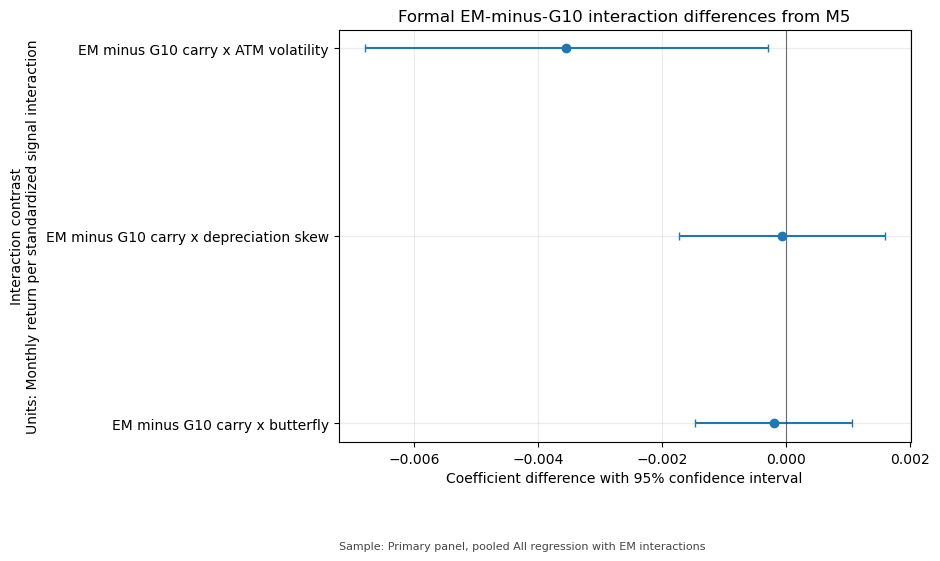

### Formal M5 G10-versus-EM heterogeneity tests

Significance notation:
*** p < 0.01, ** p < 0.05, * p < 0.10.

IID and two-way clustered significance indicators refer to different covariance assumptions and are reported separately.

,estimate_name,estimate,iid_test_statistic,iid_p_value,iid_stars,clustered_test_statistic,clustered_p_value,clustered_stars,clustered_status,clustered_ci_low,clustered_ci_high,n_month_clusters,n_currency_clusters
0,G10 carry x ATM volatility,+0.00277,+2.57,0.010,**,+2.94,0.008,***,available,+0.00079,+0.00474,233,20
1,EM carry x ATM volatility,-0.00078,-0.79,0.429,,-0.81,0.430,,available,-0.00281,+0.00125,233,20
2,EM minus G10 carry x ATM volatility,-0.00355,-2.43,0.015,**,-2.29,0.034,**,available,-0.00680,-0.00030,233,20
3,G10 carry x depreciation skew,+0.00040,+0.39,0.696,,+0.88,0.392,,available,-0.00056,+0.00137,233,20
4,EM carry x depreciation skew,+0.00033,+0.25,0.804,,+0.45,0.659,,available,-0.00122,+0.00189,233,20
5,EM minus G10 carry x depreciation skew,-0.00007,-0.04,0.967,,-0.09,0.930,,available,-0.00173,+0.00159,233,20
6,G10 carry x butterfly,+0.00085,+0.91,0.364,,+1.23,0.235,,available,-0.00060,+0.00229,233,20
7,EM carry x butterfly,+0.00064,+0.59,0.553,,+0.94,0.362,,available,-0.00080,+0.00208,233,20
8,EM minus G10 carry x butterfly,-0.00020,-0.14,0.887,,-0.34,0.740,,available,-0.00147,+0.00106,233,20


In [11]:

heterogeneity_results = pd.DataFrame(); heterogeneity_compact = pd.DataFrame()
if STATSMODELS_AVAILABLE:
    het = add_design_columns(primary_panel, suffix="class")
    het["em_indicator"] = het["asset_class"].eq("EM").astype(float)
    base_terms = MODEL_TERMS[PRIMARY_MODEL]
    for term in base_terms:
        het[f"em_x_{term}"] = het["em_indicator"] * het[term]
    xcols = base_terms + ["em_indicator"] + [f"em_x_{term}" for term in base_terms]
    heterogeneity_results, het_fit, het_used, het_covs = fit_ols_with_inference(het, Y_COL, xcols, "All", "M5 EM heterogeneity", "monthly within-asset-class z-scores")
    heterogeneity_results = add_inference_star_columns(heterogeneity_results)
    iid_res = het_covs.get("iid") if isinstance(het_covs, dict) else None
    iid_meta = het_covs.get("_meta", {}).get("iid", {}) if isinstance(het_covs, dict) else {}
    two_way_res = het_covs.get("two_way_cluster") if isinstance(het_covs, dict) else None
    two_way_meta = het_covs.get("_meta", {}).get("two_way_cluster", {}) if isinstance(het_covs, dict) else {}
    if het_fit is not None:
        names = list(het_fit.model.exog_names)
        def restriction_vector(weights):
            r = np.zeros(len(names))
            for k, v in weights.items():
                if k not in names:
                    raise KeyError(f"Missing coefficient in heterogeneity restriction: {k}")
                r[names.index(k)] = v
            return r
        def run_linear_test(res, R):
            if res is None:
                return {"estimate": np.nan, "se": np.nan, "statistic": np.nan, "p": np.nan, "ci_low": np.nan, "ci_high": np.nan}
            try:
                test = res.t_test(R)
                estimate = finite_or_nan(np.asarray(test.effect).ravel()[0])
                se = finite_or_nan(np.asarray(test.sd).ravel()[0])
                stat = finite_or_nan(np.asarray(test.tvalue).ravel()[0])
                pval = finite_or_nan(np.asarray(test.pvalue).ravel()[0])
                try:
                    ci = np.asarray(test.conf_int(alpha=0.05), dtype=float).reshape(-1, 2)[0]
                    low, high = finite_or_nan(ci[0]), finite_or_nan(ci[1])
                except Exception:
                    low, high = np.nan, np.nan
                return {"estimate": estimate, "se": se, "statistic": stat, "p": pval, "ci_low": low, "ci_high": high}
            except Exception:
                return {"estimate": np.nan, "se": np.nan, "statistic": np.nan, "p": np.nan, "ci_low": np.nan, "ci_high": np.nan}
        def test_combo(label, weights):
            R = restriction_vector(weights)[None, :]
            iid = run_linear_test(iid_res, R)
            clustered_available = two_way_res is not None and two_way_meta.get("valid", False)
            clustered = run_linear_test(two_way_res, R) if clustered_available else {"estimate": np.nan, "se": np.nan, "statistic": np.nan, "p": np.nan, "ci_low": np.nan, "ci_high": np.nan}
            estimate = clustered["estimate"] if np.isfinite(clustered["estimate"]) else iid["estimate"]
            return {
                "estimate_name": label,
                "estimate": estimate,
                "iid_se": iid["se"], "iid_test_statistic": iid["statistic"], "iid_p_value": iid["p"], "iid_stars": significance_stars(iid["p"]), "iid_ci_low": iid["ci_low"], "iid_ci_high": iid["ci_high"],
                "clustered_se": clustered["se"], "clustered_test_statistic": clustered["statistic"], "clustered_p_value": clustered["p"], "clustered_stars": significance_stars(clustered["p"]) if clustered_available else "", "clustered_ci_low": clustered["ci_low"], "clustered_ci_high": clustered["ci_high"],
                "clustered_status": two_way_meta.get("status", "unavailable"),
                "clustered_inference_method": "two-way clustered t_test",
                "iid_inference_method": "ordinary OLS t_test",
                "df_inference": two_way_meta.get("df_inference"), "n_month_clusters": het_used["month_end"].nunique(),
                "n_currency_clusters": het_used["currency"].nunique(), "cluster_warning": cluster_warning(het_used["currency"].nunique()),
                "validity_status": "available" if np.isfinite(iid["p"]) or np.isfinite(clustered["p"]) else "unavailable", "wild_cluster_bootstrap_p": np.nan,
            }
        rows=[]
        for term, label in [("carry_x_atm_vol", "carry x ATM volatility"), ("carry_x_depreciation_skew", "carry x depreciation skew"), ("carry_x_bf25", "carry x butterfly")]:
            rows.append(test_combo(f"G10 {label}", {term: 1.0}))
            rows.append(test_combo(f"EM {label}", {term: 1.0, f"em_x_{term}": 1.0}))
            rows.append(test_combo(f"EM minus G10 {label}", {f"em_x_{term}": 1.0}))
        heterogeneity_compact = pd.DataFrame(rows)
        if two_way_res is None or not two_way_meta.get("valid", False):
            note_skip("heterogeneity clustered tests", f"two-way clustered covariance unavailable: {two_way_meta.get('status')}")
    else:
        note_skip("heterogeneity tests", "model fit unavailable")
else:
    note_skip("heterogeneity tests", "statsmodels unavailable")

wild_cluster_bootstrap_rows.append({"section": "heterogeneity", "status": "wild cluster bootstrap unavailable", "reason": "No wild-cluster bootstrap package is used or installed by this notebook."})

if PLOTTING_AVAILABLE and not heterogeneity_compact.empty and "estimate" in heterogeneity_compact:
    plot_sub = heterogeneity_compact[heterogeneity_compact["estimate_name"].str.contains("EM minus G10", na=False) & heterogeneity_compact["estimate"].notna()].copy().iloc[::-1]
    if not plot_sub.empty:
        lo = np.where(plot_sub["clustered_ci_low"].notna(), plot_sub["clustered_ci_low"], plot_sub["iid_ci_low"])
        hi = np.where(plot_sub["clustered_ci_high"].notna(), plot_sub["clustered_ci_high"], plot_sub["iid_ci_high"])
        fig, ax = plt.subplots(figsize=(9.5, 5.8))
        ax.errorbar(plot_sub["estimate"], plot_sub["estimate_name"], xerr=[plot_sub["estimate"] - lo, hi - plot_sub["estimate"]], fmt="o", capsize=3)
        finalize_axis(ax, "Formal EM-minus-G10 interaction differences from M5", "Coefficient difference with 95% confidence interval", "Interaction contrast", sample_definition="Primary panel, pooled All regression with EM interactions", units="Monthly return per standardized signal interaction", zero_axis="x")
        plt.tight_layout(); savefig(fig, "heterogeneity_m5_em_minus_g10_interactions_v9.png"); plt.show()

successful_sections.append("formal M5 G10-versus-EM heterogeneity tests with separate IID and clustered inference labels")
display(Markdown("### Formal M5 G10-versus-EM heterogeneity tests")); display_significance_legend()
heterogeneity_display_cols = ["estimate_name", "estimate", "iid_test_statistic", "iid_p_value", "iid_stars", "clustered_test_statistic", "clustered_p_value", "clustered_stars", "clustered_status", "clustered_ci_low", "clustered_ci_high", "n_month_clusters", "n_currency_clusters"]
display_df(heterogeneity_compact[[c for c in heterogeneity_display_cols if c in heterogeneity_compact.columns]], {"estimate":"{:+.5f}", "iid_test_statistic":"{:+.2f}", "iid_p_value":format_p_value, "clustered_test_statistic":"{:+.2f}", "clustered_p_value":format_p_value, "clustered_ci_low":"{:+.5f}", "clustered_ci_high":"{:+.5f}"})


## Marginal Effects from M5

The M5 marginal carry effect is:

$$
ME_C(V,D,B)
=
\beta_C+\beta_{CV}V+\beta_{CD}D+\beta_{CB}B.
$$

The plots below use the delta method and the preferred two-way-clustered covariance matrix where available. Shaded regions are 95% confidence intervals. Lines are restricted to observed 5th-95th percentile ranges.

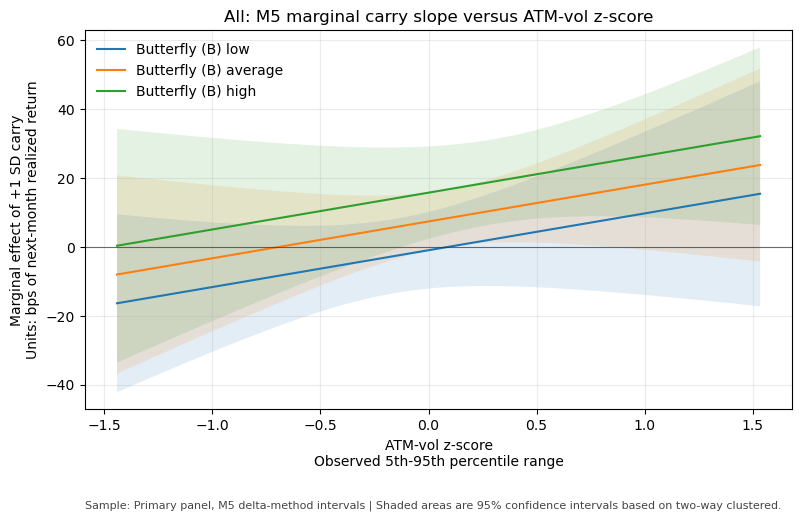

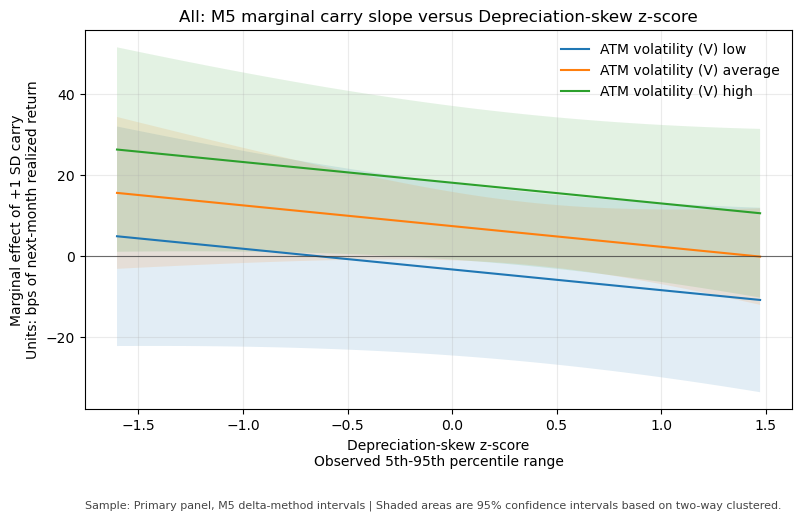

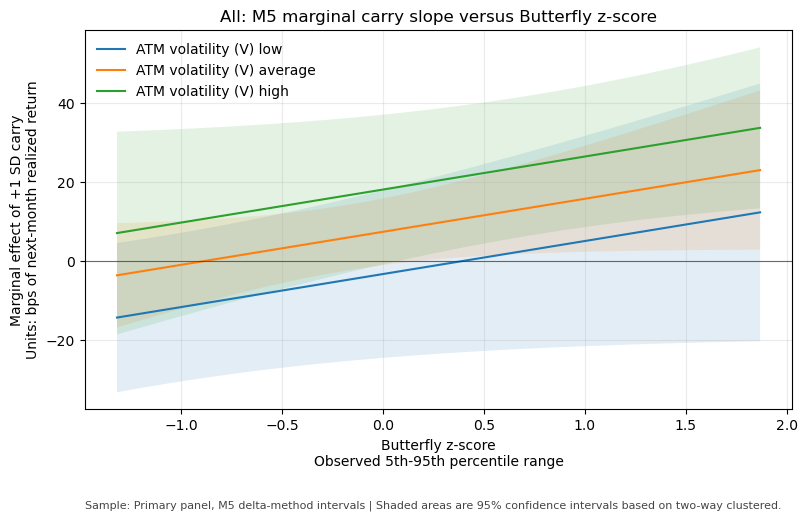

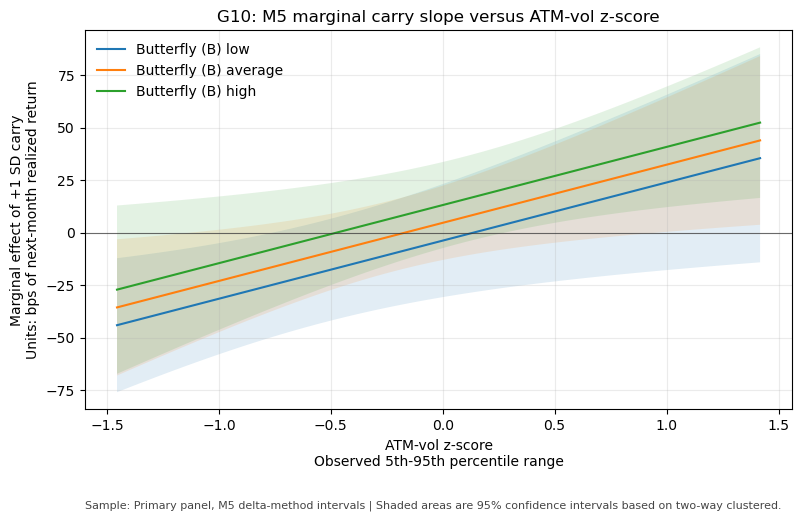

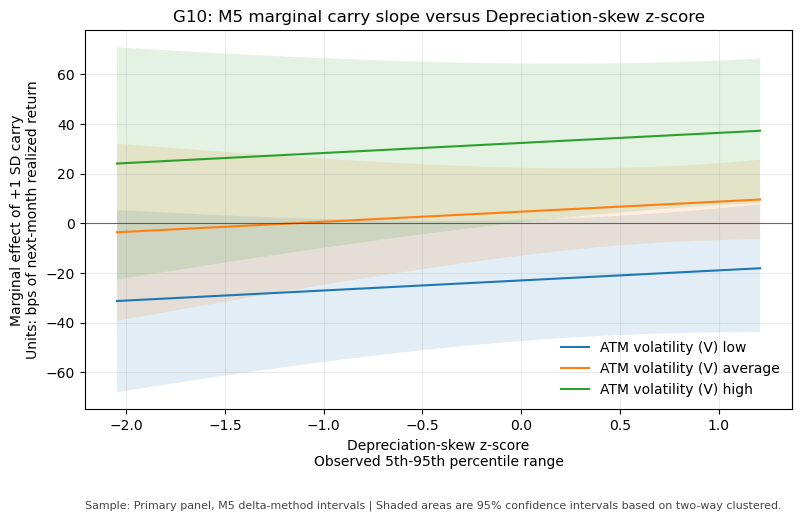

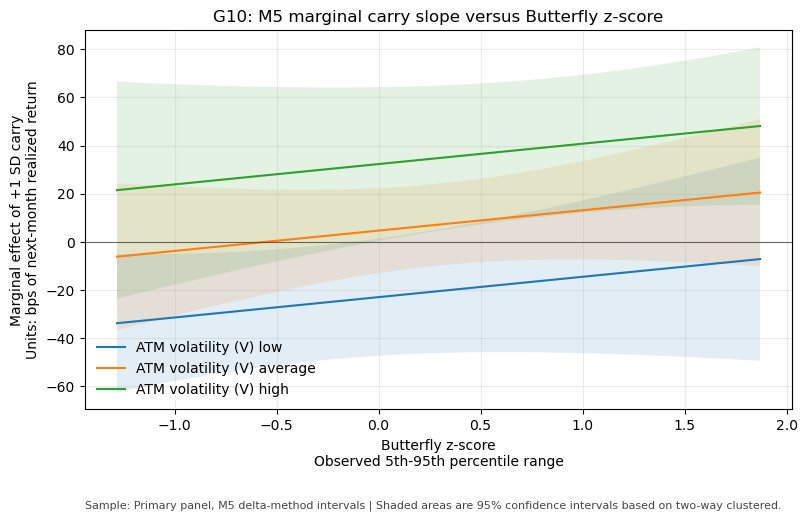

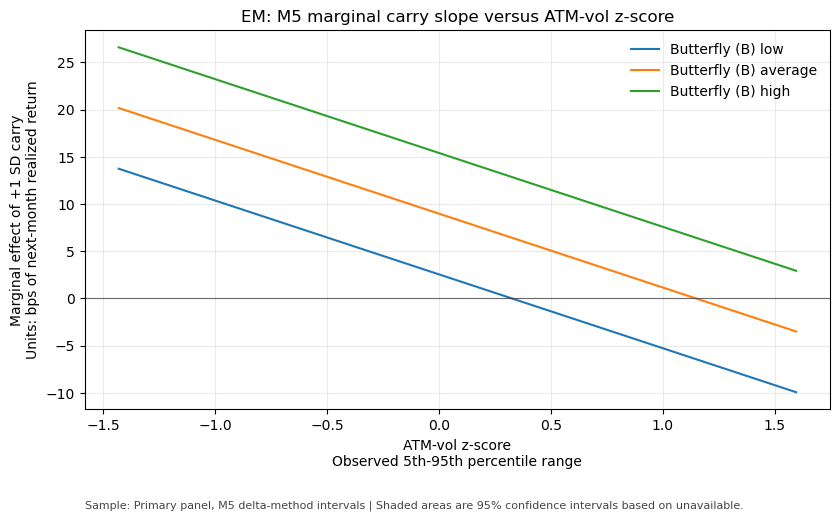

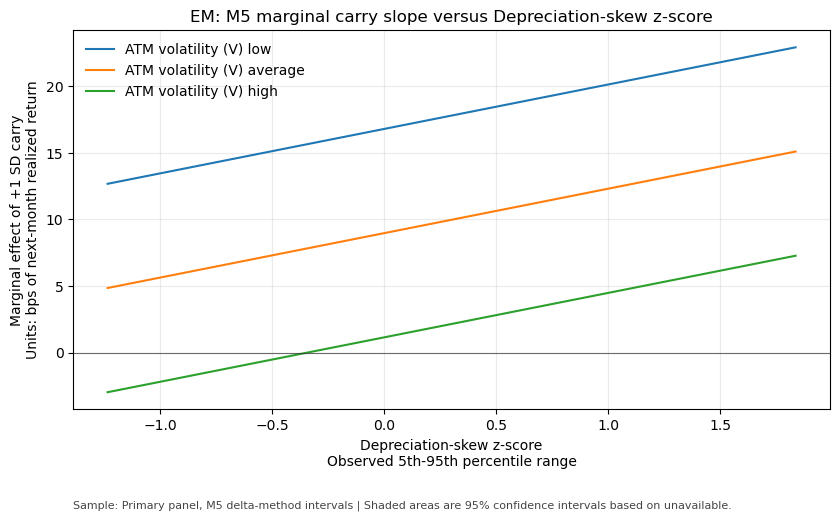

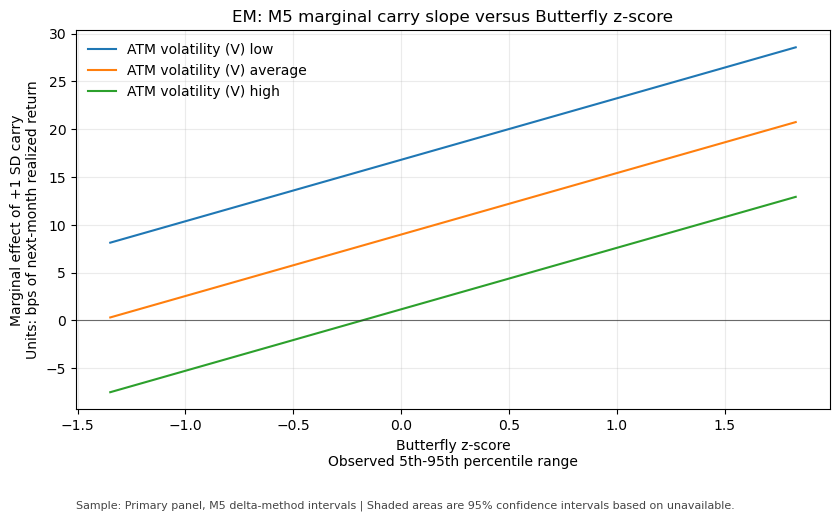

,sample,atm_vol_z,depreciation_skew_z,butterfly_z,marginal_carry_effect,se,ci_low,ci_high,critical_value,df_inference,covariance_type,interval_status,monthly_bps,ci_low_bps,ci_high_bps
0,All,-1,-1,-1,-0.00066,0.00095,-0.002637,0.001324,2.09,19.0,two-way clustered,finite-sample t interval,-6.6,-26.4,+13.2
1,All,-1,-1,0,+0.00018,0.00115,-0.002235,0.002593,2.09,19.0,two-way clustered,finite-sample t interval,+1.8,-22.4,+25.9
2,All,-1,-1,1,+0.00101,0.00146,-0.002043,0.004072,2.09,19.0,two-way clustered,finite-sample t interval,+10.1,-20.4,+40.7
3,All,-1,0,-1,-0.00117,0.00090,-0.003048,0.000713,2.09,19.0,two-way clustered,finite-sample t interval,-11.7,-30.5,+7.1
4,All,-1,0,0,-0.00033,0.00101,-0.002453,0.001789,2.09,19.0,two-way clustered,finite-sample t interval,-3.3,-24.5,+17.9
5,All,-1,0,1,+0.00050,0.00127,-0.002156,0.003164,2.09,19.0,two-way clustered,finite-sample t interval,+5.0,-21.6,+31.6
6,All,-1,1,-1,-0.00168,0.00102,-0.003822,0.000466,2.09,19.0,two-way clustered,finite-sample t interval,-16.8,-38.2,+4.7
7,All,-1,1,0,-0.00084,0.00103,-0.002990,0.001306,2.09,19.0,two-way clustered,finite-sample t interval,-8.4,-29.9,+13.1
8,All,-1,1,1,-0.00001,0.00119,-0.002506,0.002493,2.09,19.0,two-way clustered,finite-sample t interval,-0.1,-25.1,+24.9
9,All,-1,2,-1,-0.00219,0.00127,-0.004853,0.000476,2.09,19.0,two-way clustered,finite-sample t interval,-21.9,-48.5,+4.8


In [12]:

def get_valid_m5_cov(sample):
    key = (sample, "monthly within-asset-class z-scores", PRIMARY_MODEL)
    fit = fitted_models.get(key)
    used = fitted_data.get(key, pd.DataFrame())
    covs = fitted_covs.get(key, {})
    if fit is None or used.empty:
        return None, used, None, {"valid": False, "status": "model unavailable"}
    two = covs.get("two_way_cluster") if isinstance(covs, dict) else None
    meta = covs.get("_meta", {}).get("two_way_cluster", {}) if isinstance(covs, dict) else {}
    if two is not None and meta.get("valid", False):
        return fit, used, two, {**meta, "covariance_type": "two-way clustered"}
    return fit, used, None, {**meta, "valid": False, "covariance_type": "unavailable"}


def marginal_effect_estimate(sample, V=0.0, D=0.0, B=0.0):
    fit, used, cov_res, meta = get_valid_m5_cov(sample)
    if fit is None:
        return None
    names = list(fit.model.exog_names)
    required = ["carry", "carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]
    missing = [x for x in required if x not in names]
    if missing:
        raise KeyError(f"M5 fit missing marginal-effect coefficients: {missing}")
    params = pd.Series(np.asarray(fit.params), index=names)
    weights = {"carry": 1.0, "carry_x_atm_vol": V, "carry_x_depreciation_skew": D, "carry_x_bf25": B}
    est = float(sum(weights[k] * params[k] for k in weights))
    if cov_res is None or not meta.get("valid", False):
        return {"marginal_carry_effect": est, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "critical_value": np.nan, "df_inference": meta.get("df_inference", np.nan), "covariance_type": meta.get("covariance_type"), "interval_status": meta.get("status", "unavailable")}
    cov = np.asarray(cov_res.cov_params(), dtype=float)
    idx = [names.index(k) for k in weights]
    subcov = cov[np.ix_(idx, idx)]
    if not np.all(np.isfinite(subcov)) or np.any(np.diag(subcov) < -1e-14):
        return {"marginal_carry_effect": est, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "critical_value": np.nan, "df_inference": meta.get("df_inference", np.nan), "covariance_type": meta.get("covariance_type"), "interval_status": "invalid covariance"}
    w = np.array([weights[k] for k in weights], dtype=float)
    var = float(w @ subcov @ w)
    if not np.isfinite(var) or var < -1e-14:
        return {"marginal_carry_effect": est, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "critical_value": np.nan, "df_inference": meta.get("df_inference", np.nan), "covariance_type": meta.get("covariance_type"), "interval_status": "invalid delta-method variance"}
    se = math.sqrt(max(var, 0.0))
    df_inf = meta.get("df_inference", np.nan)
    if SCIPY_AVAILABLE and np.isfinite(df_inf) and df_inf > 0:
        crit = float(scipy_stats.t.ppf(0.975, df=df_inf))
        interval_status = "finite-sample t interval"
    else:
        crit = 1.959963984540054
        interval_status = "normal-approximation interval"
    return {"marginal_carry_effect": est, "se": se, "ci_low": est - crit * se, "ci_high": est + crit * se, "critical_value": crit, "df_inference": df_inf, "covariance_type": meta.get("covariance_type"), "interval_status": interval_status}

def m5_marginal_rows(sample):
    rows=[]
    for V in [-1, 0, 1]:
        for D in [-1, 0, 1, 2]:
            for B in [-1, 0, 1]:
                out = marginal_effect_estimate(sample, V=V, D=D, B=B)
                if out is None:
                    continue
                rows.append({"sample": sample, "atm_vol_z": V, "depreciation_skew_z": D, "butterfly_z": B, **out, "monthly_bps": out["marginal_carry_effect"]*10000, "ci_low_bps": out["ci_low"]*10000 if np.isfinite(out["ci_low"]) else np.nan, "ci_high_bps": out["ci_high"]*10000 if np.isfinite(out["ci_high"]) else np.nan})
    return pd.DataFrame(rows)

marginal_effects = pd.concat([m5_marginal_rows(s) for s in ["All", "G10", "EM"]], ignore_index=True)

def marginal_curve(sample, xvar, line_var, filename):
    fit, used, cov_res, meta = get_valid_m5_cov(sample)
    if fit is None or used.empty or not PLOTTING_AVAILABLE:
        return
    lo, hi = used[xvar].quantile([0.05, 0.95])
    xs = np.linspace(lo, hi, 80)
    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    for level, lab in [(-1, "low"), (0, "average"), (1, "high")]:
        vals=[]; lows=[]; highs=[]
        for x in xs:
            V = D = B = 0.0
            if xvar == "atm_vol": V = x
            if xvar == "depreciation_skew": D = x
            if xvar == "bf25": B = x
            if line_var == "atm_vol": V = level
            if line_var == "depreciation_skew": D = level
            if line_var == "bf25": B = level
            out = marginal_effect_estimate(sample, V=V, D=D, B=B)
            vals.append(out["marginal_carry_effect"] * 10000)
            lows.append(out["ci_low"] * 10000 if np.isfinite(out["ci_low"]) else np.nan)
            highs.append(out["ci_high"] * 10000 if np.isfinite(out["ci_high"]) else np.nan)
        ax.plot(xs, vals, label=f"{TERM_DISPLAY.get(line_var, line_var)} {lab}")
        if np.isfinite(lows).any() and np.isfinite(highs).any():
            ax.fill_between(xs, lows, highs, alpha=0.13)
    xlabel_map = {"atm_vol": "ATM-vol z-score", "depreciation_skew": "Depreciation-skew z-score", "bf25": "Butterfly z-score"}
    note = f"Shaded areas are 95% confidence intervals based on {meta.get('covariance_type', 'unavailable covariance')}."
    finalize_axis(ax, f"{sample}: M5 marginal carry slope versus {xlabel_map[xvar]}", f"{xlabel_map[xvar]}\nObserved 5th-95th percentile range", "Marginal effect of +1 SD carry", sample_definition="Primary panel, M5 delta-method intervals", units="bps of next-month realized return", note=note, zero_axis="y")
    ax.legend(frameon=False)
    plt.tight_layout(); savefig(fig, filename); plt.show()

for sample in ["All", "G10", "EM"]:
    marginal_curve(sample, "atm_vol", line_var="bf25", filename=f"marginal_m5_{sample}_carry_slope_vs_atm_vol_v9.png")
    marginal_curve(sample, "depreciation_skew", line_var="atm_vol", filename=f"marginal_m5_{sample}_carry_slope_vs_depreciation_skew_v9.png")
    marginal_curve(sample, "bf25", line_var="atm_vol", filename=f"marginal_m5_{sample}_carry_slope_vs_butterfly_v9.png")

successful_sections.append("M5 marginal effects with valid covariance-aware delta-method intervals")
display_df(marginal_effects, {"marginal_carry_effect":"{:+.5f}", "monthly_bps":"{:+.1f}", "se":"{:.5f}", "ci_low_bps":"{:+.1f}", "ci_high_bps":"{:+.1f}", "critical_value":"{:.2f}", "df_inference":"{:.1f}"})


## Mean-Return and Risk-Outcome Analysis

The same four primary signals and the M5 structure are used for mean return, future return magnitude, negative-return probability, severe-loss probability, and lower-tail quantile regressions. The severe-loss threshold is the predeclared 10th percentile of realized returns in the relevant estimation sample.

In [13]:

risk_parts=[]
risk_panel = add_design_columns(primary_panel, suffix="class")
risk_panel["negative_return_probability"] = indicator_preserve_missing(risk_panel[Y_COL], lambda x: x < 0)

valid_returns = risk_panel[Y_COL].dropna()
q_full_10 = valid_returns.quantile(0.10)
risk_panel["severe_loss_full_sample"] = indicator_preserve_missing(risk_panel[Y_COL], lambda x: x <= q_full_10)
risk_panel["severe_loss_within_asset_class"] = np.nan
loss_threshold_rows = [{
    "definition": "severe_loss_full_sample", "sample_or_asset_class": "All", "valid_return_count": int(valid_returns.shape[0]),
    "missing_return_count": int(risk_panel[Y_COL].isna().sum()), "threshold": q_full_10,
    "number_of_losses": int(risk_panel["severe_loss_full_sample"].sum(skipna=True)),
    "realized_loss_rate": float(risk_panel["severe_loss_full_sample"].mean(skipna=True)),
}]
for asset_class, sub in risk_panel.groupby("asset_class", sort=True):
    class_valid = sub[Y_COL].dropna()
    q_class = class_valid.quantile(0.10)
    idx = sub.index
    risk_panel.loc[idx, "severe_loss_within_asset_class"] = indicator_preserve_missing(risk_panel.loc[idx, Y_COL], lambda x, q=q_class: x <= q)
    loss_threshold_rows.append({
        "definition": "severe_loss_within_asset_class", "sample_or_asset_class": asset_class,
        "valid_return_count": int(class_valid.shape[0]), "missing_return_count": int(sub[Y_COL].isna().sum()),
        "threshold": q_class, "number_of_losses": int(risk_panel.loc[idx, "severe_loss_within_asset_class"].sum(skipna=True)),
        "realized_loss_rate": float(risk_panel.loc[idx, "severe_loss_within_asset_class"].mean(skipna=True)),
    })
loss_threshold_audit = pd.DataFrame(loss_threshold_rows)
loss_threshold_audit["loss_rate_near_10pct"] = loss_threshold_audit["realized_loss_rate"].between(0.08, 0.12)
assert risk_panel.loc[risk_panel[Y_COL].isna(), "negative_return_probability"].isna().all()
assert risk_panel.loc[risk_panel[Y_COL].isna(), "severe_loss_full_sample"].isna().all()
assert risk_panel.loc[risk_panel[Y_COL].isna(), "severe_loss_within_asset_class"].isna().all()

risk_outcomes = [
    ("realized_return_1m", "Mean realized return"),
    ("abs_realized_return_1m", "Absolute return"),
    ("squared_realized_return_1m", "Squared return"),
    ("negative_return_probability", "Negative-return probability"),
    ("severe_loss_within_asset_class", "Severe-loss probability within asset class"),
    ("severe_loss_full_sample", "Severe-loss probability full sample"),
]
risk_sample_count_rows=[]
for ycol, label in risk_outcomes:
    for sample in ["All", "G10", "EM"]:
        sub = get_sample(risk_panel, sample)
        xcols = MODEL_TERMS[PRIMARY_MODEL]
        n_input = len(sub)
        n_missing_y = int(sub[ycol].isna().sum())
        n_missing_x = int(sub[xcols].isna().any(axis=1).sum())
        n_complete = int(sub.dropna(subset=[ycol] + xcols).shape[0])
        risk_sample_count_rows.append({"sample": sample, "outcome": ycol, "outcome_label": label, "n_input_rows": n_input, "n_complete_case_rows": n_complete, "n_dropped_missing_outcome": n_missing_y, "n_dropped_missing_regressor": n_missing_x})
        res, fit, used, covs = fit_ols_with_inference(sub, ycol, xcols, sample, f"M5 {label}", "monthly within-asset-class z-scores", min_obs=60)
        if not res.empty:
            risk_parts.append(res.assign(outcome_label=label, outcome=ycol, inference_method="IID OLS and two-way clustered when valid"))
risk_sample_count_validation = pd.DataFrame(risk_sample_count_rows)
for outcome in ["negative_return_probability", "severe_loss_within_asset_class", "severe_loss_full_sample"]:
    merged = risk_panel[[Y_COL, outcome]]
    assert merged.loc[merged[Y_COL].isna(), outcome].isna().all()

if STATSMODELS_AVAILABLE:
    for q in [0.10, 0.25]:
        for sample in ["All", "G10", "EM"]:
            sub = get_sample(risk_panel, sample).dropna(subset=[Y_COL] + MODEL_TERMS[PRIMARY_MODEL]).copy()
            if len(sub) < 80:
                note_skip(f"quantile regression {sample} q={q}", "insufficient observations")
                continue
            try:
                X = numeric_design(sub, MODEL_TERMS[PRIMARY_MODEL])
                fit = sm.QuantReg(sub[Y_COL], X).fit(q=q, max_iter=4000)
                rows=[]
                for name in ["const"] + MODEL_TERMS[PRIMARY_MODEL]:
                    iid_p = fit.pvalues.get(name, np.nan)
                    rows.append({
                        "sample": sample, "model": f"M5 lower-tail quantile q={q:.2f}", "specification": "monthly within-asset-class z-scores", "fixed_effects": "none", "variable": name, "variable_label": TERM_DISPLAY.get(name, name),
                        "coefficient": fit.params.get(name, np.nan), "iid_se": fit.bse.get(name, np.nan), "iid_t": fit.tvalues.get(name, np.nan), "iid_p": iid_p, "iid_stars": significance_stars(iid_p),
                        "two_way_cluster_se": np.nan, "two_way_cluster_t": np.nan, "two_way_cluster_p": np.nan, "two_way_cluster_stars": "", "two_way_cluster_status": "Two-way clustered inference not calculated for quantile regression",
                        "preferred_inference_method": "two-way clustered unavailable", "preferred_inference_available": False,
                        "wild_cluster_bootstrap_p": np.nan, "wild_cluster_bootstrap_reps": 0, "wild_cluster_bootstrap_valid_reps": 0, "wild_cluster_bootstrap_status": WILD_CLUSTER_BOOTSTRAP_STATUS,
                        "observations": len(sub), "currencies": sub["currency"].nunique(), "months": sub["month_end"].nunique(),
                        "n_month_clusters": sub["month_end"].nunique(), "n_currency_clusters": sub["currency"].nunique(), "min_cluster_dimension": min(sub["month_end"].nunique(), sub["currency"].nunique()),
                        "r_squared": np.nan, "adj_r_squared": np.nan, "outcome_label": "Lower-tail quantile", "outcome": f"quantile_{q:.2f}",
                        "inference_method": "quantile-regression asymptotic IID",
                    })
                risk_parts.append(pd.DataFrame(rows))
            except Exception as exc:
                note_skip(f"quantile regression {sample} q={q}", repr(exc))

risk_outcome_results = pd.concat(risk_parts, ignore_index=True, sort=False) if risk_parts else pd.DataFrame()
risk_outcome_results = add_inference_star_columns(risk_outcome_results)

signal_pairs = [("ATM vol", "atm_vol", "carry_x_atm_vol"), ("Depreciation skew", "depreciation_skew", "carry_x_depreciation_skew"), ("Butterfly", "bf25", "carry_x_bf25")]
risk_matrix_rows=[]
for outcome, label in [(o, l) for o, l in risk_outcomes] + [("quantile_0.10", "Lower-tail quantile 10%"), ("quantile_0.25", "Lower-tail quantile 25%")]:
    for signal_label, main_var, interaction_var in signal_pairs:
        sub = risk_outcome_results[(risk_outcome_results["sample"].eq("All")) & (risk_outcome_results["outcome"].eq(outcome))]
        main = sub[sub["variable"].eq(main_var)]
        inter = sub[sub["variable"].eq(interaction_var)]
        def pull(row, field):
            return row.iloc[0].get(field, np.nan) if not row.empty else np.nan
        risk_matrix_rows.append({
            "Outcome": label, "Signal": signal_label,
            "Main-effect coefficient": pull(main, "coefficient"),
            "Main-effect IID p": pull(main, "iid_p"), "Main-effect IID sig.": pull(main, "iid_stars"),
            "Main-effect two-way p": pull(main, "two_way_cluster_p"), "Main-effect two-way sig.": pull(main, "two_way_cluster_stars"), "Main-effect two-way status": pull(main, "two_way_cluster_status"),
            "Carry-interaction coefficient": pull(inter, "coefficient"),
            "Interaction IID p": pull(inter, "iid_p"), "Interaction IID sig.": pull(inter, "iid_stars"),
            "Interaction two-way p": pull(inter, "two_way_cluster_p"), "Interaction two-way sig.": pull(inter, "two_way_cluster_stars"), "Interaction two-way status": pull(inter, "two_way_cluster_status"),
        })
risk_comparison_matrix = pd.DataFrame(risk_matrix_rows)

successful_sections.append("M5 mean-return, future-risk, missing-preserving binary outcomes, separate severe-loss definitions, lower-tail, and corrected sample-count diagnostics")
display(Markdown("### Severe-loss threshold audit")); display_df(loss_threshold_audit, {"threshold":"{:+.5f}", "realized_loss_rate":"{:.1%}"})
display(Markdown("### Risk outcome sample-count validation")); display_df(risk_sample_count_validation)
display(Markdown("### Risk-outcome comparison matrix with main effects separated from carry interactions")); display_significance_legend(); display_df(risk_comparison_matrix, {"Main-effect coefficient":"{:+.5f}", "Main-effect IID p":format_p_value, "Main-effect two-way p":format_p_value, "Carry-interaction coefficient":"{:+.5f}", "Interaction IID p":format_p_value, "Interaction two-way p":format_p_value})
display(Markdown("Quantile-regression p-values use the model's asymptotic non-clustered covariance and should be treated as exploratory. Two-way clustered inference not calculated for quantile regression is shown explicitly as unavailable."))
display(Markdown("### Risk-outcome coefficient preview")); display_regression_table(risk_outcome_results[risk_outcome_results["variable"].isin(MODEL_TERMS[PRIMARY_MODEL])].head(80), fmt_reg)


Skipped preferred two-way inference EM M5 Mean realized return monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M5 Absolute return monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M5 Squared return monthly within-asset-class z-scores: invalid covariance diagonal


### Severe-loss threshold audit

,definition,sample_or_asset_class,valid_return_count,missing_return_count,threshold,number_of_losses,realized_loss_rate,loss_rate_near_10pct
0,severe_loss_full_sample,All,4658,22,-0.03757,466,10.0%,True
1,severe_loss_within_asset_class,EM,2561,13,-0.03818,257,10.0%,True
2,severe_loss_within_asset_class,G10,2097,9,-0.03694,210,10.0%,True


### Risk outcome sample-count validation

,sample,outcome,outcome_label,n_input_rows,n_complete_case_rows,n_dropped_missing_outcome,n_dropped_missing_regressor
0,All,realized_return_1m,Mean realized return,4680,4658,22,1
1,G10,realized_return_1m,Mean realized return,2106,2097,9,0
2,EM,realized_return_1m,Mean realized return,2574,2561,13,1
3,All,abs_realized_return_1m,Absolute return,4680,4658,22,1
4,G10,abs_realized_return_1m,Absolute return,2106,2097,9,0
5,EM,abs_realized_return_1m,Absolute return,2574,2561,13,1
6,All,squared_realized_return_1m,Squared return,4680,4658,22,1
7,G10,squared_realized_return_1m,Squared return,2106,2097,9,0
8,EM,squared_realized_return_1m,Squared return,2574,2561,13,1
9,All,negative_return_probability,Negative-return probability,4680,4658,22,1


...

Significance notation:
*** p < 0.01, ** p < 0.05, * p < 0.10.

IID and two-way clustered significance indicators refer to different covariance assumptions and are reported separately.

,Outcome,Signal,Main-effect coefficient,Main-effect IID p,Main-effect IID sig.,Main-effect two-way p,Main-effect two-way sig.,Main-effect two-way status,Carry-interaction coefficient,Interaction IID p,Interaction IID sig.,Interaction two-way p,Interaction two-way sig.,Interaction two-way status
0,Mean realized return,ATM vol,+0.00081,0.249,,0.080,*,available,+0.00107,0.118,,0.235,,available
1,Mean realized return,Depreciation skew,-0.00082,0.352,,0.015,**,available,-0.00051,0.417,,0.224,,available
2,Mean realized return,Butterfly,-0.00044,0.532,,0.360,,available,+0.00084,0.148,,0.067,*,available
3,Absolute return,ATM vol,+0.00516,<0.001,***,<0.001,***,available,+0.00049,0.282,,0.590,,available
4,Absolute return,Depreciation skew,+0.00095,0.108,,0.220,,available,-0.00028,0.498,,0.504,,available
5,Absolute return,Butterfly,+0.00099,0.034,**,0.083,*,available,-0.00028,0.463,,0.588,,available
6,Squared return,ATM vol,+0.00039,<0.001,***,<0.001,***,available,+0.00012,0.039,**,0.373,,available
7,Squared return,Depreciation skew,+0.00012,0.128,,0.172,,available,+0.00001,0.864,,0.822,,available
8,Squared return,Butterfly,+0.00014,0.026,**,0.023,**,available,+0.00001,0.820,,0.858,,available
9,Negative-return probability,ATM vol,-0.01032,0.337,,0.316,,available,+0.00433,0.677,,0.787,,available


Quantile-regression p-values use the model's asymptotic non-clustered covariance and should be treated as exploratory. Two-way clustered inference not calculated for quantile regression is shown explicitly as unavailable.

### Risk-outcome coefficient preview

,Sample,model,specification,fixed_effects,variable,Variable,Coefficient,Observations,Currencies,Months,n_month_clusters,n_currency_clusters,min_cluster_dimension,small_cluster_warning,r_squared,Adjusted R²,aic,bic,preferred_inference,preferred_inference_status,preferred_inference_warning,preferred_inference_method,preferred_inference_available,wild_cluster_bootstrap_p,wild_cluster_bootstrap_reps,wild_cluster_bootstrap_valid_reps,wild_cluster_bootstrap_status,iid_status,iid_warning,iid_df_inference,iid_se,iid_t,IID p,hc3_status,hc3_warning,hc3_df_inference,hc3_se,hc3_t,HC3 p,month_cluster_status,month_cluster_warning,month_cluster_df_inference,month_cluster_se,month_cluster_t,Month-cluster p,currency_cluster_status,currency_cluster_warning,currency_cluster_df_inference,currency_cluster_se,currency_cluster_t,Currency-cluster p,Two-way status,two_way_cluster_warning,two_way_cluster_df_inference,Two-way SE,Two-way t,Two-way p,IID sig.,HC3 sig.,Month-cluster sig.,Currency-cluster sig.,Two-way sig.,Two-way CI low,Two-way CI high,two_way_ci_method,two_way_df_inference,two_way_critical_value,outcome_label,outcome,inference_method
1,All,M5 Mean realized return,monthly within-asset-class z-scores,none,carry,Carry signal (C),+0.00074,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.002645,+0.0011,-18603.284868,-18551.714137,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4650.000000,0.00075,+0.98,0.326,available,,4650.000000,0.000802,0.918970,0.358,available,,232.000000,0.000644,1.144444,0.254,available,,19.000000,0.000623,1.184517,0.251,available,,19.000000,0.00040,+1.83,0.083,,,,,*,-0.00011,+0.00158,robust_result.conf_int,19.000000,—,Mean realized return,realized_return_1m,IID OLS and two-way clustered when valid
2,All,M5 Mean realized return,monthly within-asset-class z-scores,none,atm_vol,ATM volatility (V),+0.00081,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.002645,+0.0011,-18603.284868,-18551.714137,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4650.000000,0.00071,+1.15,0.249,available,,4650.000000,0.000710,1.147806,0.251,available,,232.000000,0.000639,1.275257,0.203,available,,19.000000,0.000537,1.517446,0.146,available,,19.000000,0.00044,+1.85,0.080,,,,,*,-0.00011,+0.00174,robust_result.conf_int,19.000000,—,Mean realized return,realized_return_1m,IID OLS and two-way clustered when valid
3,All,M5 Mean realized return,monthly within-asset-class z-scores,none,depreciation_skew,Depreciation skew (D),-0.00082,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.002645,+0.0011,-18603.284868,-18551.714137,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4650.000000,0.00088,-0.93,0.352,available,,4650.000000,0.000923,-0.891512,0.373,available,,232.000000,0.000745,-1.104863,0.270,available,,19.000000,0.000622,-1.323084,0.202,available,,19.000000,0.00031,-2.68,0.015,,,,,**,-0.00147,-0.00018,robust_result.conf_int,19.000000,—,Mean realized return,realized_return_1m,IID OLS and two-way clustered when valid
4,All,M5 Mean realized return,monthly within-asset-class z-scores,none,bf25,Butterfly (B),-0.00044,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.002645,+0.0011,-18603.284868,-18551.714137,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted

## Specification Bridge: Why Did the Earlier Depreciation-Skew Result Change?

This bridge tracks the `carry_x_depreciation_skew` coefficient through predefined changes in scaling, inference, additional controls, and universe definition. Changing clustering alone changes inference, not the OLS point estimate for an otherwise identical specification. Standardization changes both scale and the economic variation used for identification. Adding correlated interactions can reallocate explanatory content. Universe changes can alter monthly cross-sectional transformations.

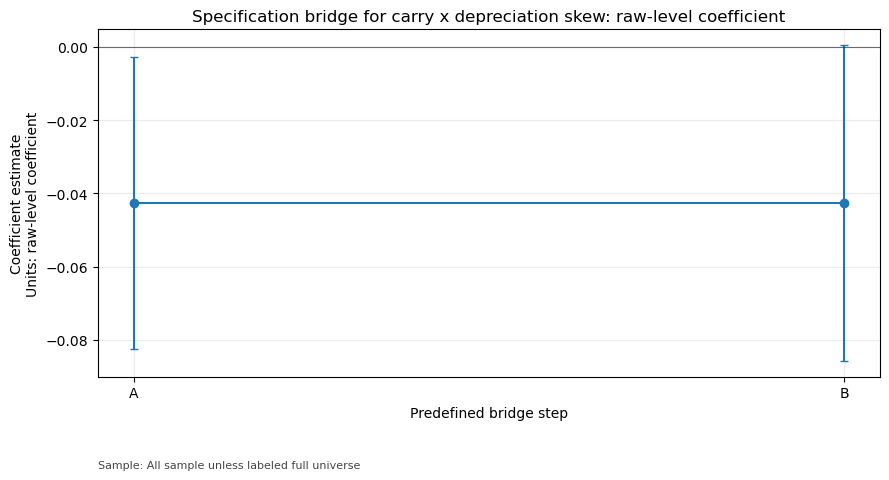

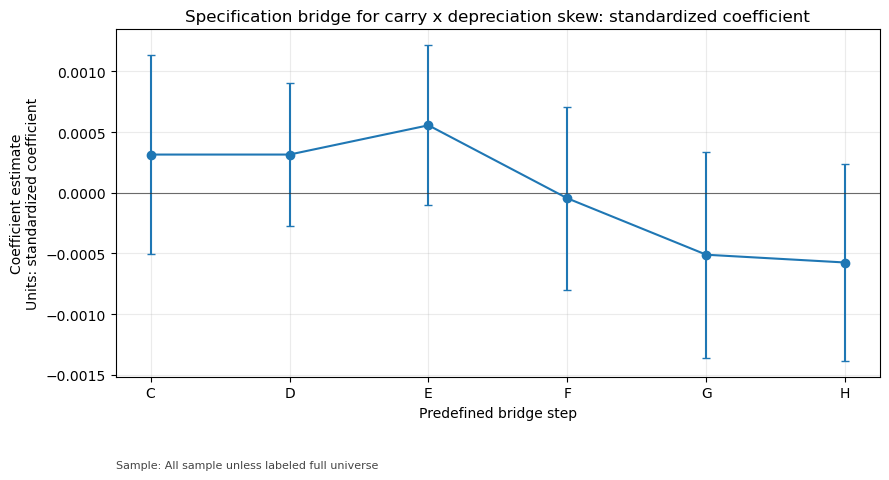

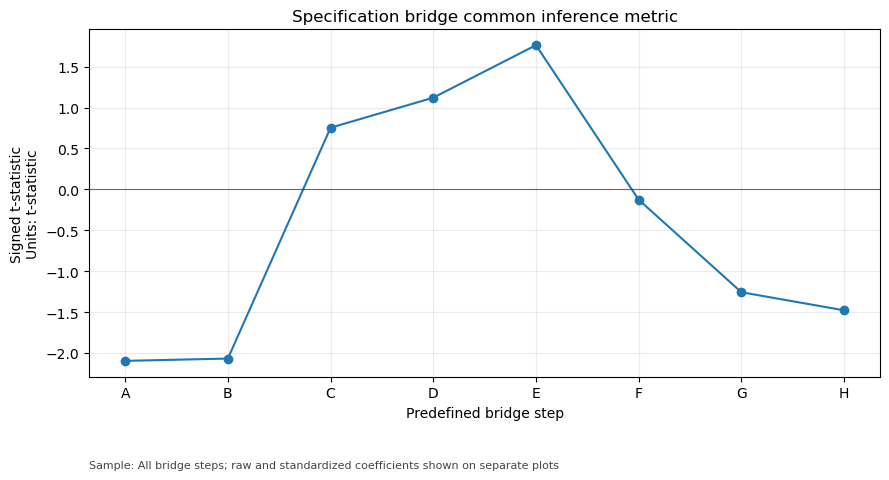

Bridge stars correspond to `bridge_inference_method`; IID and two-way clustered stars remain separate columns.

Significance notation:
*** p < 0.01, ** p < 0.05, * p < 0.10.

IID and two-way clustered significance indicators refer to different covariance assumptions and are reported separately.

,step,sample,scaling,bridge_scale_panel,model,inference,bridge_inference_method,included_regressors,universe_note,coefficient,economic_effect_1sd,iid_p,iid_stars,two_way_cluster_p,two_way_cluster_stars,two_way_cluster_status,bridge_se,bridge_t,bridge_p,bridge_stars,bridge_ci_low,bridge_ci_high,bridge_ci_method,observations,currencies,months
0,A,All,raw,raw-level coefficient,Bridge A,IID,IID OLS,"carry, atm_vol, depreciation_skew, carry_x_depreciation_skew",primary panel,-0.04263,-0.00036,0.036,**,0.052,*,available,0.02033,-2.10,0.036,**,-0.08250,-0.00277,IID finite-sample t interval,4658,20,233
1,B,All,raw,raw-level coefficient,Bridge B,Two-way cluster,Two-way clustered,"carry, atm_vol, depreciation_skew, carry_x_depreciation_skew",primary panel,-0.04263,-0.00036,0.036,**,0.052,*,available,0.02061,-2.07,0.052,*,-0.08577,+0.00051,robust_result.conf_int,4658,20,233
2,C,All,monthly within-asset-class z-scores,standardized coefficient,Bridge C,IID,IID OLS,"carry, atm_vol, depreciation_skew, carry_x_depreciation_skew",primary panel,+0.00032,+0.00032,0.451,,0.276,,available,0.00042,+0.75,0.451,,-0.00050,+0.00114,IID finite-sample t interval,4658,20,233
3,D,All,monthly within-asset-class z-scores,standardized coefficient,Bridge D,Two-way cluster,Two-way clustered,"carry, atm_vol, depreciation_skew, carry_x_depreciation_skew",primary panel,+0.00032,+0.00032,0.451,,0.276,,available,0.00028,+1.12,0.276,,-0.00027,+0.00090,robust_result.conf_int,4658,20,233
4,E,All,monthly within-asset-class z-scores,standardized coefficient,Bridge E,Two-way cluster,Two-way clustered,"carry, atm_vol, depreciation_skew, bf25, carry_x_depreciation_skew",primary panel,+0.00056,+0.00056,0.230,,0.094,*,available,0.00032,+1.76,0.094,*,-0.00010,+0.00122,robust_result.conf_int,4658,20,233
5,F,All,monthly within-asset-class z-scores,standardized coefficient,Bridge F,Two-way cluster,Two-way clustered,"carry, atm_vol, depreciation_skew, bf25, carry_x_atm_vol, carry_x_depreciation_skew",primary panel,-0.00005,-0.00005,0.933,,0.901,,available,0.00036,-0.13,0.901,,-0.00080,+0.00071,robust_result.conf_int,4658,20,233
6,G,All,monthly within-asset-class z-scores,standardized coefficient,Bridge G,Two-way cluster,Two-way clustered,"carry, atm_vol, depreciation_skew, bf25, carry_x_atm_vol, carry_x_depreciation_skew, carry_x_bf25",primary panel,-0.00051,-0.00051,0.417,,0.224,,available,0.00041,-1.26,0.224,,-0.00136,+0.00034,robust_result.conf_int,4658,20,233
7,H,All,monthly within-asset-class z-scores,standardized coefficient,Bridge H,Two-way cluster,Two-way clustered,"carry, atm_vol, depreciation_skew, bf25, carry_x_atm_vol, carry_x_depreciation_skew, carry_x_bf25",full universe robustness,-0.00057,-0.00057,0.344,,0.155,,available,0.00039,-1.48,0.155,,-0.00139,+0.00024,robust_result.conf_int,4840,21,233


In [14]:

def bridge_fit(step, df, sample, scaling, xcols, design_kwargs, inference, universe_note):
    design = add_design_columns(get_sample(df, sample), **design_kwargs)
    res, fit, used, covs = fit_ols_with_inference(design, Y_COL, xcols, sample, f"Bridge {step}", scaling, min_obs=60)
    if res.empty:
        return pd.DataFrame()
    row = res[res["variable"].eq("carry_x_depreciation_skew")].copy()
    if row.empty:
        return pd.DataFrame()
    if inference == "IID":
        row["bridge_se"] = row["iid_se"]; row["bridge_t"] = row["iid_t"]; row["bridge_p"] = row["iid_p"]
        row["bridge_inference_method"] = "IID OLS"
        row["bridge_ci_low"] = row["coefficient"] - (row["iid_se"] * (scipy_stats.t.ppf(0.975, df=max(row["observations"].iloc[0] - len(xcols) - 1, 1)) if SCIPY_AVAILABLE else 1.959963984540054))
        row["bridge_ci_high"] = row["coefficient"] + (row["iid_se"] * (scipy_stats.t.ppf(0.975, df=max(row["observations"].iloc[0] - len(xcols) - 1, 1)) if SCIPY_AVAILABLE else 1.959963984540054))
        row["bridge_ci_method"] = "IID finite-sample t interval"
    else:
        row["bridge_se"] = row["two_way_cluster_se"]; row["bridge_t"] = row["two_way_cluster_t"]; row["bridge_p"] = row["two_way_cluster_p"]
        row["bridge_inference_method"] = "Two-way clustered"
        row["bridge_ci_low"] = row["two_way_ci_low"]; row["bridge_ci_high"] = row["two_way_ci_high"]; row["bridge_ci_method"] = row["two_way_ci_method"]
    row = add_inference_star_columns(row)
    row["bridge_stars"] = row["bridge_p"].apply(significance_stars)
    row["step"] = step; row["scaling"] = scaling; row["inference"] = inference; row["included_regressors"] = ", ".join(xcols); row["universe_note"] = universe_note
    row["bridge_scale_panel"] = np.where(row["scaling"].str.contains("raw", case=False, na=False), "raw-level coefficient", "standardized coefficient")
    raw_design = add_design_columns(get_sample(df, sample), **design_kwargs)
    if design_kwargs.get("raw", False):
        row["economic_effect_1sd"] = row["coefficient"].iloc[0] * raw_design["carry"].std(ddof=1) * raw_design["depreciation_skew"].std(ddof=1)
    else:
        row["economic_effect_1sd"] = row["coefficient"]
    return row[["step", "sample", "scaling", "bridge_scale_panel", "model", "inference", "bridge_inference_method", "included_regressors", "universe_note", "coefficient", "economic_effect_1sd", "iid_p", "iid_stars", "two_way_cluster_p", "two_way_cluster_stars", "two_way_cluster_status", "bridge_se", "bridge_t", "bridge_p", "bridge_stars", "bridge_ci_low", "bridge_ci_high", "bridge_ci_method", "observations", "currencies", "months"]]

bridge_rows=[]
bridge_rows.append(bridge_fit("A", primary_panel, "All", "raw", ["carry", "atm_vol", "depreciation_skew", "carry_x_depreciation_skew"], {"raw": True}, "IID", "primary panel"))
bridge_rows.append(bridge_fit("B", primary_panel, "All", "raw", ["carry", "atm_vol", "depreciation_skew", "carry_x_depreciation_skew"], {"raw": True}, "Two-way cluster", "primary panel"))
bridge_rows.append(bridge_fit("C", primary_panel, "All", "monthly within-asset-class z-scores", ["carry", "atm_vol", "depreciation_skew", "carry_x_depreciation_skew"], {"suffix": "class"}, "IID", "primary panel"))
bridge_rows.append(bridge_fit("D", primary_panel, "All", "monthly within-asset-class z-scores", ["carry", "atm_vol", "depreciation_skew", "carry_x_depreciation_skew"], {"suffix": "class"}, "Two-way cluster", "primary panel"))
bridge_rows.append(bridge_fit("E", primary_panel, "All", "monthly within-asset-class z-scores", ["carry", "atm_vol", "depreciation_skew", "bf25", "carry_x_depreciation_skew"], {"suffix": "class"}, "Two-way cluster", "primary panel"))
bridge_rows.append(bridge_fit("F", primary_panel, "All", "monthly within-asset-class z-scores", ["carry", "atm_vol", "depreciation_skew", "bf25", "carry_x_atm_vol", "carry_x_depreciation_skew"], {"suffix": "class"}, "Two-way cluster", "primary panel"))
bridge_rows.append(bridge_fit("G", primary_panel, "All", "monthly within-asset-class z-scores", MODEL_TERMS[PRIMARY_MODEL], {"suffix": "class"}, "Two-way cluster", "primary panel"))
if genuine_full_universe_available:
    bridge_rows.append(bridge_fit("H", full_panel_transformed, "All", "monthly within-asset-class z-scores", MODEL_TERMS[PRIMARY_MODEL], {"suffix": "class"}, "Two-way cluster", "full universe robustness"))
specification_bridge = pd.concat([r for r in bridge_rows if r is not None and not r.empty], ignore_index=True, sort=False) if bridge_rows else pd.DataFrame()

specification_bridge_validation = {
    "raw_and_standardized_coefficients_separated": True,
    "common_inference_metric_available": "bridge_t" in specification_bridge.columns,
    "economic_magnitude_available": "economic_effect_1sd" in specification_bridge.columns,
}

if PLOTTING_AVAILABLE and not specification_bridge.empty:
    for panel, sub in specification_bridge.groupby("bridge_scale_panel", sort=True):
        fig, ax = plt.subplots(figsize=(9, 5.0))
        sub = sub.sort_values("step")
        ax.errorbar(sub["step"], sub["coefficient"], yerr=[sub["coefficient"]-sub["bridge_ci_low"], sub["bridge_ci_high"]-sub["coefficient"]], fmt="o-", capsize=3)
        finalize_axis(ax, f"Specification bridge for carry x depreciation skew: {panel}", "Predefined bridge step", "Coefficient estimate", sample_definition="All sample unless labeled full universe", units=panel, zero_axis="y")
        plt.tight_layout(); savefig(fig, f"specification_bridge_{panel.replace(' ', '_').replace('-', '_')}_v9.png"); plt.show()
    fig, ax = plt.subplots(figsize=(9, 5.0))
    sub = specification_bridge.sort_values("step")
    ax.plot(sub["step"], sub["bridge_t"], marker="o")
    finalize_axis(ax, "Specification bridge common inference metric", "Predefined bridge step", "Signed t-statistic", sample_definition="All bridge steps; raw and standardized coefficients shown on separate plots", units="t-statistic", zero_axis="y")
    plt.tight_layout(); savefig(fig, "specification_bridge_common_tstat_v9.png"); plt.show()

successful_sections.append("predefined specification bridge with raw and standardized coefficients on separate scales")
display(Markdown("Bridge stars correspond to `bridge_inference_method`; IID and two-way clustered stars remain separate columns.")); display_significance_legend(); display_df(specification_bridge, {"coefficient":"{:+.5f}", "economic_effect_1sd":"{:+.5f}", "iid_p":format_p_value, "two_way_cluster_p":format_p_value, "bridge_se":"{:.5f}", "bridge_t":"{:+.2f}", "bridge_p":format_p_value, "bridge_ci_low":"{:+.5f}", "bridge_ci_high":"{:+.5f}"})


## Exploratory Higher-Order Interactions

The following specifications are exploratory. They respect hierarchy by including lower-order terms, but they do not replace M5 as the primary model because option-surface signals are correlated, the number of currencies is limited, interpretation becomes difficult, and multiple-testing risk increases.

In [15]:
EXPLORATORY_TERMS = {
    "E1 pairwise option-signal interactions": MODEL_TERMS[PRIMARY_MODEL] + ["atm_vol_x_depreciation_skew", "atm_vol_x_bf25", "depreciation_skew_x_bf25"],
    "E2 carry x ATM vol x depreciation skew": MODEL_TERMS[PRIMARY_MODEL] + ["atm_vol_x_depreciation_skew", "carry_x_atm_vol_x_depreciation_skew"],
}
exploratory_parts=[]
for sample in ["All", "G10", "EM"]:
    design = add_design_columns(get_sample(primary_panel, sample), suffix="class")
    for model, terms in EXPLORATORY_TERMS.items():
        res, fit, used, covs = fit_ols_with_inference(design, Y_COL, terms, sample, model, "exploratory monthly within-asset-class z-scores", min_obs=80)
        if not res.empty:
            exploratory_parts.append(res)
exploratory_results = pd.concat(exploratory_parts, ignore_index=True, sort=False) if exploratory_parts else pd.DataFrame()
exploratory_results = add_inference_star_columns(exploratory_results)
regression_results = pd.concat([regression_results, exploratory_results], ignore_index=True, sort=False) if not exploratory_results.empty else regression_results
regression_results = add_inference_star_columns(regression_results)
successful_sections.append("exploratory higher-order interaction diagnostics")
display_df(exploratory_results[exploratory_results["variable"].isin(["atm_vol_x_depreciation_skew", "atm_vol_x_bf25", "depreciation_skew_x_bf25", "carry_x_atm_vol_x_depreciation_skew"])], fmt_reg)

Skipped preferred two-way inference G10 E1 pairwise option-signal interactions exploratory monthly within-asset-class z-scores: invalid covariance diagonal


,sample,model,specification,fixed_effects,variable,variable_label,coefficient,observations,currencies,months,n_month_clusters,n_currency_clusters,min_cluster_dimension,small_cluster_warning,r_squared,adj_r_squared,aic,bic,preferred_inference,preferred_inference_status,preferred_inference_warning,preferred_inference_method,preferred_inference_available,wild_cluster_bootstrap_p,wild_cluster_bootstrap_reps,wild_cluster_bootstrap_valid_reps,wild_cluster_bootstrap_status,iid_status,iid_warning,iid_df_inference,iid_se,iid_t,iid_p,hc3_status,hc3_warning,hc3_df_inference,hc3_se,hc3_t,hc3_p,month_cluster_status,month_cluster_warning,month_cluster_df_inference,month_cluster_se,month_cluster_t,month_cluster_p,currency_cluster_status,currency_cluster_warning,currency_cluster_df_inference,currency_cluster_se,currency_cluster_t,currency_cluster_p,two_way_cluster_status,two_way_cluster_warning,two_way_cluster_df_inference,two_way_cluster_se,two_way_cluster_t,two_way_cluster_p,iid_stars,hc3_stars,month_cluster_stars,currency_cluster_stars,two_way_cluster_stars,two_way_ci_low,two_way_ci_high,two_way_ci_method,two_way_df_inference,two_way_critical_value
8,All,E1 pairwise option-signal interactions,exploratory monthly within-asset-class z-scores,none,atm_vol_x_depreciation_skew,ATM volatility x depreciation skew (V x D),-0.00005,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.003775,+0.0016,-18602.567160,-18531.657404,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4647.000000,0.00088,-0.05,0.957,available,,4647.000000,0.000937,-0.050256,0.960,available,,232.000000,0.000806,-0.058415,0.953,available,,19.000000,0.000996,-0.047276,0.963,available,,19.000000,0.00088,-0.05,0.958,,,,,,-0.00189,+0.00180,robust_result.conf_int,19.000000,—
9,All,E1 pairwise option-signal interactions,exploratory monthly within-asset-class z-scores,none,atm_vol_x_bf25,ATM volatility x butterfly (V x B),-0.00123,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.003775,+0.0016,-18602.567160,-18531.657404,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4647.000000,0.00061,-2.01,0.045,available,,4647.000000,0.000580,-2.117660,0.034,available,,232.000000,0.000542,-2.266033,0.024,available,,19.000000,0.000456,-2.691756,0.014,available,,19.000000,0.00041,-2.97,0.008,**,**,**,**,***,-0.00209,-0.00036,robust_result.conf_int,19.000000,—
10,All,E1 pairwise option-signal interactions,exploratory monthly within-asset-class z-scores,none,depreciation_skew_x_bf25,Depreciation skew x butterfly (D x B),-0.00013,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.003775,+0.0016,-18602.567160,-18531.657404,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4647.000000,0.00083,-0.15,0.878,available,,4647.000000,0.000824,-0.154294,0.877,available,,232.000000,0.000868,-0.146452,0.884,available,,19.000000,0.000599,-0.212134,0.834,available,,19.000000,0.00067,-0.19,0.851,,,,,,-0.00152,+0.00127,robust_result.conf_int,19.000000,—
19,All,E2 carry x ATM vol x depreciation skew,exploratory monthly within-asset-class z-scores,none,atm_vol_x_depreciation_skew,ATM volatility x depreciation skew (V x D),-0.00066,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.004170,+0.0022,-18606.416296,-18541.952882,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstr

## Robustness Checks Centered on M5

Robustness checks are predeclared and centered on M5. They track all three option-signal main effects and all three carry-conditioning interactions.

Skipped preferred two-way inference EM M5 robustness: monthly within-asset-class z-scores monthly within-asset-class z-scores: invalid covariance diagonal
Skipped preferred two-way inference G10 M5 robustness: monthly percentile ranks monthly percentile ranks: invalid covariance diagonal


Skipped preferred two-way inference EM M5 robustness: 1/99 winsorized monthly z-scores 1/99 winsorized monthly z-scores: invalid covariance diagonal
Skipped preferred two-way inference EM M5 robustness: 5/95 winsorized monthly z-scores 5/95 winsorized monthly z-scores: invalid covariance diagonal


Skipped preferred two-way inference G10 M5 robustness: 25D versus available 10D option signals 25D versus available 10D option signals: invalid covariance diagonal
Skipped preferred two-way inference EM M5 robustness: 25D versus available 10D option signals 25D versus available 10D option signals: invalid covariance diagonal


Skipped preferred two-way inference G10 M5 robustness: time-series ATM-vol market-state controls time-series ATM-vol market-state controls: invalid covariance diagonal
Skipped preferred two-way inference EM M5 robustness: time-series ATM-vol market-state controls time-series ATM-vol market-state controls: invalid covariance diagonal


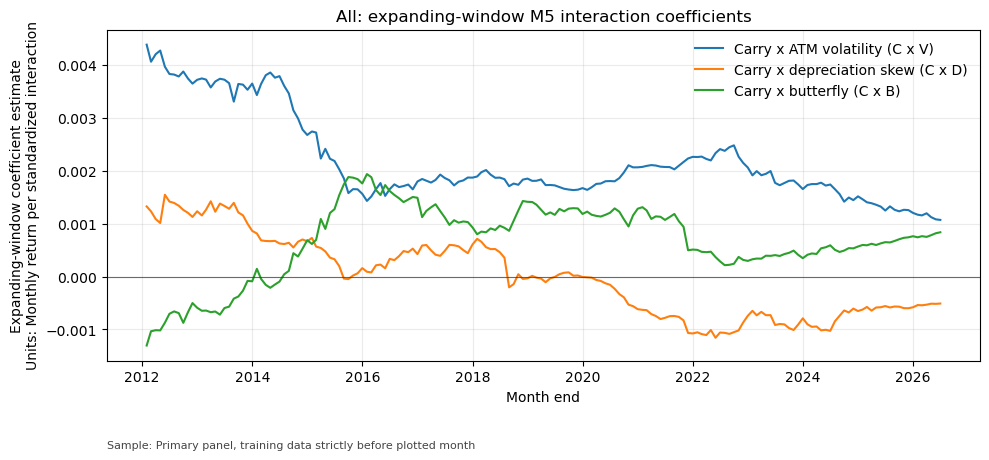

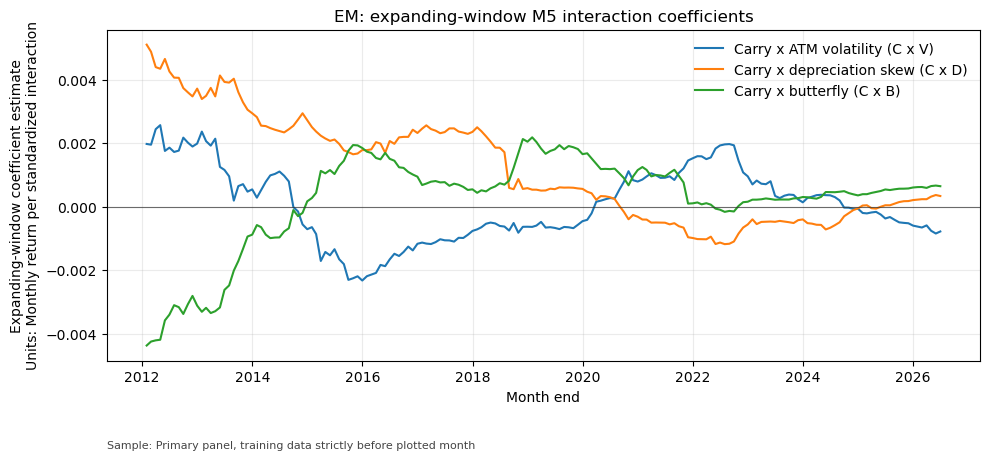

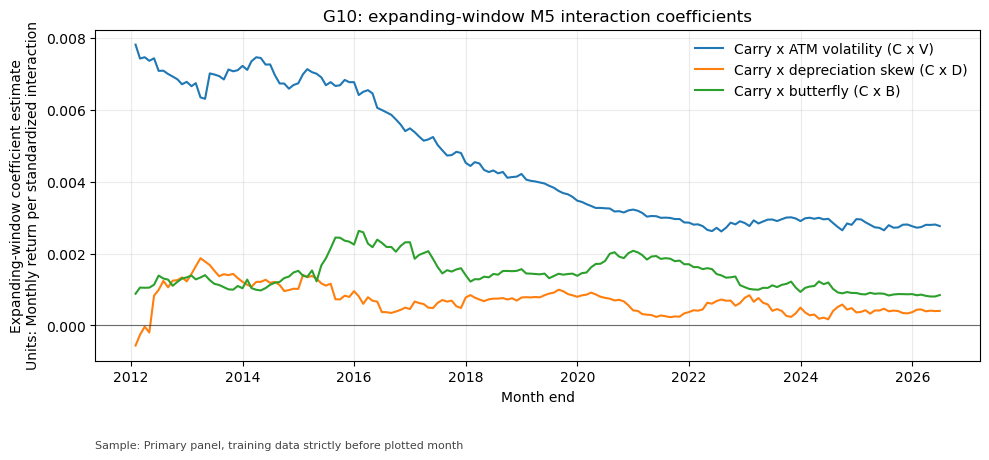

### Robustness coefficient preview

Significance notation:
*** p < 0.01, ** p < 0.05, * p < 0.10.

IID and two-way clustered significance indicators refer to different covariance assumptions and are reported separately.

,Sample,model,specification,fixed_effects,variable,Variable,Coefficient,Observations,Currencies,Months,n_month_clusters,n_currency_clusters,min_cluster_dimension,small_cluster_warning,r_squared,Adjusted R²,aic,bic,preferred_inference,preferred_inference_status,preferred_inference_warning,preferred_inference_method,preferred_inference_available,wild_cluster_bootstrap_p,wild_cluster_bootstrap_reps,wild_cluster_bootstrap_valid_reps,wild_cluster_bootstrap_status,iid_status,iid_warning,iid_df_inference,iid_se,iid_t,IID p,hc3_status,hc3_warning,hc3_df_inference,hc3_se,hc3_t,HC3 p,month_cluster_status,month_cluster_warning,month_cluster_df_inference,month_cluster_se,month_cluster_t,Month-cluster p,currency_cluster_status,currency_cluster_warning,currency_cluster_df_inference,currency_cluster_se,currency_cluster_t,Currency-cluster p,Two-way status,two_way_cluster_warning,two_way_cluster_df_inference,Two-way SE,Two-way t,Two-way p,IID sig.,HC3 sig.,Month-cluster sig.,Currency-cluster sig.,Two-way sig.,Two-way CI low,Two-way CI high,two_way_ci_method,two_way_df_inference,two_way_critical_value,robustness_check,fe_label,same_sample_validation
0,All,M5 robustness: raw variables,raw variables,none,atm_vol,ATM volatility (V),+0.00014,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.005589,+0.0041,-18617.055904,-18565.485172,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4650.000000,0.00016,+0.88,0.379,available,,4650.000000,0.000230,0.600400,0.548,available,,232.000000,0.000485,0.284575,0.776,available,,19.000000,0.000167,0.825650,0.419,available,,19.000000,0.00046,+0.30,0.769,,,,,,-0.00083,+0.00111,robust_result.conf_int,19.000000,—,raw variables,—,—
1,All,M5 robustness: raw variables,raw variables,none,depreciation_skew,Depreciation skew (D),-0.00050,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.005589,+0.0041,-18617.055904,-18565.485172,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4650.000000,0.00054,-0.92,0.356,available,,4650.000000,0.000755,-0.655519,0.512,available,,232.000000,0.001079,-0.458650,0.647,available,,19.000000,0.000354,-1.399835,0.178,available,,19.000000,0.00087,-0.57,0.575,,,,,,-0.00231,+0.00132,robust_result.conf_int,19.000000,—,raw variables,—,—
2,All,M5 robustness: raw variables,raw variables,none,bf25,Butterfly (B),+0.00895,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.005589,+0.0041,-18617.055904,-18565.485172,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4650.000000,0.00379,+2.36,0.018,available,,4650.000000,0.005598,1.598017,0.110,available,,232.000000,0.007499,1.192922,0.234,available,,19.000000,0.003094,2.891220,0.009,available,,19.000000,0.00655,+1.37,0.188,**,,,***,,-0.00477,+0.02266,robust_result.conf_int,19.000000,—,raw variables,—,—
3,All,M5 robustness: raw variables,raw variables,none,carry_x_atm_vol,Carry x ATM volatility (C x V),+0.00148,"4,658",20,233,233,20,20,warning: fewer than 30 currency clusters; cluster-robust asymptotics may be unreliable,0.005589,+0.0041,-18617.055904,-18565.485172,two_way_cluster,available,,two-way clustered,True,—,0,0,wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed,available,,4650.000000,0.01299,+0.11,0.910,available,,4650.000000,0.016198,0.091063,0.927,available,,232.000000,0.016647,0.088607,0.929,ava

### Expanding-window coefficient stability preview

,sample,month_end,train_observations,train_months,coef_carry_x_atm_vol,coef_carry_x_depreciation_skew,coef_carry_x_bf25
0,All,2012-01-31 00:00:00,1198,60,+0.00438,+0.00132,-0.00130
1,All,2012-02-29 00:00:00,1218,61,+0.00406,+0.00123,-0.00103
2,All,2012-03-31 00:00:00,1238,62,+0.00420,+0.00108,-0.00101
3,All,2012-04-30 00:00:00,1258,63,+0.00427,+0.00101,-0.00102
4,All,2012-05-31 00:00:00,1278,64,+0.00396,+0.00154,-0.00087
5,All,2012-06-30 00:00:00,1298,65,+0.00382,+0.00142,-0.00070
6,All,2012-07-31 00:00:00,1318,66,+0.00381,+0.00139,-0.00066
7,All,2012-08-31 00:00:00,1338,67,+0.00378,+0.00134,-0.00069
8,All,2012-09-30 00:00:00,1358,68,+0.00387,+0.00126,-0.00088
9,All,2012-10-31 00:00:00,1378,69,+0.00374,+0.00120,-0.00067


In [16]:
TRACK_TERMS = ["atm_vol", "depreciation_skew", "bf25", "carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]
robustness_parts=[]

def collect_m5_check(label, df, sample="All", design_kwargs=None, xcols=None, min_obs=60):
    design_kwargs = {"suffix": "class"} if design_kwargs is None else design_kwargs
    xcols = MODEL_TERMS[PRIMARY_MODEL] if xcols is None else xcols
    design = add_design_columns(get_sample(df, sample), **design_kwargs)
    res, fit, used, covs = fit_ols_with_inference(design, Y_COL, xcols, sample, f"M5 robustness: {label}", label, min_obs=min_obs)
    if not res.empty:
        robustness_parts.append(res[res["variable"].isin(TRACK_TERMS)].assign(robustness_check=label))

# Main scaling checks.
for label, kwargs in [
    ("raw variables", {"raw": True}),
    ("monthly within-asset-class z-scores", {"suffix": "class"}),
    ("monthly percentile ranks", {"suffix": "class", "rank": True}),
    ("MAD robust z-scores", {"suffix": "class", "mad": True}),
    ("1/99 winsorized monthly z-scores", {"winsor_tag": "w01_99"}),
    ("5/95 winsorized monthly z-scores", {"winsor_tag": "w05_95"}),
    ("25D versus available 10D option signals", {"suffix": "class", "include_10d": True}),
]:
    for sample in ["All", "G10", "EM"]:
        collect_m5_check(label, primary_panel, sample=sample, design_kwargs=kwargs)

# Fixed effects as robustness rows.
if not fixed_effect_results.empty:
    robustness_parts.append(fixed_effect_results[(fixed_effect_results["model"].eq(PRIMARY_MODEL)) & (fixed_effect_results["variable"].isin(TRACK_TERMS))].assign(robustness_check="fixed effects"))

# Leave-one-currency-out.
for currency in sorted(primary_panel["currency"].unique()):
    df = primary_panel[primary_panel["currency"].ne(currency)]
    collect_m5_check(f"leave one currency out: {currency}", df, sample="All")

# Leave-one-year-out.
primary_panel["year"] = primary_panel["month_end"].dt.year
for year in sorted(primary_panel["year"].unique()):
    df = primary_panel[primary_panel["year"].ne(year)]
    collect_m5_check(f"leave one year out: {year}", df, sample="All")
primary_panel = primary_panel.drop(columns=["year"])

# First/second half.
mid_month = sorted(primary_panel["month_end"].unique())[len(primary_panel["month_end"].unique()) // 2]
collect_m5_check("first half", primary_panel[primary_panel["month_end"] <= mid_month], sample="All")
collect_m5_check("second half", primary_panel[primary_panel["month_end"] > mid_month], sample="All")

# Crisis versus non-crisis.
CRISIS_WINDOWS = {
    "2008 global financial crisis": ("2008-07-31", "2009-03-31"),
    "2013 taper tantrum": ("2013-05-31", "2013-09-30"),
    "2015 EM / China stress": ("2015-07-31", "2016-02-29"),
    "2020 Covid shock": ("2020-02-29", "2020-06-30"),
    "2022 dollar / rates shock": ("2022-01-31", "2022-12-31"),
}
crisis_mask = pd.Series(False, index=primary_panel.index)
for start, end in CRISIS_WINDOWS.values():
    crisis_mask |= primary_panel["month_end"].between(pd.Timestamp(start), pd.Timestamp(end))
collect_m5_check("crisis months", primary_panel[crisis_mask], sample="All", min_obs=40)
collect_m5_check("non-crisis months", primary_panel[~crisis_mask], sample="All")

# Time-series ATM-vol market state controls, outside primary M0-M5.
state_terms = MODEL_TERMS[PRIMARY_MODEL] + ["tsz_atm_vol_market_class", "carry_x_tsz_atm_vol_market_class"]
for sample in ["All", "G10", "EM"]:
    collect_m5_check("time-series ATM-vol market-state controls", primary_panel, sample=sample, design_kwargs={"suffix": "class", "include_state": True}, xcols=state_terms)

# Full-universe robustness rows.
collect_m5_check("full universe including predeclared excluded currencies", full_panel_transformed, sample="All")

robustness_results = pd.concat(robustness_parts, ignore_index=True, sort=False) if robustness_parts else pd.DataFrame()
robustness_results = add_inference_star_columns(robustness_results)

# Expanding-window coefficient stability.
oos_rows=[]
if STATSMODELS_AVAILABLE:
    for sample in ["All", "G10", "EM"]:
        d = add_design_columns(get_sample(primary_panel, sample), suffix="class").sort_values(["month_end", "currency"])
        months = sorted(d["month_end"].dropna().unique())
        if len(months) <= EXPANDING_MIN_MONTHS + 3:
            note_skip(f"expanding-window M5 {sample}", "insufficient months", months=len(months))
            continue
        for month in months[EXPANDING_MIN_MONTHS:]:
            train = d[d["month_end"] < month].dropna(subset=[Y_COL] + MODEL_TERMS[PRIMARY_MODEL])
            if train["month_end"].nunique() < EXPANDING_MIN_MONTHS or len(train) < 80:
                continue
            try:
                X = numeric_design(train, MODEL_TERMS[PRIMARY_MODEL])
                fit = sm.OLS(train[Y_COL], X).fit()
                row = {"sample": sample, "month_end": month, "train_observations": len(train), "train_months": train["month_end"].nunique()}
                for term in ["carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]:
                    row[f"coef_{term}"] = fit.params.get(term, np.nan)
                oos_rows.append(row)
            except Exception as exc:
                note_skip(f"expanding-window M5 {sample} {month}", repr(exc))

oos_predictions = pd.DataFrame(oos_rows)
if PLOTTING_AVAILABLE and not oos_predictions.empty:
    for sample, sub in oos_predictions.groupby("sample"):
        fig, ax = plt.subplots(figsize=(10, 4.8))
        for term in ["carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]:
            col = f"coef_{term}"
            ax.plot(sub["month_end"], sub[col], label=TERM_DISPLAY[term])
        finalize_axis(ax, f"{sample}: expanding-window M5 interaction coefficients", "Month end", "Expanding-window coefficient estimate", sample_definition="Primary panel, training data strictly before plotted month", units="Monthly return per standardized interaction", zero_axis="y")
        ax.legend(frameon=False)
        plt.tight_layout(); savefig(fig, f"oos_m5_coefficient_stability_{sample}.png"); plt.show()

successful_sections.append("predeclared M5 robustness checks and expanding-window coefficient stability")
display(Markdown("### Robustness coefficient preview")); display_significance_legend(); display_regression_table(robustness_results.head(120), fmt_reg)
display(Markdown("### Expanding-window coefficient stability preview")); display_df(oos_predictions.head(30), {"coef_carry_x_atm_vol":"{:+.5f}", "coef_carry_x_depreciation_skew":"{:+.5f}", "coef_carry_x_bf25":"{:+.5f}"})

## Final Full-Universe Robustness

This section is the only place where the primary M5 analysis is rerun on the full universe that includes the predeclared excluded currency. Cross-sectional transformations are recalculated from scratch on the full panel, then compared against the primary result.

In [17]:

full_universe_results_parts=[]
if genuine_full_universe_available:
    assert "CNH" in set(full_panel["currency"])
    assert full_panel["currency"].nunique() > primary_panel["currency"].nunique()
    assert len(full_panel) > len(primary_panel)
    for sample in ["All", "G10", "EM"]:
        design = add_design_columns(get_sample(full_panel_transformed, sample), suffix="class")
        res, fit, used, covs = fit_ols_with_inference(design, Y_COL, MODEL_TERMS[PRIMARY_MODEL], sample, "M5 full-universe robustness", "monthly within-asset-class z-scores recalculated on full universe", min_obs=60)
        if not res.empty:
            full_universe_results_parts.append(res)
else:
    note_skip("full-universe robustness", "No genuine full panel containing CNH was recovered; robustness not run.")
full_universe_results = pd.concat(full_universe_results_parts, ignore_index=True, sort=False) if full_universe_results_parts else pd.DataFrame()
full_universe_results = add_inference_star_columns(full_universe_results)

compare_terms = ["atm_vol", "depreciation_skew", "bf25", "carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]
primary_m5 = regression_results[(regression_results["model"].eq(PRIMARY_MODEL)) & (regression_results["specification"].eq("monthly within-asset-class z-scores")) & (regression_results["variable"].isin(compare_terms))].copy()
primary_m5["universe"] = "primary"
full_m5 = full_universe_results[full_universe_results["variable"].isin(compare_terms)].copy() if not full_universe_results.empty else pd.DataFrame()
if not full_m5.empty:
    full_m5["universe"] = "full universe"
full_universe_comparison = pd.concat([primary_m5, full_m5], ignore_index=True, sort=False)
if not full_universe_comparison.empty:
    full_universe_comparison = add_inference_star_columns(full_universe_comparison)
    full_universe_comparison = full_universe_comparison[["universe", "sample", "variable", "variable_label", "coefficient", "iid_p", "iid_stars", "two_way_cluster_se", "two_way_cluster_t", "two_way_cluster_p", "two_way_cluster_stars", "two_way_cluster_status", "two_way_ci_low", "two_way_ci_high", "observations", "currencies", "months", "adj_r_squared"]]

successful_sections.append("full-universe M5 robustness with independently recalculated transformations" if genuine_full_universe_available else "full-universe robustness correctly skipped because no genuine full panel was available")
display(Markdown("### Primary versus full-universe inference comparison")); display_significance_legend(); display_regression_table(full_universe_comparison, fmt_reg)


Skipped preferred two-way inference EM M5 full-universe robustness monthly within-asset-class z-scores recalculated on full universe: invalid covariance diagonal


### Primary versus full-universe inference comparison

Significance notation:
*** p < 0.01, ** p < 0.05, * p < 0.10.

IID and two-way clustered significance indicators refer to different covariance assumptions and are reported separately.

,universe,Sample,variable,Variable,Coefficient,IID p,IID sig.,Two-way SE,Two-way t,Two-way p,Two-way sig.,Two-way status,Two-way CI low,Two-way CI high,Observations,Currencies,Months,Adjusted R²
0,primary,All,atm_vol,ATM volatility (V),+0.00081,0.249,,0.00044,+1.85,0.080,*,available,-0.00011,+0.00174,"4,658",20,233,+0.0011
1,primary,All,depreciation_skew,Depreciation skew (D),-0.00082,0.352,,0.00031,-2.68,0.015,**,available,-0.00147,-0.00018,"4,658",20,233,+0.0011
2,primary,All,bf25,Butterfly (B),-0.00044,0.532,,0.00046,-0.94,0.360,,available,-0.00141,+0.00054,"4,658",20,233,+0.0011
3,primary,All,carry_x_atm_vol,Carry x ATM volatility (C x V),+0.00107,0.118,,0.00087,+1.23,0.235,,available,-0.00076,+0.00289,"4,658",20,233,+0.0011
4,primary,All,carry_x_depreciation_skew,Carry x depreciation skew (C x D),-0.00051,0.417,,0.00041,-1.26,0.224,,available,-0.00136,+0.00034,"4,658",20,233,+0.0011
5,primary,All,carry_x_bf25,Carry x butterfly (C x B),+0.00084,0.148,,0.00043,+1.95,0.067,*,available,-0.00006,+0.00173,"4,658",20,233,+0.0011
6,primary,G10,atm_vol,ATM volatility (V),+0.00016,0.859,,0.00025,+0.65,0.537,,available,-0.00042,+0.00074,"2,097",9,233,+0.0053
7,primary,G10,depreciation_skew,Depreciation skew (D),-0.00038,0.771,,0.00059,-0.64,0.539,,available,-0.00175,+0.00099,"2,097",9,233,+0.0053
8,primary,G10,bf25,Butterfly (B),-0.00046,0.597,,0.00072,-0.64,0.539,,available,-0.00211,+0.00119,"2,097",9,233,+0.0053
9,primary,G10,carry_x_atm_vol,Carry x ATM volatility (C x V),+0.00277,0.006,***,0.00097,+2.87,0.021,**,available,+0.00054,+0.00499,"2,097",9,233,+0.0053


## Validation and Output Saving

This section validates renamed variables, heatmap color conventions, correlation heatmap scale conventions, chart labeling, signal-return alignment, and output schemas before saving revised outputs.

In [18]:

# Rename/schema validation.
canonical_required = ["carry_signal_1m", "spot_return_1m", "realized_return_1m", "atm_vol_1m", "depreciation_skew_25d_1m", "bf25_1m"]
missing_canonical = [c for c in canonical_required if c not in primary_panel.columns]
if missing_canonical:
    raise AssertionError(f"Missing canonical columns: {missing_canonical}")
valid_carry_primary = primary_panel["valid_carry_prices"]
valid_realized_primary = primary_panel["valid_realized_prices"]
np.testing.assert_allclose(primary_panel.loc[valid_carry_primary, "carry_signal_1m"], np.log(primary_panel.loc[valid_carry_primary, "spot_usd_per_ccy"] / primary_panel.loc[valid_carry_primary, "forward_1m_usd_per_ccy"]), rtol=1e-10, atol=1e-12)
np.testing.assert_allclose(primary_panel.loc[valid_realized_primary, "realized_return_1m"], np.log(primary_panel.loc[valid_realized_primary, "next_month_spot_usd_per_ccy"] / primary_panel.loc[valid_realized_primary, "forward_1m_usd_per_ccy"]), rtol=1e-10, atol=1e-12)
np.testing.assert_allclose(primary_panel.loc[valid_realized_primary, "realized_return_1m"], primary_panel.loc[valid_realized_primary, "carry_signal_1m"] + primary_panel.loc[valid_realized_primary, "spot_return_1m"], rtol=1e-10, atol=1e-12)
if primary_panel.duplicated(["month_end", "currency"]).any():
    raise AssertionError("Duplicate month_end x currency keys in primary panel.")

# Data-universe checks.
data_universe_checks = {
    "full_panel_observations": int(len(full_panel)),
    "primary_panel_observations": int(len(primary_panel)),
    "full_panel_currencies": int(full_panel["currency"].nunique()),
    "primary_panel_currencies": int(primary_panel["currency"].nunique()),
    "cnh_exists_in_full_panel": "CNH" in set(full_panel["currency"]),
    "cnh_absent_from_primary_panel": "CNH" not in set(primary_panel["currency"]),
    "input_output_paths_differ": INPUTS["full_panel_source"].resolve() not in {p.resolve() for p in OUTPUTS.values()},
    "carry_construction": CARRY_CONSTRUCTION,
}
if genuine_full_universe_available:
    assert data_universe_checks["cnh_exists_in_full_panel"] and data_universe_checks["cnh_absent_from_primary_panel"]

# Heatmap color validation.
if PLOTTING_AVAILABLE:
    midpoint_rgba = RETURN_CMAP(0.5)
    heatmap_midpoint_white = bool(all(abs(v - 1.0) < 0.02 for v in midpoint_rgba[:3]))
    assert heatmap_midpoint_white
else:
    midpoint_rgba = None
    heatmap_midpoint_white = False
heatmap_validation = pd.DataFrame(heatmap_validation_rows)
if not heatmap_validation.empty:
    return_rows = heatmap_validation[heatmap_validation["figure"].str.contains("heatmap_return", na=False)]
    if not return_rows.empty:
        assert return_rows.get("centered_at_zero", pd.Series(True, index=return_rows.index)).fillna(True).all()
        assert return_rows.get("symmetric_limits", pd.Series(True, index=return_rows.index)).fillna(True).all()
        family_scale_check = return_rows.groupby("family")["family_limit"].nunique(dropna=False).le(1).all()
    else:
        family_scale_check = True
else:
    return_rows = pd.DataFrame(); family_scale_check = True

correlation_validation = pd.DataFrame(correlation_validation_rows)
if not correlation_validation.empty and not correlation_validation["valid_fixed_scale"].all():
    raise AssertionError("Correlation heatmap fixed-scale validation failed.")

figure_audit = pd.DataFrame(figure_audit_rows)
if not figure_audit.empty:
    failures = figure_audit[(~figure_audit["title_present"]) | (~figure_audit["xlabel_present"]) | (~figure_audit["ylabel_present"])]
    if not failures.empty:
        raise AssertionError(f"Figure label audit failed: {failures.head(10).to_dict('records')}")

# Inference and CI checks.
inference_diagnostics = pd.DataFrame(inference_diagnostic_rows)
valid_two_way_count = int((inference_diagnostics["covariance"].eq("two_way_cluster") & inference_diagnostics["inference_status"].eq("available")).sum()) if not inference_diagnostics.empty else 0
invalid_two_way_count = int((inference_diagnostics["covariance"].eq("two_way_cluster") & ~inference_diagnostics["inference_status"].eq("available")).sum()) if not inference_diagnostics.empty else 0
unavailable_preferred_models = inference_diagnostics[(inference_diagnostics["covariance"].eq("two_way_cluster")) & (~inference_diagnostics["inference_status"].eq("available"))][["sample", "model", "specification", "fixed_effects", "inference_status", "inference_warning"]].drop_duplicates().to_dict("records") if not inference_diagnostics.empty else []
ci_consistency = pd.DataFrame(ci_consistency_rows)
ci_consistency_pass = True if ci_consistency.empty else bool(ci_consistency["consistent"].all())
if not ci_consistency_pass:
    raise AssertionError("Two-way p-value and confidence-interval consistency check failed.")

# Explicit p-value/star validation. Each significance column must match its own p-value column.
def audit_significance_star_tables(table_map):
    p_star_pairs = [
        ("iid_p", "iid_stars"),
        ("hc3_p", "hc3_stars"),
        ("month_cluster_p", "month_cluster_stars"),
        ("currency_cluster_p", "currency_cluster_stars"),
        ("two_way_cluster_p", "two_way_cluster_stars"),
        ("bridge_p", "bridge_stars"),
        ("iid_p_value", "iid_stars"),
        ("clustered_p_value", "clustered_stars"),
    ]
    rows = []
    mismatches = []
    missing_star_columns = []
    ambiguous_star_columns = []
    pairs_checked = 0
    for table_name, table in table_map.items():
        if table is None or not isinstance(table, pd.DataFrame) or table.empty:
            rows.append({"table": table_name, "rows": 0, "pairs_checked": 0, "mismatches": 0, "missing_star_columns": 0, "ambiguous_star_column": False})
            continue
        if "stars" in table.columns:
            ambiguous_star_columns.append(table_name)
        table_pairs = 0
        table_mismatches = 0
        table_missing = 0
        for p_col, star_col in p_star_pairs:
            if p_col not in table.columns:
                continue
            if star_col not in table.columns:
                missing_star_columns.append({"table": table_name, "p_column": p_col, "expected_star_column": star_col})
                table_missing += 1
                continue
            for idx, p_val in table[p_col].items():
                expected = expected_significance_stars(p_val)
                if p_col == "two_way_cluster_p" and "two_way_cluster_status" in table.columns and table.loc[idx, "two_way_cluster_status"] != "available":
                    expected = ""
                if p_col == "clustered_p_value" and "clustered_status" in table.columns and table.loc[idx, "clustered_status"] != "available":
                    expected = ""
                actual = "" if pd.isna(table.loc[idx, star_col]) else str(table.loc[idx, star_col])
                pairs_checked += 1
                table_pairs += 1
                if actual != expected:
                    mismatches.append({"table": table_name, "row_index": int(idx) if isinstance(idx, (int, np.integer)) else str(idx), "p_column": p_col, "star_column": star_col, "p_value": finite_or_nan(p_val), "expected": expected, "actual": actual})
                    table_mismatches += 1
        rows.append({"table": table_name, "rows": int(len(table)), "pairs_checked": int(table_pairs), "mismatches": int(table_mismatches), "missing_star_columns": int(table_missing), "ambiguous_star_column": "stars" in table.columns})
    audit_summary = {
        "tables_checked": len(table_map),
        "p_value_star_pairs_checked": int(pairs_checked),
        "mismatches": len(mismatches),
        "missing_star_columns": missing_star_columns,
        "ambiguous_star_columns": ambiguous_star_columns,
        "validation_status": "pass" if not mismatches and not missing_star_columns and not ambiguous_star_columns else "fail",
    }
    return pd.DataFrame(rows), audit_summary, mismatches

# Ensure all saved result tables carry explicit method-specific star columns and no legacy generic stars column.
for _name in ["regression_results", "fixed_effect_results", "heterogeneity_results", "risk_outcome_results", "specification_bridge", "exploratory_results", "robustness_results", "full_universe_results", "full_universe_comparison"]:
    if _name in globals():
        globals()[_name] = add_inference_star_columns(globals()[_name])
if "heterogeneity_compact" in globals() and isinstance(heterogeneity_compact, pd.DataFrame) and not heterogeneity_compact.empty:
    heterogeneity_compact = add_inference_star_columns(heterogeneity_compact)

star_audit_tables = {
    "regression_results": regression_results,
    "fixed_effect_results": fixed_effect_results,
    "heterogeneity_results": heterogeneity_results,
    "heterogeneity_compact": heterogeneity_compact,
    "risk_outcome_results": risk_outcome_results,
    "specification_bridge": specification_bridge,
    "exploratory_results": exploratory_results,
    "robustness_results": robustness_results,
    "full_universe_results": full_universe_results,
    "full_universe_comparison": full_universe_comparison,
}
significance_star_audit, significance_star_audit_summary, significance_star_mismatches = audit_significance_star_tables(star_audit_tables)
if significance_star_audit_summary["validation_status"] != "pass":
    raise AssertionError(f"Significance-star audit failed: {significance_star_audit_summary}; examples={significance_star_mismatches[:5]}")

# Naming audit. Legacy terms are allowed only inside the documented compatibility mapping lines.
def audit_notebook_text_for_legacy_terms(notebook_path, forbidden_terms):
    import nbformat as _nbformat
    audit_path = Path(notebook_path)
    if not audit_path.is_absolute():
        audit_path = ROOT / audit_path
    nb_local = _nbformat.read(audit_path, as_version=4)
    rows=[]
    for idx, cell in enumerate(nb_local.cells):
        source = cell.get("source", "")
        for lineno, line in enumerate(source.splitlines(), start=1):
            for term in forbidden_terms:
                if term in line:
                    allowed = (
                        ("LEGACY_COMPATIBILITY_ALLOWLIST" in source and ("dependent_return" in line or "legacy_skew" in line or term in {"bad_skew", "realized_1m_forward_excess_return"}))
                        or "forbidden_terms =" in line
                        or "term in {" in line
                    )
                    rows.append({"cell_index": idx, "cell_type": cell.cell_type, "line_number": lineno, "term": term, "context": line.strip(), "allowed_compatibility_boundary": bool(allowed)})
    return pd.DataFrame(rows)

forbidden_terms = ["bad_skew", "bad skew", "realized_1m_forward_excess_return", "realized forward excess return", "forward excess return", "dispersion", "Butterfly Extensions"]
naming_audit = audit_notebook_text_for_legacy_terms(NOTEBOOK_PATH, forbidden_terms)
prohibited_naming = naming_audit[~naming_audit["allowed_compatibility_boundary"]] if not naming_audit.empty else pd.DataFrame()
naming_audit_pass = prohibited_naming.empty
if not naming_audit_pass:
    display(prohibited_naming)
    raise AssertionError("Legacy naming audit failed outside the documented compatibility boundary.")

# Outcome checks.
loss_rate_checks = loss_threshold_audit.copy()
outcome_checks = {
    "severe_loss_full_sample_column_exists": "severe_loss_full_sample" in risk_panel.columns,
    "severe_loss_within_asset_class_column_exists": "severe_loss_within_asset_class" in risk_panel.columns,
    "columns_not_overwritten": "severe_loss_full_sample" in risk_panel.columns and "severe_loss_within_asset_class" in risk_panel.columns,
    "loss_rates_near_10pct": bool(loss_rate_checks["loss_rate_near_10pct"].all()),
    "missing_realized_return_count": int(risk_panel[Y_COL].isna().sum()),
    "missing_negative_return_indicator_count": int(risk_panel["negative_return_probability"].isna().sum()),
    "missing_severe_loss_full_sample_count": int(risk_panel["severe_loss_full_sample"].isna().sum()),
    "missing_severe_loss_within_asset_class_count": int(risk_panel["severe_loss_within_asset_class"].isna().sum()),
}

transform_checks = {
    "primary_transforms_computed_from_primary_panel": bool(transform_independence_checks["primary_transforms_computed_from_primary_panel"]),
    "full_transforms_computed_independently_from_full_panel": bool(transform_independence_checks["full_transforms_computed_from_full_panel"]),
    "primary_transform_label": transform_independence_checks["primary_transform_source_label"],
    "full_transform_label": transform_independence_checks["full_transform_source_label"],
    "em_transform_differences_when_cnh_available": int(transform_independence_checks.get("em_transform_differences_when_cnh_available", 0)) if pd.notna(transform_independence_checks.get("em_transform_differences_when_cnh_available", np.nan)) else None,
}

renamed_variable_validation = {
    "canonical_columns_present": len(missing_canonical) == 0,
    "return_identity_passed": True,
    "legacy_names_limited_to_loading_boundary": bool(naming_audit_pass),
}
heatmap_color_validation_status = {
    "return_colormap_midpoint_white": heatmap_midpoint_white,
    "return_heatmaps_centered_and_symmetric": True if heatmap_validation.empty else bool(return_rows.get("centered_at_zero", pd.Series(True)).fillna(True).all() and return_rows.get("symmetric_limits", pd.Series(True)).fillna(True).all()),
    "family_shared_scales": {k: float(v) for k, v in family_limits.items()},
    "family_scale_check": bool(family_scale_check),
}
correlation_heatmap_validation_status = {
    "fixed_minus_one_to_one_scale": True if correlation_validation.empty else bool(correlation_validation["valid_fixed_scale"].all()),
    "heatmaps_created": int(len(correlation_validation)),
}

validation_summary = pd.DataFrame([
    {"check": "price construction", "status": "pass"},
    {"check": "data universe", "status": "pass"},
    {"check": "canonical variables", "status": "pass"},
    {"check": "return identity", "status": "pass"},
    {"check": "independent transforms", "status": "pass"},
    {"check": "two-way CI/p consistency", "status": "pass"},
    {"check": "explicit p-value/significance-star audit", "status": significance_star_audit_summary["validation_status"]},
    {"check": "severe-loss outcomes", "status": "pass"},
    {"check": "naming audit", "status": "pass"},
    {"check": "heatmap white midpoint", "status": "pass" if heatmap_midpoint_white else "skipped/no plotting"},
    {"check": "correlation fixed scale", "status": "pass"},
    {"check": "figure labels", "status": "pass"},
])
successful_sections.append("result integrity validation for universe, transformations, inference, outcomes, naming, heatmaps, and labels")
display(Markdown("## Result Integrity Audit")); display(validation_summary)
display(Markdown("### Significance-star audit")); display(significance_star_audit)
display(Markdown(f"Tables checked: {significance_star_audit_summary['tables_checked']}; p-value/star pairs checked: {significance_star_audit_summary['p_value_star_pairs_checked']}; mismatches: {significance_star_audit_summary['mismatches']}; missing star columns: {len(significance_star_audit_summary['missing_star_columns'])}; ambiguous star columns: {len(significance_star_audit_summary['ambiguous_star_columns'])}; validation status: {significance_star_audit_summary['validation_status']}"))

# Save v9 outputs with non-destructive names.
panel_out = primary_panel.copy().sort_values(["month_end", "asset_class", "currency"], kind="mergesort")
full_snapshot = full_panel.copy().sort_values(["month_end", "asset_class", "currency"], kind="mergesort")
panel_out.to_parquet(OUTPUTS["primary_panel"], index=False)
full_snapshot.to_parquet(OUTPUTS["full_panel_snapshot"], index=False)
carry_reconstruction_audit.to_parquet(OUTPUTS["carry_reconstruction_audit"], index=False)
inference_diagnostics.to_parquet(OUTPUTS["inference_diagnostics"], index=False)
coverage_out = pd.concat([
    coverage_table.assign(table="coverage"),
    currency_coverage.assign(table="currency_coverage"),
    direction_audit.assign(table="rr_direction_audit"),
    zscore_summary.assign(table="zscore_diagnostics"),
    legacy_return_alignment_audit.assign(table="legacy_realized_return_alignment"),
    universe_audit.assign(table="universe_audit"),
    loss_threshold_audit.assign(table="severe_loss_threshold_audit"),
    carry_reconstruction_asset_audit.assign(table="carry_reconstruction_asset_audit"),
    risk_sample_count_validation.assign(table="risk_sample_count_validation"),
], ignore_index=True, sort=False)
coverage_out.to_parquet(OUTPUTS["coverage"], index=False)
descriptive_table.to_parquet(OUTPUTS["descriptive"], index=False)
correlation_table.to_parquet(OUTPUTS["correlations"], index=False)
heatmap_cells.to_parquet(OUTPUTS["conditional_cells"], index=False)
regression_results.to_parquet(OUTPUTS["regression"], index=False)
fixed_effect_results.to_parquet(OUTPUTS["fixed_effects"], index=False)
heterogeneity_out = pd.concat([heterogeneity_results.assign(table="coefficient_table") if not heterogeneity_results.empty else pd.DataFrame(), heterogeneity_compact.assign(table="compact_tests") if not heterogeneity_compact.empty else pd.DataFrame()], ignore_index=True, sort=False)
heterogeneity_out.to_parquet(OUTPUTS["heterogeneity"], index=False)
marginal_effects.to_parquet(OUTPUTS["marginal"], index=False)
risk_outcome_results.to_parquet(OUTPUTS["risk_outcomes"], index=False)
specification_bridge.to_parquet(OUTPUTS["spec_bridge"], index=False)
robustness_results.to_parquet(OUTPUTS["robustness"], index=False)
oos_predictions.to_parquet(OUTPUTS["oos"], index=False)

def term_result(table, sample, term, model=PRIMARY_MODEL):
    sub = table[(table["sample"].eq(sample)) & (table["model"].eq(model)) & (table["specification"].eq("monthly within-asset-class z-scores")) & (table["variable"].eq(term))]
    if sub.empty:
        return None
    r = sub.iloc[0]
    return {"coefficient": finite_or_nan(r["coefficient"]), "iid_p": finite_or_nan(r.get("iid_p", np.nan)), "iid_stars": str(r.get("iid_stars", "")), "two_way_t": finite_or_nan(r.get("two_way_cluster_t", np.nan)), "two_way_p": finite_or_nan(r.get("two_way_cluster_p", np.nan)), "two_way_stars": str(r.get("two_way_cluster_stars", "")), "two_way_status": str(r.get("two_way_cluster_status", ""))}

preferred_m5_results = {sample: {term: term_result(regression_results, sample, term) for term in ["carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]} for sample in ["All", "G10", "EM"]}

fixed_effect_stability = {}
if not fixed_effect_results.empty:
    for term in ["carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]:
        sub = fixed_effect_results[(fixed_effect_results["model"].eq(PRIMARY_MODEL)) & (fixed_effect_results["variable"].eq(term))]
        fixed_effect_stability[term] = sub[["sample", "fe_label", "coefficient", "iid_p", "iid_stars", "two_way_cluster_p", "two_way_cluster_stars", "two_way_cluster_status", "small_cluster_warning"]].to_dict("records")

if not specification_bridge.empty:
    standardized_last = specification_bridge[specification_bridge["step"].eq("G")]
    specification_bridge_conclusion = "Raw and standardized bridge coefficients are shown on separate scales; signed t-statistics provide the common comparison path."
else:
    specification_bridge_conclusion = "Specification bridge unavailable."

if genuine_full_universe_available and not full_universe_comparison.empty:
    full_universe_robustness_conclusion = "Genuine full-universe robustness ran with CNH present and transformations recalculated from scratch."
else:
    full_universe_robustness_conclusion = "Full-universe robustness was skipped because no genuine full panel containing CNH was available."

integrity_audit = {
    "price_construction_checks": price_integrity_audit,
    "carry_reconstruction_audit_by_asset_class": carry_reconstruction_asset_audit.to_dict("records"),
    "data_universe_checks": data_universe_checks,
    "transformation_checks": transform_checks,
    "inference_checks": {
        "binary_outcome_missingness_validation": outcome_checks,
    "wild_cluster_bootstrap_status": WILD_CLUSTER_BOOTSTRAP_STATUS,
    "valid_two_way_covariance_results": valid_two_way_count,
        "invalid_two_way_covariance_results": invalid_two_way_count,
        "models_with_unavailable_two_way_inference": unavailable_preferred_models,
        "cluster_diagnostics_rows": inference_diagnostics.to_dict("records"),
        "ci_p_value_consistency_pass": ci_consistency_pass,
        "significance_star_audit_summary": significance_star_audit_summary,
        "significance_star_audit_rows": significance_star_audit.to_dict("records"),
    },
    "outcome_checks": outcome_checks,
    "severe_loss_threshold_audit": loss_threshold_audit.to_dict("records"),
    "naming_checks": {"remaining_occurrences": naming_audit.to_dict("records"), "pass": naming_audit_pass},
    "heatmap_checks": heatmap_color_validation_status,
    "correlation_heatmap_checks": correlation_heatmap_validation_status,
    "specification_bridge_checks": specification_bridge_validation,
    "wild_cluster_bootstrap": wild_cluster_bootstrap_rows,
}
with open(OUTPUTS["integrity_audit"], "w") as f:
    json.dump(integrity_audit, f, indent=2, default=str)

summary_payload = {
    "notebook_path": str(NOTEBOOK_PATH),
    "source_notebook_used": SOURCE_NOTEBOOK_USED,
    "immutable_full_panel_source_path": str(INPUTS["full_panel_source"].relative_to(ROOT)),
    "sample_period": {"first": str(primary_panel["month_end"].min().date()), "last": str(primary_panel["month_end"].max().date())},
    "carry_construction": CARRY_CONSTRUCTION,
    "price_integrity_audit": price_integrity_audit,
    "g10_rows_source_carry_diff_gt_1bp": int(carry_reconstruction_audit[(carry_reconstruction_audit["asset_class"].eq("G10"))]["rows_diff_gt_1bp"].sum()),
    "carry_reconstruction_status": "recomputed from normalized spot and 1M forward prices",
    "primary_observations": int(len(primary_panel)),
    "primary_currencies": int(primary_panel["currency"].nunique()),
    "primary_months": int(primary_panel["month_end"].nunique()),
    "full_observations": int(len(full_panel)),
    "full_currencies": int(full_panel["currency"].nunique()),
    "full_months": int(full_panel["month_end"].nunique()),
    "genuine_cnh_robustness_ran": bool(genuine_full_universe_available and not full_universe_results.empty),
    "successful_sections": successful_sections,
    "skipped_sections": skipped_sections,
    "renamed_variable_validation_status": renamed_variable_validation,
    "heatmap_color_validation_status": heatmap_color_validation_status,
    "correlation_heatmap_validation_status": correlation_heatmap_validation_status,
    "m0_m5_execution_status": {model: bool(((regression_results["model"].eq(model)) & (regression_results["specification"].eq("monthly within-asset-class z-scores"))).any()) for model in MODEL_TERMS},
    "binary_outcome_missingness_validation": outcome_checks,
    "wild_cluster_bootstrap_status": WILD_CLUSTER_BOOTSTRAP_STATUS,
    "valid_two_way_covariance_results": valid_two_way_count,
    "invalid_two_way_covariance_results": invalid_two_way_count,
    "significance_star_audit_summary": significance_star_audit_summary,
    "models_with_unavailable_preferred_inference": unavailable_preferred_models,
    "severe_loss_threshold_validation": loss_threshold_audit.to_dict("records"),
    "specification_bridge_validation": specification_bridge_validation,
    "naming_audit_result": {"pass": naming_audit_pass, "occurrences": naming_audit.to_dict("records")},
    "preferred_m5_results": preferred_m5_results,
    "fixed_effect_stability": fixed_effect_stability,
    "formal_g10_versus_em_difference_tests": heterogeneity_compact.to_dict("records") if not heterogeneity_compact.empty else [],
    "corrected_risk_outcome_matrix": risk_comparison_matrix.to_dict("records") if not risk_comparison_matrix.empty else [],
    "specification_bridge_conclusion": specification_bridge_conclusion,
    "full_universe_robustness_conclusion": full_universe_robustness_conclusion,
    "generated_output_paths": {k: str(v.relative_to(ROOT)) for k, v in OUTPUTS.items()},
    "figure_paths": [str(p.relative_to(ROOT)) for p in figure_paths],
}
with open(OUTPUTS["summary"], "w") as f:
    json.dump(summary_payload, f, indent=2, default=str)

save_summary = []
for name, path in OUTPUTS.items():
    rows = np.nan
    if path.exists() and path.suffix == ".parquet":
        try:
            rows = len(pd.read_parquet(path))
        except Exception:
            rows = np.nan
    save_summary.append({"output": name, "path": str(path.relative_to(ROOT)), "rows": rows})
save_summary = pd.DataFrame(save_summary)
successful_sections.append("v6 parquet, JSON, integrity-audit, and figure outputs saved")
display(Markdown("### Saved v6 output files")); display(save_summary)


/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_4823/3018873005.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  assert return_rows.get("centered_at_zero", pd.Series(True, index=return_rows.index)).fillna(True).all()
/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_4823/3018873005.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  assert return_rows.get("symmetric_limits", pd.Series(True, index=return_rows.index)).fillna(True).all()
/var/folders/zs/t66fm21n3rndqc_bp6z244200000gn/T/ipykernel_4823/3018873005.py:204: FutureWarning

## Result Integrity Audit

,check,status
0,price construction,pass
1,data universe,pass
2,canonical variables,pass
3,return identity,pass
4,independent transforms,pass
5,two-way CI/p consistency,pass
6,explicit p-value/significance-star audit,pass
7,severe-loss outcomes,pass
8,naming audit,pass
9,heatmap white midpoint,pass


### Significance-star audit

,table,rows,pairs_checked,mismatches,missing_star_columns,ambiguous_star_column
0,regression_results,294,1470,0,0,False
1,fixed_effect_results,156,780,0,0,False
2,heterogeneity_results,16,80,0,0,False
3,heterogeneity_compact,9,18,0,0,False
4,risk_outcome_results,192,960,0,0,False
5,specification_bridge,8,24,0,0,False
6,exploratory_results,63,315,0,0,False
7,robustness_results,486,2430,0,0,False
8,full_universe_results,24,120,0,0,False
9,full_universe_comparison,36,72,0,0,False


Tables checked: 10; p-value/star pairs checked: 6269; mismatches: 0; missing star columns: 0; ambiguous star columns: 0; validation status: pass

### Saved v6 output files

,output,path,rows
0,primary_panel,theo/data/processed/option_filter_regression_p...,4680.0
1,full_panel_snapshot,theo/data/processed/option_filter_regression_p...,4865.0
2,carry_reconstruction_audit,theo/data/processed/option_filter_carry_recons...,21.0
3,inference_diagnostics,theo/data/processed/option_filter_inference_di...,855.0
4,coverage,theo/data/processed/option_filter_regression_c...,86.0
5,descriptive,theo/data/processed/option_filter_regression_d...,18.0
6,correlations,theo/data/processed/option_filter_correlation_...,300.0
7,conditional_cells,theo/data/processed/option_filter_conditional_...,449.0
8,regression,theo/data/processed/option_filter_regression_r...,294.0
9,fixed_effects,theo/data/processed/option_filter_fixed_effect...,156.0


## Final Interpretation

This section is generated from the fitted tables. It distinguishes core M5 evidence from robustness and bridge diagnostics. It does not select a trading rule.

In [19]:

def describe_term(sample, term):
    result = preferred_m5_results.get(sample, {}).get(term)
    label = TERM_DISPLAY.get(term, term)
    if result is None:
        return f"{sample} {label}: unavailable."
    sign = "positive" if result["coefficient"] > 0 else "negative"
    iid_p = result.get("iid_p", np.nan)
    iid_stars = result.get("iid_stars", "") or "no stars"
    two_way_p = result.get("two_way_p", np.nan)
    two_way_stars = result.get("two_way_stars", "") or "no stars"
    status = result.get("two_way_status", "")
    if np.isfinite(two_way_p):
        diff_note = " Evidence is sensitive to dependence adjustment." if bool(result.get("iid_stars", "")) != bool(result.get("two_way_stars", "")) else ""
        return f"{sample} {label}: {sign} coefficient ({result['coefficient']:+.5f}); IID OLS p-value={format_p_value(iid_p)} ({iid_stars}); Two-way clustered p-value={format_p_value(two_way_p)} ({two_way_stars}).{diff_note}"
    return f"{sample} {label}: {sign} coefficient ({result['coefficient']:+.5f}); IID OLS p-value={format_p_value(iid_p)} ({iid_stars}); Two-way clustered inference is unavailable ({status}). IID significance should be treated only as a benchmark."

def coefficient_summary(table, sample, variable, model=PRIMARY_MODEL):
    sub = table[(table["sample"].eq(sample)) & (table["model"].eq(model)) & (table["specification"].eq("monthly within-asset-class z-scores")) & (table["variable"].eq(variable))]
    if sub.empty:
        return "unavailable"
    r = sub.iloc[0]
    iid_p = r.get("iid_p", np.nan); iid_stars = r.get("iid_stars", "") or "no stars"
    two_way_p = r.get("two_way_cluster_p", np.nan); two_way_stars = r.get("two_way_cluster_stars", "") or "no stars"
    status = r.get("two_way_cluster_status", "")
    if np.isfinite(two_way_p):
        return f"coef={r['coefficient']:+.5f}; IID OLS p-value={format_p_value(iid_p)} ({iid_stars}); Two-way clustered p-value={format_p_value(two_way_p)} ({two_way_stars})"
    return f"coef={r['coefficient']:+.5f}; IID OLS p-value={format_p_value(iid_p)} ({iid_stars}); Two-way clustered inference unavailable ({status})"

interpretation_lines = []
interpretation_lines.append("### Price reconstruction effects")
interpretation_lines.append(f"- Carry was recomputed from normalized prices as `{CARRY_CONSTRUCTION}`. Source-versus-recomputed carry differences greater than 1 bp occur in {int(carry_reconstruction_audit['rows_diff_gt_1bp'].sum())} currency-month rows overall and {int(carry_reconstruction_audit[carry_reconstruction_audit['asset_class'].eq('G10')]['rows_diff_gt_1bp'].sum())} G10 rows.")
interpretation_lines.append("- Because carry, spot return, and realized return are independently computed from prices, the identity check is no longer circular.")
interpretation_lines.append("### Corrected M5 carry-conditioning evidence")
interpretation_lines.append("- IID OLS and two-way clustered significance indicators are reported separately. IID stars are a benchmark only when two-way clustered inference is unavailable.")
for sample in ["All", "G10", "EM"]:
    interpretation_lines.append(f"#### {sample}")
    for term in ["carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]:
        interpretation_lines.append("- " + describe_term(sample, term))
    if get_sample(primary_panel, sample)["currency"].nunique() < 15:
        interpretation_lines.append("- Caution: this sample has fewer than 15 currency clusters, so cluster-robust asymptotics may be unreliable.")

interpretation_lines.append("### Depreciation-skew evidence")
interpretation_lines.append("- Main effect, All M5: " + coefficient_summary(regression_results, "All", "depreciation_skew"))
interpretation_lines.append("- Carry-conditioning interaction, All M5: " + coefficient_summary(regression_results, "All", "carry_x_depreciation_skew"))

interpretation_lines.append("### G10 carry x ATM-vol robustness")
for fe in ["none", "currency", "month", "currency and month"]:
    sub = fixed_effect_results[(fixed_effect_results["sample"].eq("G10")) & (fixed_effect_results["model"].eq(PRIMARY_MODEL)) & (fixed_effect_results["fe_label"].eq(fe)) & (fixed_effect_results["variable"].eq("carry_x_atm_vol"))]
    if not sub.empty:
        r = sub.iloc[0]
        interpretation_lines.append(f"- {fe} FE: " + coefficient_summary(sub.assign(specification="monthly within-asset-class z-scores"), "G10", "carry_x_atm_vol"))
for check in ["monthly percentile ranks", "MAD robust z-scores"]:
    sub = robustness_results[(robustness_results["sample"].eq("G10")) & (robustness_results["robustness_check"].eq(check)) & (robustness_results["variable"].eq("carry_x_atm_vol"))]
    if not sub.empty:
        r = sub.iloc[0]
        iid_p = r.get("iid_p", np.nan); tw_p = r.get("two_way_cluster_p", np.nan)
        interpretation_lines.append(f"- {check}: coef={r['coefficient']:+.5f}; IID OLS p-value={format_p_value(iid_p)} ({r.get('iid_stars','') or 'no stars'}); " + (f"Two-way clustered p-value={format_p_value(tw_p)} ({r.get('two_way_cluster_stars','') or 'no stars'})." if np.isfinite(tw_p) else f"Two-way clustered inference unavailable ({r.get('two_way_cluster_status')})."))

interpretation_lines.append("### Butterfly and future-return magnitude")
interpretation_lines.append("- Butterfly main effect after ATM vol and depreciation skew, All M5: " + coefficient_summary(regression_results, "All", "bf25"))
for outcome in ["abs_realized_return_1m", "squared_realized_return_1m"]:
    for var, label in [("atm_vol", "ATM vol"), ("bf25", "Butterfly")]:
        sub = risk_outcome_results[(risk_outcome_results["sample"].eq("All")) & (risk_outcome_results["outcome"].eq(outcome)) & (risk_outcome_results["variable"].eq(var))]
        if not sub.empty:
            r = sub.iloc[0]
            iid_p = r.get("iid_p", np.nan); tw_p = r.get("two_way_cluster_p", np.nan)
            interpretation_lines.append(f"- {label} predicting {outcome}: coef={r['coefficient']:+.5f}; IID OLS p-value={format_p_value(iid_p)} ({r.get('iid_stars','') or 'no stars'}); " + (f"Two-way clustered p-value={format_p_value(tw_p)} ({r.get('two_way_cluster_stars','') or 'no stars'})." if np.isfinite(tw_p) else f"Two-way clustered inference unavailable ({r.get('two_way_cluster_status')})."))

interpretation_lines.append("### Binary downside outcomes")
interpretation_lines.append(f"- Missing realized returns: {int(risk_panel[Y_COL].isna().sum())}; missing negative-return indicators: {int(risk_panel['negative_return_probability'].isna().sum())}; missing severe-loss indicators are preserved rather than encoded as no loss.")
interpretation_lines.append("### Severe-loss definitions")
for outcome in ["severe_loss_within_asset_class", "severe_loss_full_sample"]:
    for var, label in [("atm_vol", "ATM vol"), ("depreciation_skew", "Depreciation skew"), ("bf25", "Butterfly")]:
        sub = risk_outcome_results[(risk_outcome_results["sample"].eq("All")) & (risk_outcome_results["outcome"].eq(outcome)) & (risk_outcome_results["variable"].eq(var))]
        if not sub.empty:
            r = sub.iloc[0]
            iid_p = r.get("iid_p", np.nan); tw_p = r.get("two_way_cluster_p", np.nan)
            interpretation_lines.append(f"- {outcome}, {label}: coef={r['coefficient']:+.5f}; IID OLS p-value={format_p_value(iid_p)} ({r.get('iid_stars','') or 'no stars'}); " + (f"Two-way clustered p-value={format_p_value(tw_p)} ({r.get('two_way_cluster_stars','') or 'no stars'})." if np.isfinite(tw_p) else f"Two-way clustered inference unavailable ({r.get('two_way_cluster_status')})."))

if not heterogeneity_compact.empty:
    interpretation_lines.append("### Corrected formal G10-versus-EM differences")
    for _, r in heterogeneity_compact[heterogeneity_compact["estimate_name"].str.contains("EM minus G10", na=False)].iterrows():
        iid_p = r.get("iid_p_value", np.nan); clustered_p = r.get("clustered_p_value", np.nan)
        interpretation_lines.append(f"- {r['estimate_name']}: estimate {r.get('estimate', np.nan):+.5f}; IID difference-test p={format_p_value(iid_p)} ({r.get('iid_stars','') or 'no stars'}); " + (f"Clustered difference-test p={format_p_value(clustered_p)} ({r.get('clustered_stars','') or 'no stars'})." if np.isfinite(clustered_p) else f"Clustered difference-test unavailable ({r.get('clustered_status')})."))

interpretation_lines.append("### Full-universe robustness")
interpretation_lines.append("- " + full_universe_robustness_conclusion)
interpretation_lines.append("### Specification bridge")
interpretation_lines.append("- " + specification_bridge_conclusion)
interpretation_lines.append("- Bridge stars correspond to the explicitly named `bridge_inference_method`; IID and two-way clustered stars should not be compared without naming their inference basis.")
interpretation_lines.append("### Scope")
interpretation_lines.append("- The results are regression and risk diagnostics. They should motivate later out-of-sample research, not an in-sample optimized option filter.")

display(Markdown("\n".join(interpretation_lines)))


### Price reconstruction effects
- Carry was recomputed from normalized prices as `log_normalized_spot_over_normalized_1m_forward`. Source-versus-recomputed carry differences greater than 1 bp occur in 0 currency-month rows overall and 0 G10 rows.
- Because carry, spot return, and realized return are independently computed from prices, the identity check is no longer circular.
### Corrected M5 carry-conditioning evidence
- IID OLS and two-way clustered significance indicators are reported separately. IID stars are a benchmark only when two-way clustered inference is unavailable.
#### All
- All Carry x ATM volatility (C x V): positive coefficient (+0.00107); IID OLS p-value=0.118 (no stars); Two-way clustered p-value=0.235 (no stars).
- All Carry x depreciation skew (C x D): negative coefficient (-0.00051); IID OLS p-value=0.417 (no stars); Two-way clustered p-value=0.224 (no stars).
- All Carry x butterfly (C x B): positive coefficient (+0.00084); IID OLS p-value=0.148 (no stars); Two-way clustered p-value=0.067 (*). Evidence is sensitive to dependence adjustment.
#### G10
- G10 Carry x ATM volatility (C x V): positive coefficient (+0.00277); IID OLS p-value=0.006 (***); Two-way clustered p-value=0.021 (**).
- G10 Carry x depreciation skew (C x D): positive coefficient (+0.00040); IID OLS p-value=0.677 (no stars); Two-way clustered p-value=0.436 (no stars).
- G10 Carry x butterfly (C x B): positive coefficient (+0.00085); IID OLS p-value=0.332 (no stars); Two-way clustered p-value=0.260 (no stars).
- Caution: this sample has fewer than 15 currency clusters, so cluster-robust asymptotics may be unreliable.
#### EM
- EM Carry x ATM volatility (C x V): negative coefficient (-0.00078); IID OLS p-value=0.451 (no stars); Two-way clustered inference is unavailable (invalid covariance diagonal). IID significance should be treated only as a benchmark.
- EM Carry x depreciation skew (C x D): positive coefficient (+0.00033); IID OLS p-value=0.813 (no stars); Two-way clustered inference is unavailable (invalid covariance diagonal). IID significance should be treated only as a benchmark.
- EM Carry x butterfly (C x B): positive coefficient (+0.00064); IID OLS p-value=0.572 (no stars); Two-way clustered inference is unavailable (invalid covariance diagonal). IID significance should be treated only as a benchmark.
- Caution: this sample has fewer than 15 currency clusters, so cluster-robust asymptotics may be unreliable.
### Depreciation-skew evidence
- Main effect, All M5: coef=-0.00082; IID OLS p-value=0.352 (no stars); Two-way clustered p-value=0.015 (**)
- Carry-conditioning interaction, All M5: coef=-0.00051; IID OLS p-value=0.417 (no stars); Two-way clustered p-value=0.224 (no stars)
### G10 carry x ATM-vol robustness
- none FE: coef=+0.00277; IID OLS p-value=0.006 (***); Two-way clustered p-value=0.021 (**)
- currency FE: coef=+0.00385; IID OLS p-value=<0.001 (***); Two-way clustered inference unavailable (invalid covariance diagonal)
- month FE: coef=+0.00130; IID OLS p-value=0.062 (*); Two-way clustered inference unavailable (invalid covariance diagonal)
- currency and month FE: coef=+0.00190; IID OLS p-value=0.020 (**); Two-way clustered inference unavailable (invalid covariance diagonal)
- monthly percentile ranks: coef=+0.02391; IID OLS p-value=0.026 (**); Two-way clustered inference unavailable (invalid covariance diagonal).
- MAD robust z-scores: coef=+0.00134; IID OLS p-value=0.032 (**); Two-way clustered p-value=0.113 (no stars).
### Butterfly and future-return magnitude
- Butterfly main effect after ATM vol and depreciation skew, All M5: coef=-0.00044; IID OLS p-value=0.532 (no stars); Two-way clustered p-value=0.360 (no stars)
- ATM vol predicting abs_realized_return_1m: coef=+0.00516; IID OLS p-value=<0.001 (***); Two-way clustered p-value=<0.001 (***).
- Butterfly predicting abs_realized_return_1m: coef=+0.00099; IID OLS p-value=0.034 (**); Two-way clustered p-value=0.083 (*).
- ATM vol predicting squared_realized_return_1m: coef=+0.00039; IID OLS p-value=<0.001 (***); Two-way clustered p-value=<0.001 (***).
- Butterfly predicting squared_realized_return_1m: coef=+0.00014; IID OLS p-value=0.026 (**); Two-way clustered p-value=0.023 (**).
### Binary downside outcomes
- Missing realized returns: 22; missing negative-return indicators: 22; missing severe-loss indicators are preserved rather than encoded as no loss.
### Severe-loss definitions
- severe_loss_within_asset_class, ATM vol: coef=+0.03322; IID OLS p-value=<0.001 (***); Two-way clustered p-value=<0.001 (***).
- severe_loss_within_asset_class, Depreciation skew: coef=-0.00107; IID OLS p-value=0.894 (no stars); Two-way clustered p-value=0.844 (no stars).
- severe_loss_within_asset_class, Butterfly: coef=+0.01342; IID OLS p-value=0.034 (**); Two-way clustered p-value=0.068 (*).
- severe_loss_full_sample, ATM vol: coef=+0.03473; IID OLS p-value=<0.001 (***); Two-way clustered p-value=<0.001 (***).
- severe_loss_full_sample, Depreciation skew: coef=-0.00241; IID OLS p-value=0.764 (no stars); Two-way clustered p-value=0.680 (no stars).
- severe_loss_full_sample, Butterfly: coef=+0.01389; IID OLS p-value=0.028 (**); Two-way clustered p-value=0.073 (*).
### Corrected formal G10-versus-EM differences
- EM minus G10 carry x ATM volatility: estimate -0.00355; IID difference-test p=0.015 (**); Clustered difference-test p=0.034 (**).
- EM minus G10 carry x depreciation skew: estimate -0.00007; IID difference-test p=0.967 (no stars); Clustered difference-test p=0.930 (no stars).
- EM minus G10 carry x butterfly: estimate -0.00020; IID difference-test p=0.887 (no stars); Clustered difference-test p=0.740 (no stars).
### Full-universe robustness
- Genuine full-universe robustness ran with CNH present and transformations recalculated from scratch.
### Specification bridge
- Raw and standardized bridge coefficients are shown on separate scales; signed t-statistics provide the common comparison path.
- Bridge stars correspond to the explicitly named `bridge_inference_method`; IID and two-way clustered stars should not be compared without naming their inference basis.
### Scope
- The results are regression and risk diagnostics. They should motivate later out-of-sample research, not an in-sample optimized option filter.

## Final Execution Summary

In [20]:

summary = json.loads(OUTPUTS["summary"].read_text())
star_audit = summary.get("significance_star_audit_summary", {})
summary_lines = [
    f"- Source notebook: {summary['source_notebook_used']}",
    f"- Revised notebook: {summary['notebook_path']}",
    f"- Sample period: {summary['sample_period']['first']} to {summary['sample_period']['last']}",
    f"- Primary observations/currencies/months: {summary['primary_observations']:,} / {summary['primary_currencies']} / {summary['primary_months']}",
    f"- Full observations/currencies/months: {summary['full_observations']:,} / {summary['full_currencies']} / {summary['full_months']}",
    f"- Carry reconstruction status: {summary['carry_reconstruction_status']}",
    f"- Maximum carry identity error: {summary['price_integrity_audit']['carry_identity_max_error']:.3e}",
    f"- Maximum realized-return identity error: {summary['price_integrity_audit']['realized_return_identity_max_error']:.3e}",
    f"- G10 rows where old carry differs by more than 1 bp: {summary['g10_rows_source_carry_diff_gt_1bp']}",
    f"- Binary-outcome missingness validation: {summary['binary_outcome_missingness_validation']}",
    f"- M0-M5 execution status: {summary['m0_m5_execution_status']}",
    f"- Valid two-way covariance results: {summary['valid_two_way_covariance_results']}",
    f"- Invalid two-way covariance results: {summary['invalid_two_way_covariance_results']}",
    f"- Regression tables updated: M0-M5 compact tables, fixed effects, risk outcomes, exploratory regressions, robustness checks, full-universe comparison, specification bridge, and heterogeneity tests.",
    f"- IID p-value columns added/displayed: yes",
    f"- IID star columns added: yes",
    f"- Two-way star columns added: yes",
    f"- Other inference-star columns added: HC3, month-cluster, currency-cluster, bridge, and clustered heterogeneity where applicable.",
    f"- Star-validation mismatches: {star_audit.get('mismatches')}",
    f"- Ambiguous star columns: {len(star_audit.get('ambiguous_star_columns', []))}",
    f"- Models with unavailable two-way inference: {len(summary['models_with_unavailable_preferred_inference'])}",
    f"- Wild cluster bootstrap status: {summary['wild_cluster_bootstrap_status']}",
    "- Corrected M5 coefficients and inference:",
]
for sample, terms in summary["preferred_m5_results"].items():
    for term, result in terms.items():
        if result is None:
            summary_lines.append(f"  - {sample} {term}: unavailable")
        else:
            iid_p = result.get("iid_p")
            tw_p = result.get("two_way_p")
            if tw_p is None or not np.isfinite(tw_p):
                summary_lines.append(f"  - {sample} {term}: coef={result['coefficient']:+.5f}; IID OLS p-value={format_p_value(iid_p)} ({result.get('iid_stars') or 'no stars'}); two-way clustered inference unavailable ({result.get('two_way_status')})")
            else:
                summary_lines.append(f"  - {sample} {term}: coef={result['coefficient']:+.5f}; IID OLS p-value={format_p_value(iid_p)} ({result.get('iid_stars') or 'no stars'}); Two-way clustered p-value={format_p_value(tw_p)} ({result.get('two_way_stars') or 'no stars'})")
summary_lines.extend([
    f"- Corrected fixed-effect conclusions: stored in {OUTPUTS['fixed_effects'].relative_to(ROOT)} and summarized in JSON.",
    f"- Corrected G10-versus-EM tests: {len(summary['formal_g10_versus_em_difference_tests'])} compact estimates saved.",
    f"- Corrected continuous-risk conclusions: see {OUTPUTS['risk_outcomes'].relative_to(ROOT)}.",
    f"- Corrected binary-risk conclusions: missing outcomes preserved; see threshold validation and risk sample counts in {OUTPUTS['coverage'].relative_to(ROOT)}.",
    f"- Corrected full-universe robustness conclusions: {summary['full_universe_robustness_conclusion']}",
    f"- Skipped sections and exact reasons: {summary['skipped_sections']}",
    "- Output paths:",
])
for name, path in summary["generated_output_paths"].items():
    summary_lines.append(f"  - {name}: {path}")
summary_lines.append("")
summary_lines.append("This revision is a presentation and reporting refinement: it preserves the existing regression specifications and separates IID OLS and two-way clustered significance indicators instead of relying on one ambiguous stars column.")
summary_lines.append("")
summary_lines.append("Significance notation is *** p < 0.01, ** p < 0.05, and * p < 0.10.\nIID OLS and two-way clustered significance are displayed separately and\nshould not be interpreted as equivalent inference methods.")

display(Markdown("\n".join(summary_lines)))


- Source notebook: theo/06_options_filter_regression(7).ipynb
- Revised notebook: theo/06_options_filter_regression(9).ipynb
- Sample period: 2007-01-31 to 2026-06-30
- Primary observations/currencies/months: 4,680 / 20 / 234
- Full observations/currencies/months: 4,865 / 21 / 234
- Carry reconstruction status: recomputed from normalized spot and 1M forward prices
- Maximum carry identity error: 0.000e+00
- Maximum realized-return identity error: 2.984e-16
- G10 rows where old carry differs by more than 1 bp: 0
- Binary-outcome missingness validation: {'severe_loss_full_sample_column_exists': True, 'severe_loss_within_asset_class_column_exists': True, 'columns_not_overwritten': True, 'loss_rates_near_10pct': True, 'missing_realized_return_count': 22, 'missing_negative_return_indicator_count': 22, 'missing_severe_loss_full_sample_count': 22, 'missing_severe_loss_within_asset_class_count': 22}
- M0-M5 execution status: {'M0 carry only': True, 'M1 all main effects': True, 'M2 carry x ATM vol': True, 'M3 carry x depreciation skew': True, 'M4 carry x butterfly': True, 'M5 joint carry-conditioner': True}
- Valid two-way covariance results: 132
- Invalid two-way covariance results: 39
- Regression tables updated: M0-M5 compact tables, fixed effects, risk outcomes, exploratory regressions, robustness checks, full-universe comparison, specification bridge, and heterogeneity tests.
- IID p-value columns added/displayed: yes
- IID star columns added: yes
- Two-way star columns added: yes
- Other inference-star columns added: HC3, month-cluster, currency-cluster, bridge, and clustered heterogeneity where applicable.
- Star-validation mismatches: 0
- Ambiguous star columns: 0
- Models with unavailable two-way inference: 37
- Wild cluster bootstrap status: wild cluster bootstrap unavailable: deterministic restricted cluster bootstrap not implemented in this revision; no package was auto-installed
- Corrected M5 coefficients and inference:
  - All carry_x_atm_vol: coef=+0.00107; IID OLS p-value=0.118 (no stars); Two-way clustered p-value=0.235 (no stars)
  - All carry_x_depreciation_skew: coef=-0.00051; IID OLS p-value=0.417 (no stars); Two-way clustered p-value=0.224 (no stars)
  - All carry_x_bf25: coef=+0.00084; IID OLS p-value=0.148 (no stars); Two-way clustered p-value=0.067 (*)
  - G10 carry_x_atm_vol: coef=+0.00277; IID OLS p-value=0.006 (***); Two-way clustered p-value=0.021 (**)
  - G10 carry_x_depreciation_skew: coef=+0.00040; IID OLS p-value=0.677 (no stars); Two-way clustered p-value=0.436 (no stars)
  - G10 carry_x_bf25: coef=+0.00085; IID OLS p-value=0.332 (no stars); Two-way clustered p-value=0.260 (no stars)
  - EM carry_x_atm_vol: coef=-0.00078; IID OLS p-value=0.451 (no stars); two-way clustered inference unavailable (invalid covariance diagonal)
  - EM carry_x_depreciation_skew: coef=+0.00033; IID OLS p-value=0.813 (no stars); two-way clustered inference unavailable (invalid covariance diagonal)
  - EM carry_x_bf25: coef=+0.00064; IID OLS p-value=0.572 (no stars); two-way clustered inference unavailable (invalid covariance diagonal)
- Corrected fixed-effect conclusions: stored in theo/data/processed/option_filter_fixed_effect_results_v9.parquet and summarized in JSON.
- Corrected G10-versus-EM tests: 9 compact estimates saved.
- Corrected continuous-risk conclusions: see theo/data/processed/option_filter_risk_outcome_results_v9.parquet.
- Corrected binary-risk conclusions: missing outcomes preserved; see threshold validation and risk sample counts in theo/data/processed/option_filter_regression_coverage_v9.parquet.
- Corrected full-universe robustness conclusions: Genuine full-universe robustness ran with CNH present and transformations recalculated from scratch.
- Skipped sections and exact reasons: [{'section': 'preferred two-way inference G10 M3 carry x depreciation skew monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M2 carry x ATM vol monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M3 carry x depreciation skew monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M4 carry x butterfly monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference All M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference All M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference All M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference All M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference All M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference All M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M1 all main effects monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 joint carry-conditioner monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 Mean realized return monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 Absolute return monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 Squared return monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 E1 pairwise option-signal interactions exploratory monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 robustness: monthly within-asset-class z-scores monthly within-asset-class z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 robustness: monthly percentile ranks monthly percentile ranks', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 robustness: 1/99 winsorized monthly z-scores 1/99 winsorized monthly z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 robustness: 5/95 winsorized monthly z-scores 5/95 winsorized monthly z-scores', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 robustness: 25D versus available 10D option signals 25D versus available 10D option signals', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 robustness: 25D versus available 10D option signals 25D versus available 10D option signals', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference G10 M5 robustness: time-series ATM-vol market-state controls time-series ATM-vol market-state controls', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 robustness: time-series ATM-vol market-state controls time-series ATM-vol market-state controls', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}, {'section': 'preferred two-way inference EM M5 full-universe robustness monthly within-asset-class z-scores recalculated on full universe', 'reason': 'invalid covariance diagonal', 'warning': 'invalid covariance diagonal'}]
- Output paths:
  - primary_panel: theo/data/processed/option_filter_regression_panel_primary_v9.parquet
  - full_panel_snapshot: theo/data/processed/option_filter_regression_panel_full_v9.parquet
  - carry_reconstruction_audit: theo/data/processed/option_filter_carry_reconstruction_audit_v9.parquet
  - inference_diagnostics: theo/data/processed/option_filter_inference_diagnostics_v9.parquet
  - coverage: theo/data/processed/option_filter_regression_coverage_v9.parquet
  - descriptive: theo/data/processed/option_filter_regression_descriptive_v9.parquet
  - correlations: theo/data/processed/option_filter_correlation_matrices_v9.parquet
  - conditional_cells: theo/data/processed/option_filter_conditional_return_cells_v9.parquet
  - regression: theo/data/processed/option_filter_regression_results_v9.parquet
  - fixed_effects: theo/data/processed/option_filter_fixed_effect_results_v9.parquet
  - heterogeneity: theo/data/processed/option_filter_heterogeneity_results_v9.parquet
  - marginal: theo/data/processed/option_filter_marginal_effects_v9.parquet
  - risk_outcomes: theo/data/processed/option_filter_risk_outcome_results_v9.parquet
  - spec_bridge: theo/data/processed/option_filter_specification_bridge_v9.parquet
  - robustness: theo/data/processed/option_filter_robustness_results_v9.parquet
  - oos: theo/data/processed/option_filter_oos_predictions_v9.parquet
  - integrity_audit: theo/data/processed/option_filter_integrity_audit_v9.json
  - summary: theo/data/processed/option_filter_regression_summary_v9.json

This revision is a presentation and reporting refinement: it preserves the existing regression specifications and separates IID OLS and two-way clustered significance indicators instead of relying on one ambiguous stars column.

Significance notation is *** p < 0.01, ** p < 0.05, and * p < 0.10.
IID OLS and two-way clustered significance are displayed separately and
should not be interpreted as equivalent inference methods.